In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(PROJECT_ROOT)

C:\Documents\Earthquake_ML_DL


In [3]:
train_data = pd.read_csv(
    PROCESSED_DIR / "train_data.csv"
)

val_data = pd.read_csv(
    PROCESSED_DIR / "validation_data.csv"
)

test_data = pd.read_csv(
    PROCESSED_DIR / "test_data.csv"
)

print(
    "Train:",
    train_data.shape
)

print(
    "Validation:",
    val_data.shape
)

print(
    "Test:",
    test_data.shape
)

Train: (2092176, 26)
Validation: (468857, 26)
Test: (312336, 26)


In [4]:
feature_columns = [
    "magnitude",
    "event_depth",
    "epicentral_distance_km",
    "hypocentral_distance_km",
    "log_distance",
    "magnitude_squared",
    "magnitude_distance_interaction",
    "depth_distance_interaction",
    "Vs30_clean",
    "log_Vs30",
    "grid_lat",
    "grid_lon"
]

target_column = "log_PGA"

In [5]:
X_train = train_data[feature_columns].copy()
y_train = train_data[target_column].copy()

X_val = val_data[feature_columns].copy()
y_val = val_data[target_column].copy()

X_test = test_data[feature_columns].copy()
y_test = test_data[target_column].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (2092176, 12)
y_train: (2092176,)
X_val: (468857, 12)
X_test: (312336, 12)


In [6]:
def evaluate_model(
    model,
    X,
    y,
    name
):
    
    predictions = model.predict(X)

    rmse = np.sqrt(
        mean_squared_error(
            y,
            predictions
        )
    )

    mae = mean_absolute_error(
        y,
        predictions
    )

    r2 = r2_score(
        y,
        predictions
    )

    return {
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

In [7]:
mean_prediction = y_train.mean()

val_mean_predictions = np.full(
    len(y_val),
    mean_prediction
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        val_mean_predictions
    )
)

baseline_mae = mean_absolute_error(
    y_val,
    val_mean_predictions
)

baseline_r2 = r2_score(
    y_val,
    val_mean_predictions
)

print(
    "Mean baseline"
)

print(
    "RMSE:",
    baseline_rmse
)

print(
    "MAE:",
    baseline_mae
)

print(
    "R²:",
    baseline_r2
)

Mean baseline
RMSE: 0.7581419398769863
MAE: 0.6002004678870209
R²: -0.15814291830929106


In [8]:
linear_model = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LinearRegression()
    )
])

linear_model.fit(
    X_train,
    y_train
)

linear_result = evaluate_model(
    linear_model,
    X_val,
    y_val,
    "Linear Regression"
)

linear_result

{'Model': 'Linear Regression',
 'RMSE': np.float64(0.18568951961641614),
 'MAE': 0.15248706328096254,
 'R2': 0.9305238255482037}

In [9]:
rf_model = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "model",
        RandomForestRegressor(
            n_estimators=200,
            max_depth=20,
            min_samples_leaf=5,
            n_jobs=-1,
            random_state=42
        )
    )
])

In [10]:
rf_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['magnitude','event_depth','epicentral_distance_km',...,'log_Vs30', 'grid_lat','grid_lon']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or obje

In [11]:
rf_result = evaluate_model(
    rf_model,
    X_val,
    y_val,
    "Random Forest"
)

rf_result

{'Model': 'Random Forest',
 'RMSE': np.float64(0.2801469930990442),
 'MAE': 0.21540373338234833,
 'R2': 0.8418631650022239}

In [12]:
import importlib.util

print(
    "XGBoost installed:",
    importlib.util.find_spec(
        "xgboost"
    ) is not None
)

XGBoost installed: False


In [13]:
import xgboost

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.4.0


In [14]:
import importlib.util

print(
    "XGBoost installed:",
    importlib.util.find_spec(
        "xgboost"
    ) is not None
)

XGBoost installed: True


In [15]:
from xgboost import XGBRegressor

In [16]:
xgb_model = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "model",
        XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=8,
            min_child_weight=5,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            n_jobs=-1,
            random_state=42
        )
    )
])

In [17]:
xgb_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['magnitude','event_depth','epicentral_distance_km',...,'log_Vs30', 'grid_lat','grid_lon']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or obje

In [18]:
xgb_result = evaluate_model(
    xgb_model,
    X_val,
    y_val,
    "XGBoost"
)

xgb_result

{'Model': 'XGBoost',
 'RMSE': np.float64(0.2811811655054475),
 'MAE': 0.21328768132213635,
 'R2': 0.8406934747080341}

In [19]:
print(
    "LightGBM installed:",
    importlib.util.find_spec(
        "lightgbm"
    ) is not None
)

LightGBM installed: False


In [20]:
import xgboost
import lightgbm

print("XGBoost:", xgboost.__version__)
print("LightGBM:", lightgbm.__version__)

XGBoost: 3.4.0
LightGBM: 4.7.0


In [21]:
print(
    "LightGBM installed:",
    importlib.util.find_spec(
        "lightgbm"
    ) is not None
)

LightGBM installed: True


In [22]:
from lightgbm import LGBMRegressor

In [23]:
lgbm_model = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "model",
        LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=63,
            max_depth=-1,
            subsample=0.8,
            colsample_bytree=0.8,
            n_jobs=-1,
            random_state=42,
            verbosity=-1
        )
    )
])

In [24]:
lgbm_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['magnitude','event_depth','epicentral_distance_km',...,'log_Vs30', 'grid_lat','grid_lon']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or obje

In [25]:
lgbm_result = evaluate_model(
    lgbm_model,
    X_val,
    y_val,
    "LightGBM"
)

lgbm_result

{'Model': 'LightGBM',
 'RMSE': np.float64(0.25326152008072395),
 'MAE': 0.19876800838427075,
 'R2': 0.8707592320357732}

In [26]:
results = [
    {
        "Model": "Mean Baseline",
        "RMSE": baseline_rmse,
        "MAE": baseline_mae,
        "R2": baseline_r2
    },
    linear_result,
    rf_result
]

if "xgb_result" in globals():
    results.append(xgb_result)

if "lgbm_result" in globals():
    results.append(lgbm_result)

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    "RMSE"
)

display(results_df)

,Model,RMSE,MAE,R2
1,Linear Regression,0.185690,0.152487,0.930524
4,LightGBM,0.253262,0.198768,0.870759
2,Random Forest,0.280147,0.215404,0.841863
3,XGBoost,0.281181,0.213288,0.840693
0,Mean Baseline,0.758142,0.600200,-0.158143


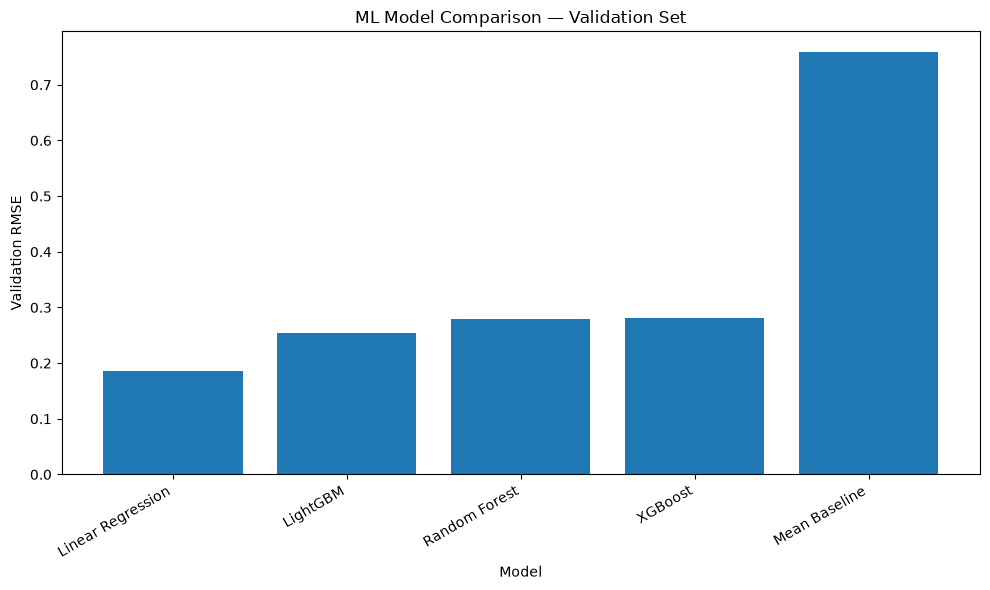

In [27]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.ylabel(
    "Validation RMSE"
)

plt.xlabel(
    "Model"
)

plt.title(
    "ML Model Comparison — Validation Set"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "ml_model_comparison_rmse.png",
    dpi=200
)

plt.show()

In [28]:
results_df.to_csv(
    PROCESSED_DIR /
    "ml_baseline_results.csv",
    index=False
)

print(
    "Saved ML benchmark results."
)

Saved ML benchmark results.


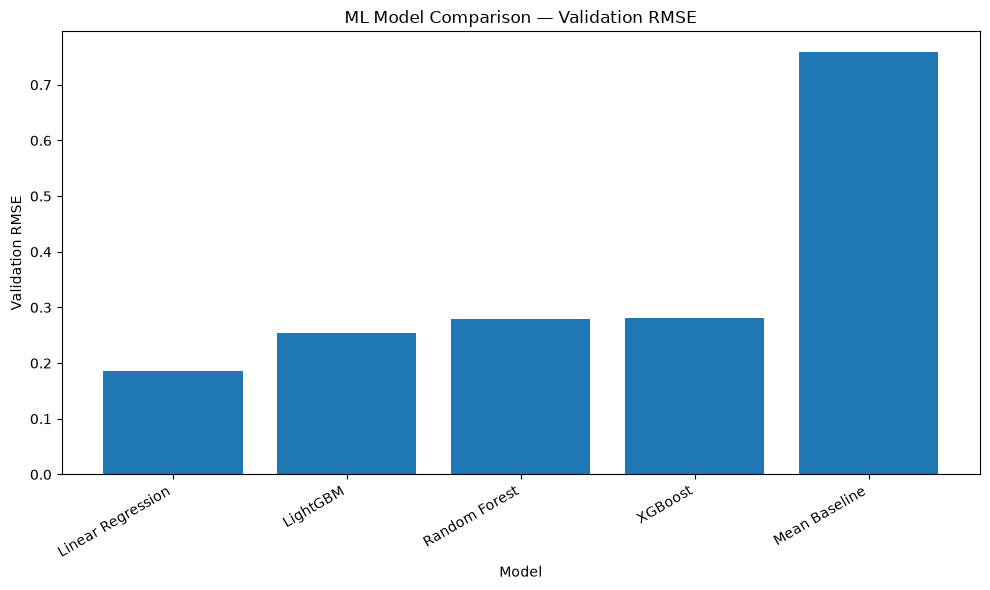

In [29]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.ylabel("Validation RMSE")
plt.xlabel("Model")
plt.title("ML Model Comparison — Validation RMSE")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "ml_model_comparison_rmse.png",
    dpi=200
)

plt.show()

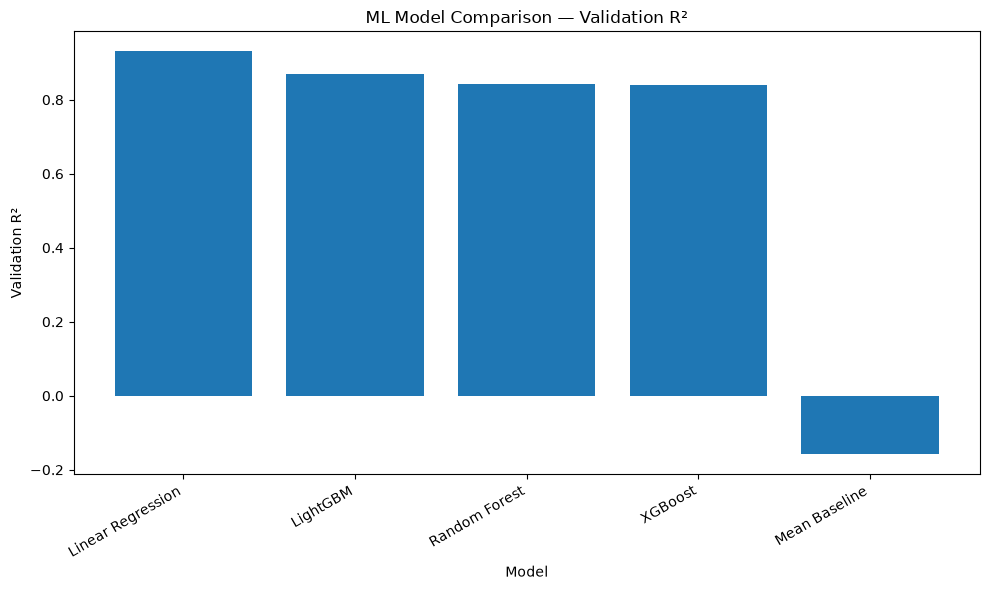

In [30]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["R2"]
)

plt.ylabel("Validation R²")
plt.xlabel("Model")
plt.title("ML Model Comparison — Validation R²")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "ml_model_comparison_r2.png",
    dpi=200
)

plt.show()

In [31]:
results_df.to_csv(
    PROCESSED_DIR /
    "ml_baseline_results.csv",
    index=False
)

print(
    "Saved:",
    PROCESSED_DIR /
    "ml_baseline_results.csv"
)

Saved: C:\Documents\Earthquake_ML_DL\data\processed\ml_baseline_results.csv


In [32]:
model_objects = {
    "Linear Regression": linear_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model
}

best_model_name = (
    results_df[
        results_df["Model"] != "Mean Baseline"
    ]
    .iloc[0]["Model"]
)

best_model = model_objects[
    best_model_name
]

print(
    "Current best validation model:",
    best_model_name
)

Current best validation model: Linear Regression


In [33]:
val_predictions = best_model.predict(
    X_val
)

val_residuals = (
    y_val.to_numpy()
    -
    val_predictions
)

print(
    "Residual mean:",
    val_residuals.mean()
)

print(
    "Residual std:",
    val_residuals.std()
)

Residual mean: -0.026866533584509578
Residual std: 0.1837356445236683


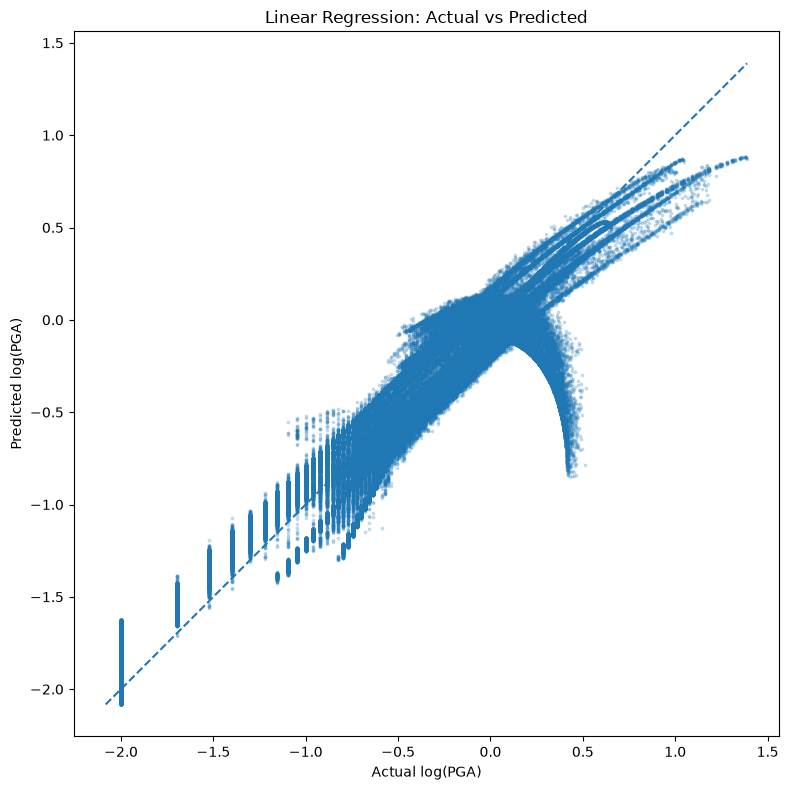

In [34]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_val,
    val_predictions,
    s=3,
    alpha=0.2
)

minimum = min(
    y_val.min(),
    val_predictions.min()
)

maximum = max(
    y_val.max(),
    val_predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual log(PGA)")
plt.ylabel("Predicted log(PGA)")
plt.title(
    f"{best_model_name}: Actual vs Predicted"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "best_model_actual_vs_predicted.png",
    dpi=200
)

plt.show()

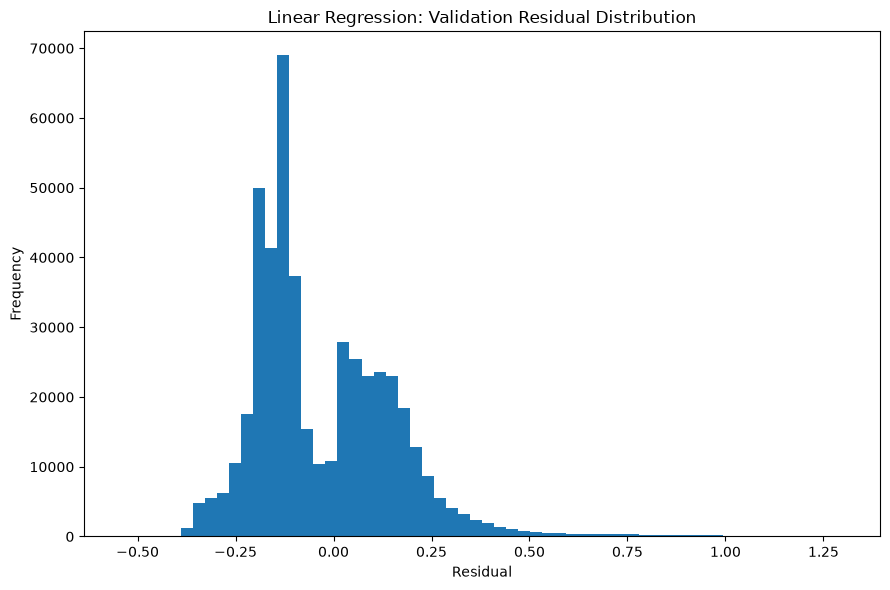

In [35]:
plt.figure(figsize=(9, 6))

plt.hist(
    val_residuals,
    bins=60
)

plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.title(
    f"{best_model_name}: Validation Residual Distribution"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "best_model_residual_distribution.png",
    dpi=200
)

plt.show()

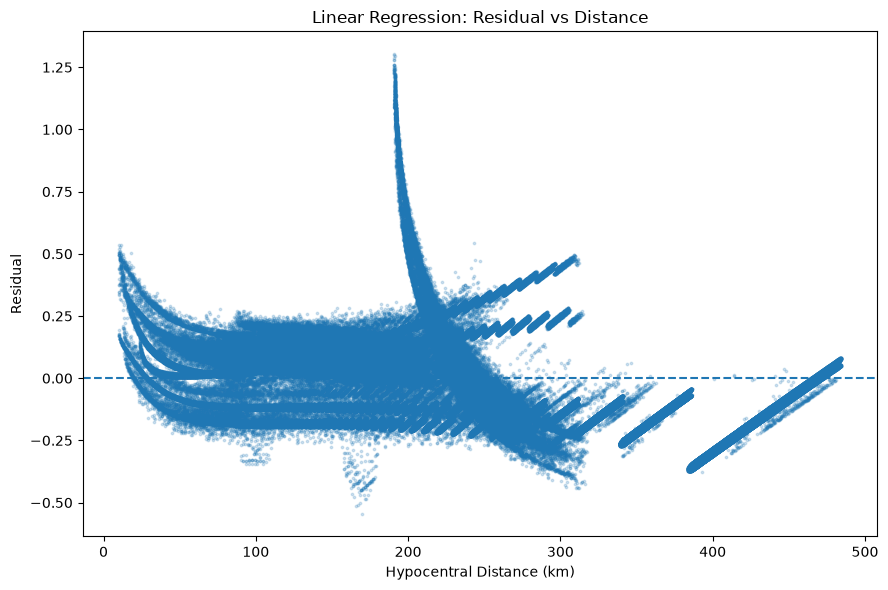

In [36]:
plt.figure(figsize=(9, 6))

plt.scatter(
    val_data["hypocentral_distance_km"],
    val_residuals,
    s=3,
    alpha=0.2
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Hypocentral Distance (km)"
)

plt.ylabel(
    "Residual"
)

plt.title(
    f"{best_model_name}: Residual vs Distance"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "residual_vs_distance.png",
    dpi=200
)

plt.show()

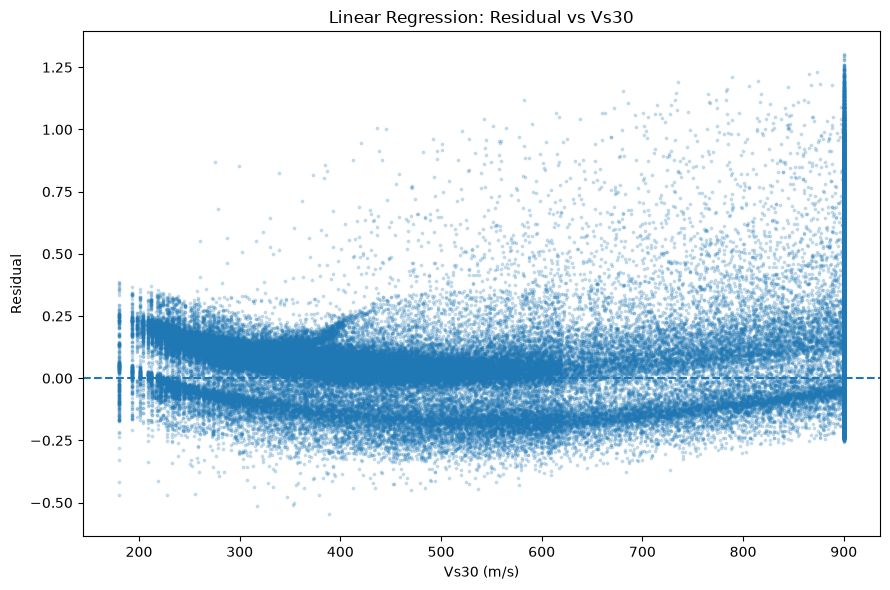

In [37]:
plt.figure(figsize=(9, 6))

plt.scatter(
    val_data["Vs30_clean"],
    val_residuals,
    s=3,
    alpha=0.2
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Vs30 (m/s)"
)

plt.ylabel(
    "Residual"
)

plt.title(
    f"{best_model_name}: Residual vs Vs30"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "residual_vs_vs30.png",
    dpi=200
)

plt.show()

In [38]:
if best_model_name == "Random Forest":
    estimator = best_model.named_steps["model"]

elif best_model_name == "XGBoost":
    estimator = best_model.named_steps["model"]

elif best_model_name == "LightGBM":
    estimator = best_model.named_steps["model"]

else:
    estimator = None

if estimator is not None:

    importance = pd.DataFrame({
        "feature": feature_columns,
        "importance": estimator.feature_importances_
    }).sort_values(
        "importance",
        ascending=False
    )

    display(importance)

In [39]:
if estimator is not None:

    importance_plot = (
        importance
        .sort_values("importance")
    )

    plt.figure(figsize=(9, 7))

    plt.barh(
        importance_plot["feature"],
        importance_plot["importance"]
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.title(
        f"{best_model_name}: Feature Importance"
    )

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR /
        "tree_model_feature_importance.png",
        dpi=200
    )

    plt.show()

In [40]:
display(
    results_df
)

,Model,RMSE,MAE,R2
1,Linear Regression,0.185690,0.152487,0.930524
4,LightGBM,0.253262,0.198768,0.870759
2,Random Forest,0.280147,0.215404,0.841863
3,XGBoost,0.281181,0.213288,0.840693
0,Mean Baseline,0.758142,0.600200,-0.158143


In [41]:
linear_estimator = (
    linear_model
    .named_steps["model"]
)

linear_coefficients = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": linear_estimator.coef_
})

linear_coefficients["abs_coefficient"] = (
    linear_coefficients["coefficient"].abs()
)

linear_coefficients = (
    linear_coefficients
    .sort_values(
        "abs_coefficient",
        ascending=False
    )
)

display(
    linear_coefficients
)

,feature,coefficient,abs_coefficient
3,hypocentral_distance_km,-1.686554,1.686554
1,event_depth,1.604985,1.604985
2,epicentral_distance_km,1.363969,1.363969
7,depth_distance_interaction,-0.999676,0.999676
0,magnitude,0.712938,0.712938
5,magnitude_squared,-0.691032,0.691032
4,log_distance,-0.554217,0.554217
6,magnitude_distance_interaction,0.529469,0.529469
8,Vs30_clean,-0.139554,0.139554
9,log_Vs30,0.100364,0.100364


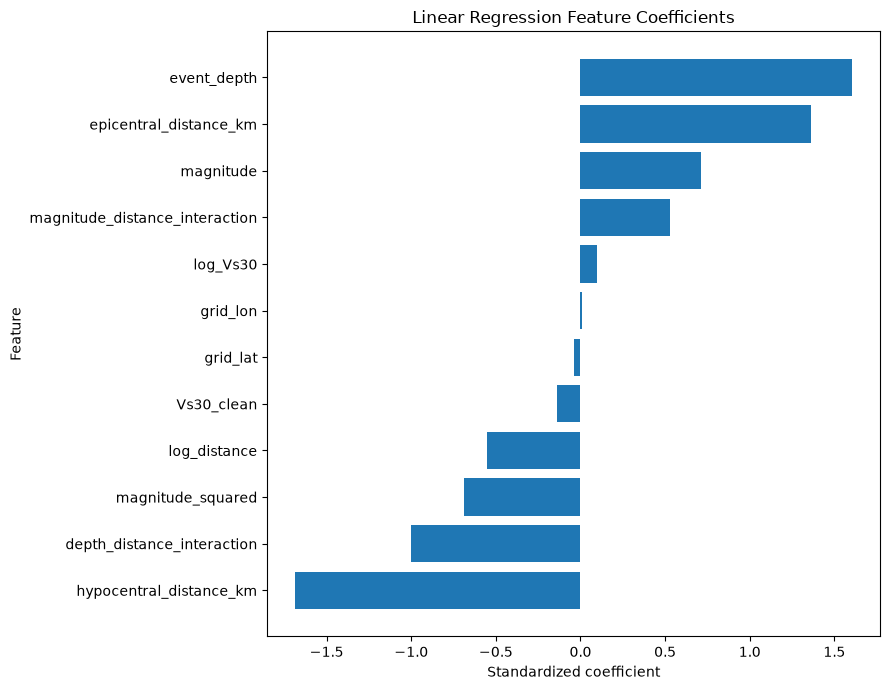

In [42]:
plt.figure(figsize=(9, 7))

coef_plot = (
    linear_coefficients
    .sort_values("coefficient")
)

plt.barh(
    coef_plot["feature"],
    coef_plot["coefficient"]
)

plt.xlabel("Standardized coefficient")
plt.ylabel("Feature")

plt.title(
    "Linear Regression Feature Coefficients"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "linear_regression_coefficients.png",
    dpi=200
)

plt.show()

In [43]:
features_no_location = [
    f
    for f in feature_columns
    if f not in [
        "grid_lat",
        "grid_lon"
    ]
]

print(
    "Original features:",
    len(feature_columns)
)

print(
    "Without coordinates:",
    len(features_no_location)
)

print(features_no_location)

Original features: 12
Without coordinates: 10
['magnitude', 'event_depth', 'epicentral_distance_km', 'hypocentral_distance_km', 'log_distance', 'magnitude_squared', 'magnitude_distance_interaction', 'depth_distance_interaction', 'Vs30_clean', 'log_Vs30']


In [44]:
linear_no_location = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LinearRegression()
    )
])

linear_no_location.fit(
    train_data[features_no_location],
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['magnitude','event_depth','epicentral_distance_km',..., 'depth_distance_interaction','Vs30_clean','log_Vs30']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_v

In [45]:
linear_no_location_result = evaluate_model(
    linear_no_location,
    val_data[features_no_location],
    y_val,
    "Linear Regression — No Coordinates"
)

print(
    linear_no_location_result
)

{'Model': 'Linear Regression — No Coordinates', 'RMSE': np.float64(0.18955640206091096), 'MAE': 0.1560345670900355, 'R2': 0.9276000901764835}


In [46]:
location_comparison = pd.DataFrame([
    linear_result,
    linear_no_location_result
])

display(
    location_comparison
)

,Model,RMSE,MAE,R2
0,Linear Regression,0.185690,0.152487,0.930524
1,Linear Regression — No Coordinates,0.189556,0.156035,0.927600


In [47]:
from sklearn.linear_model import Ridge

In [48]:
ridge_model = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        Ridge(alpha=1.0)
    )
])

ridge_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['magnitude','event_depth','epicentral_distance_km',...,'log_Vs30', 'grid_lat','grid_lon']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings o

In [49]:
ridge_result = evaluate_model(
    ridge_model,
    X_val,
    y_val,
    "Ridge Regression"
)

print(
    ridge_result
)

{'Model': 'Ridge Regression', 'RMSE': np.float64(0.18568221730772866), 'MAE': 0.15248449421277233, 'R2': 0.9305292897930111}


In [50]:
ridge_results = []

alphas = [
    0.001,
    0.01,
    0.1,
    1,
    10,
    100,
    1000
]

for alpha in alphas:

    model = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            Ridge(alpha=alpha)
        )
    ])

    model.fit(
        X_train,
        y_train
    )

    result = evaluate_model(
        model,
        X_val,
        y_val,
        f"Ridge α={alpha}"
    )

    ridge_results.append(result)

ridge_results_df = pd.DataFrame(
    ridge_results
)

display(
    ridge_results_df
)

,Model,RMSE,MAE,R2
0,Ridge α=0.001,0.185690,0.152487,0.930524
1,Ridge α=0.01,0.185689,0.152487,0.930524
2,Ridge α=0.1,0.185689,0.152487,0.930524
3,Ridge α=1,0.185682,0.152484,0.930529
4,Ridge α=10,0.185617,0.152462,0.930578
5,Ridge α=100,0.185013,0.152272,0.931029
6,Ridge α=1000,0.181713,0.152247,0.933468


In [51]:
best_ridge_row = (
    ridge_results_df
    .sort_values("RMSE")
    .iloc[0]
)

print(
    "Best Ridge configuration:"
)

display(
    best_ridge_row
)

Best Ridge configuration:


Model    Ridge α=1000
RMSE         0.181713
MAE          0.152247
R2           0.933468
Name: 6, dtype: object

In [52]:
from sklearn.linear_model import ElasticNet

In [53]:
elastic_model = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        ElasticNet(
            alpha=0.001,
            l1_ratio=0.5,
            max_iter=5000,
            random_state=42
        )
    )
])

elastic_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['magnitude','event_depth','epicentral_distance_km',...,'log_Vs30', 'grid_lat','grid_lon']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings o

In [54]:
elastic_result = evaluate_model(
    elastic_model,
    X_val,
    y_val,
    "Elastic Net"
)

print(
    elastic_result
)

{'Model': 'Elastic Net', 'RMSE': np.float64(0.1792227354455698), 'MAE': 0.1524415847257688, 'R2': 0.9352786876578356}


In [55]:
extended_results = pd.concat([
    results_df,
    pd.DataFrame([
        ridge_result,
        elastic_result,
        linear_no_location_result
    ])
], ignore_index=True)

extended_results = (
    extended_results
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(
    extended_results
)

,Model,RMSE,MAE,R2
0,Elastic Net,0.179223,0.152442,0.935279
1,Ridge Regression,0.185682,0.152484,0.930529
2,Linear Regression,0.185690,0.152487,0.930524
3,Linear Regression — No Coordinates,0.189556,0.156035,0.927600
4,LightGBM,0.253262,0.198768,0.870759
5,Random Forest,0.280147,0.215404,0.841863
6,XGBoost,0.281181,0.213288,0.840693
7,Mean Baseline,0.758142,0.600200,-0.158143


In [56]:
best_rmse = (
    extended_results.iloc[0]["RMSE"]
)

improvement = (
    1 -
    best_rmse / baseline_rmse
) * 100

print(
    "Best model:",
    extended_results.iloc[0]["Model"]
)

print(
    f"RMSE improvement over mean baseline: "
    f"{improvement:.2f}%"
)

Best model: Elastic Net
RMSE improvement over mean baseline: 76.36%


In [57]:
from sklearn.model_selection import GroupKFold
from sklearn.base import clone

In [58]:
X_cv = train_data[feature_columns].copy()
y_cv = train_data[target_column].copy()

groups = train_data["event_id"].copy()

print("Training observations:", len(X_cv))
print("Training earthquakes:", groups.nunique())

Training observations: 2092176
Training earthquakes: 28


In [59]:
group_kfold = GroupKFold(n_splits=5)

cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    group_kfold.split(
        X_cv,
        y_cv,
        groups=groups
    ),
    start=1
):
    
    X_fold_train = X_cv.iloc[train_idx]
    y_fold_train = y_cv.iloc[train_idx]
    
    X_fold_val = X_cv.iloc[val_idx]
    y_fold_val = y_cv.iloc[val_idx]
    
    fold_model = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            ElasticNet(
                alpha=0.001,
                l1_ratio=0.5,
                max_iter=5000,
                random_state=42
            )
        )
    ])
    
    fold_model.fit(
        X_fold_train,
        y_fold_train
    )
    
    predictions = fold_model.predict(
        X_fold_val
    )
    
    rmse = np.sqrt(
        mean_squared_error(
            y_fold_val,
            predictions
        )
    )
    
    mae = mean_absolute_error(
        y_fold_val,
        predictions
    )
    
    r2 = r2_score(
        y_fold_val,
        predictions
    )
    
    validation_events = (
        groups.iloc[val_idx]
        .nunique()
    )
    
    cv_results.append({
        "Fold": fold,
        "Validation Events": validation_events,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })
    
    print(
        f"Fold {fold}: "
        f"RMSE={rmse:.4f}, "
        f"MAE={mae:.4f}, "
        f"R²={r2:.4f}"
    )

Fold 1: RMSE=0.1168, MAE=0.0874, R²=0.9574
Fold 2: RMSE=0.3012, MAE=0.2552, R²=0.8106
Fold 3: RMSE=0.1775, MAE=0.1409, R²=0.8532
Fold 4: RMSE=0.4268, MAE=0.3784, R²=0.0195
Fold 5: RMSE=0.3554, MAE=0.3012, R²=0.0140


In [60]:
cv_results_df = pd.DataFrame(
    cv_results
)

display(cv_results_df)

,Fold,Validation Events,RMSE,MAE,R2
0,1,5,0.116806,0.087402,0.957394
1,2,5,0.301210,0.255175,0.810638
2,3,7,0.177501,0.140913,0.853184
3,4,5,0.426796,0.378398,0.019473
4,5,6,0.355389,0.301160,0.014045


In [61]:
cv_summary = pd.DataFrame({
    "Metric": [
        "RMSE",
        "MAE",
        "R2"
    ],
    "Mean": [
        cv_results_df["RMSE"].mean(),
        cv_results_df["MAE"].mean(),
        cv_results_df["R2"].mean()
    ],
    "Std": [
        cv_results_df["RMSE"].std(),
        cv_results_df["MAE"].std(),
        cv_results_df["R2"].std()
    ]
})

display(
    cv_summary
)

,Metric,Mean,Std
0,RMSE,0.275540,0.127202
1,MAE,0.232610,0.118275
2,R2,0.530947,0.472418


In [62]:
cv_results_df.to_csv(
    PROCESSED_DIR /
    "elastic_net_grouped_cv_results.csv",
    index=False
)

cv_summary.to_csv(
    PROCESSED_DIR /
    "elastic_net_cv_summary.csv",
    index=False
)

print("Grouped CV results saved.")

Grouped CV results saved.


In [63]:
for fold, (_, val_idx) in enumerate(
    group_kfold.split(
        X_cv,
        y_cv,
        groups=groups
    ),
    start=1
):
    
    fold_events = (
        groups.iloc[val_idx]
        .unique()
    )
    
    print(
        f"Fold {fold}:",
        len(fold_events),
        "earthquakes"
    )
    
    print(
        fold_events
    )

Fold 1: 5 earthquakes
<StringArray>
['us10003vpz', 'us2000d1a1', 'b000fzn7', 'b000hdu8', 'usb000syze']
Length: 5, dtype: str
Fold 2: 5 earthquakes
<StringArray>
['us10003vsp', 'us20008hyg', 'us2000cp4g', 'b000g112', 'b000ry7u']
Length: 5, dtype: str
Fold 3: 7 earthquakes
<StringArray>
['us10003vxc', 'us10004rhs', 'us100088sf',   'b000ryuh',   'b000sg5e',
   'c000ff4h', 'usc000syca']
Length: 7, dtype: str
Fold 4: 5 earthquakes
<StringArray>
['us10003vry', 'b000l2rk', 'b000qy82', 'b000sfrw', 'c000rff2']
Length: 5, dtype: str
Fold 5: 6 earthquakes
<StringArray>
['us100042n2', 'us10007tps', 'b000ktbm', 'b000l4ju', 'c000njrq', 'c000njsg']
Length: 6, dtype: str


In [64]:
event_stats = (
    train_data
    .groupby("event_id")
    .agg(
        observations=("log_PGA", "size"),
        magnitude=("magnitude", "first"),
        depth=("event_depth", "first"),
        mean_log_pga=("log_PGA", "mean"),
        std_log_pga=("log_PGA", "std"),
        mean_distance=("hypocentral_distance_km", "mean"),
        mean_vs30=("Vs30_clean", "mean")
    )
    .reset_index()
)

display(
    event_stats.sort_values("magnitude")
)

,event_id,observations,magnitude,depth,mean_log_pga,std_log_pga,mean_distance,mean_vs30
0,b000fzn7,54948,5.1,10.70,-0.856485,0.425912,161.797889,448.027867
2,b000hdu8,46031,5.1,10.00,-0.716017,0.353551,136.079696,443.572963
21,us10007tps,57840,5.1,35.00,-0.431010,0.331383,174.578192,530.253978
23,us20008hyg,49887,5.1,16.05,-0.861380,0.386648,148.152191,671.528080
25,us2000d1a1,226048,5.2,57.51,-1.177896,0.582734,339.320251,292.939056
20,us10004rhs,46754,5.2,174.00,-0.303989,0.155622,225.624003,782.473742
11,c000ff4h,52779,5.2,38.70,-0.762731,0.356073,161.147386,451.842546
7,b000ry7u,56394,5.3,12.00,-0.500957,0.314229,166.134757,296.180144
9,b000sfrw,51574,5.4,52.00,-0.139269,0.283955,162.214338,434.673398
3,b000ktbm,52056,5.4,34.32,-0.637778,0.370612,157.799792,562.086518


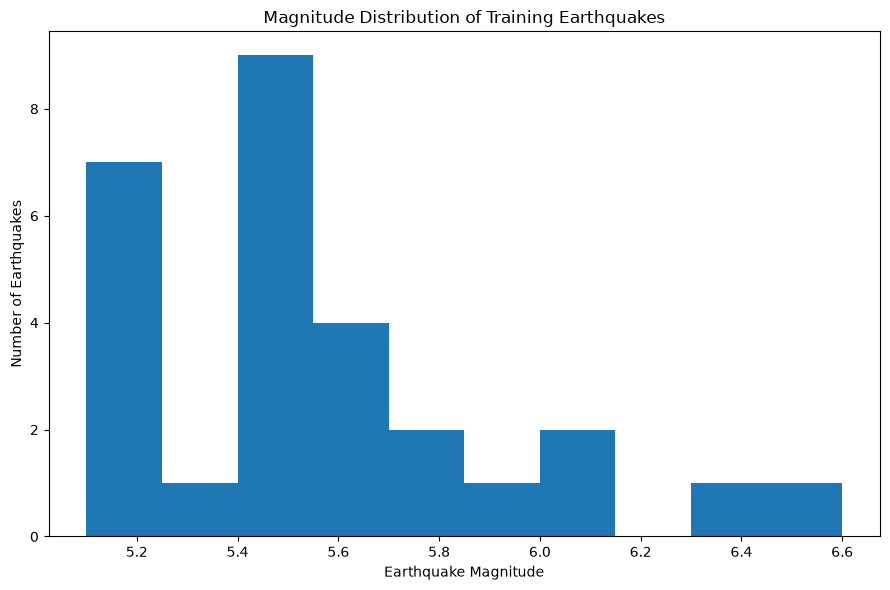

In [65]:
plt.figure(figsize=(9, 6))

plt.hist(
    event_stats["magnitude"],
    bins=10
)

plt.xlabel("Earthquake Magnitude")
plt.ylabel("Number of Earthquakes")

plt.title(
    "Magnitude Distribution of Training Earthquakes"
)

plt.tight_layout()

plt.show()

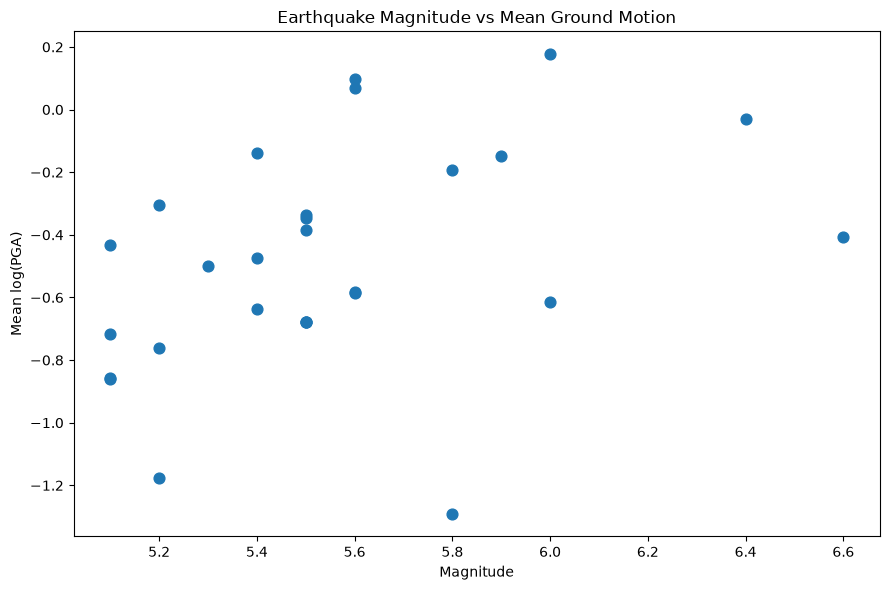

In [66]:
plt.figure(figsize=(9, 6))

plt.scatter(
    event_stats["magnitude"],
    event_stats["mean_log_pga"],
    s=60
)

plt.xlabel("Magnitude")
plt.ylabel("Mean log(PGA)")

plt.title(
    "Earthquake Magnitude vs Mean Ground Motion"
)

plt.tight_layout()

plt.show()

In [67]:
fold_event_details = []

for fold, (_, val_idx) in enumerate(
    group_kfold.split(
        X_cv,
        y_cv,
        groups=groups
    ),
    start=1
):

    fold_events = (
        groups.iloc[val_idx]
        .unique()
    )

    for event in fold_events:

        row = event_stats[
            event_stats["event_id"] == event
        ].iloc[0]

        fold_event_details.append({
            "fold": fold,
            "event_id": event,
            "magnitude": row["magnitude"],
            "depth": row["depth"],
            "observations": row["observations"],
            "mean_log_pga": row["mean_log_pga"],
            "mean_distance": row["mean_distance"],
            "mean_vs30": row["mean_vs30"]
        })

fold_event_details = pd.DataFrame(
    fold_event_details
)

display(
    fold_event_details
    .sort_values(["fold", "magnitude"])
)

,fold,event_id,magnitude,depth,observations,mean_log_pga,mean_distance,mean_vs30
2,1,b000fzn7,5.1,10.70,54948,-0.856485,161.797889,448.027867
3,1,b000hdu8,5.1,10.00,46031,-0.716017,136.079696,443.572963
1,1,us2000d1a1,5.2,57.51,226048,-1.177896,339.320251,292.939056
4,1,usb000syze,5.4,21.63,46754,-0.472656,139.560670,485.458138
0,1,us10003vpz,5.5,8.00,57599,-0.678491,169.914155,570.453516
6,2,us20008hyg,5.1,16.05,49887,-0.861380,148.152191,671.528080
9,2,b000ry7u,5.3,12.00,56394,-0.500957,166.134757,296.180144
5,2,us10003vsp,5.6,10.00,57599,-0.585094,170.034048,542.443603
8,2,b000g112,5.6,102.00,46754,0.098469,174.472709,820.070843
7,2,us2000cp4g,5.8,10.00,214328,-1.290011,323.157397,406.467404


In [68]:
fold_summary = (
    fold_event_details
    .groupby("fold")
    .agg(
        events=("event_id", "count"),
        mean_magnitude=("magnitude", "mean"),
        min_magnitude=("magnitude", "min"),
        max_magnitude=("magnitude", "max"),
        mean_depth=("depth", "mean"),
        mean_log_pga=("mean_log_pga", "mean"),
        mean_vs30=("mean_vs30", "mean")
    )
    .reset_index()
)

display(
    fold_summary
)

,fold,events,mean_magnitude,min_magnitude,max_magnitude,mean_depth,mean_log_pga,mean_vs30
0,1,5,5.260000,5.1,5.5,21.568000,-0.780309,448.090308
1,2,5,5.480000,5.1,5.8,30.010000,-0.627795,547.338015
2,3,7,5.542857,5.2,6.0,38.504286,-0.544369,520.291688
3,4,5,5.820000,5.4,6.6,63.898000,-0.127707,519.253549
4,5,6,5.633333,5.1,6.4,53.901667,-0.329846,544.788157


In [71]:
# Compare the 28 training earthquakes with the 6 final test earthquakes

test_event_stats = (
    test_data
    .groupby("event_id")
    .agg(
        magnitude=("magnitude", "first"),
        depth=("event_depth", "first"),
        observations=("log_PGA", "size"),
        mean_log_pga=("log_PGA", "mean"),
        mean_distance=("hypocentral_distance_km", "mean"),
        mean_vs30=("Vs30_clean", "mean")
    )
    .reset_index()
)

print("TRAIN EVENTS")

display(
    event_stats[
        [
            "event_id",
            "magnitude",
            "depth",
            "mean_log_pga"
        ]
    ]
    .sort_values("magnitude")
)

print("\nTEST EVENTS")

display(
    test_event_stats[
        [
            "event_id",
            "magnitude",
            "depth",
            "mean_log_pga"
        ]
    ]
    .sort_values("magnitude")
)

TRAIN EVENTS


,event_id,magnitude,depth,mean_log_pga
0,b000fzn7,5.1,10.70,-0.856485
2,b000hdu8,5.1,10.00,-0.716017
21,us10007tps,5.1,35.00,-0.431010
23,us20008hyg,5.1,16.05,-0.861380
25,us2000d1a1,5.2,57.51,-1.177896
20,us10004rhs,5.2,174.00,-0.303989
11,c000ff4h,5.2,38.70,-0.762731
7,b000ry7u,5.3,12.00,-0.500957
9,b000sfrw,5.4,52.00,-0.139269
3,b000ktbm,5.4,34.32,-0.637778



TEST EVENTS


,event_id,magnitude,depth,mean_log_pga
4,us2000299v,5.1,13.61,-0.811584
5,usc000sy0y,5.3,66.00,-0.175818
0,c000kmdj,5.4,23.00,-0.857649
1,us10002n5q,5.5,8.71,-0.778865
3,us10004dtm,5.7,239.00,-0.381532
2,us100030qs,5.9,224.00,0.193205


In [72]:
print(
    "Training magnitude range:",
    train_data["magnitude"].min(),
    "→",
    train_data["magnitude"].max()
)

print(
    "Validation magnitude range:",
    val_data["magnitude"].min(),
    "→",
    val_data["magnitude"].max()
)

print(
    "Final test magnitude range:",
    test_data["magnitude"].min(),
    "→",
    test_data["magnitude"].max()
)

Training magnitude range: 5.1 → 6.6
Validation magnitude range: 5.2 → 5.6
Final test magnitude range: 5.1 → 5.9


In [73]:
# Fold-level earthquake characteristics

display(
    fold_summary.sort_values("fold")
)

,fold,events,mean_magnitude,min_magnitude,max_magnitude,mean_depth,mean_log_pga,mean_vs30
0,1,5,5.260000,5.1,5.5,21.568000,-0.780309,448.090308
1,2,5,5.480000,5.1,5.8,30.010000,-0.627795,547.338015
2,3,7,5.542857,5.2,6.0,38.504286,-0.544369,520.291688
3,4,5,5.820000,5.4,6.6,63.898000,-0.127707,519.253549
4,5,6,5.633333,5.1,6.4,53.901667,-0.329846,544.788157


In [74]:
# Show the individual earthquakes in the difficult folds

difficult_folds = [4, 5]

display(
    fold_event_details[
        fold_event_details["fold"].isin(difficult_folds)
    ]
    .sort_values(["fold", "magnitude"])
)

,fold,event_id,magnitude,depth,observations,mean_log_pga,mean_distance,mean_vs30
20,4,b000sfrw,5.4,52.00,51574,-0.139269,162.214338,434.673398
18,4,b000l2rk,5.5,10.26,56635,-0.335109,167.339979,450.392904
21,4,c000rff2,5.6,200.00,46754,0.067814,246.539934,770.366737
19,4,b000qy82,6.0,47.23,123823,0.176492,248.833929,368.086032
17,4,us10003vry,6.6,10.00,129238,-0.408463,254.406444,572.748672
23,5,us10007tps,5.1,35.00,57840,-0.431010,174.578192,530.253978
24,5,b000ktbm,5.4,34.32,52056,-0.637778,157.799792,562.086518
25,5,b000l4ju,5.5,15.61,57840,-0.346294,171.079033,439.939799
27,5,c000njsg,5.5,10.00,57599,-0.384974,169.757643,427.179002
22,5,us100042n2,5.9,206.94,46754,-0.149581,252.263316,767.597628


In [75]:
# Compare the magnitude distribution across folds

for fold in sorted(fold_event_details["fold"].unique()):
    
    fold_data = fold_event_details[
        fold_event_details["fold"] == fold
    ]
    
    print(
        f"Fold {fold}: "
        f"{fold_data['magnitude'].min():.2f} "
        f"to "
        f"{fold_data['magnitude'].max():.2f}"
    )

Fold 1: 5.10 to 5.50
Fold 2: 5.10 to 5.80
Fold 3: 5.20 to 6.00
Fold 4: 5.40 to 6.60
Fold 5: 5.10 to 6.40


In [76]:
# Create additional physically motivated nonlinear features

def add_physical_features(df):
    
    df = df.copy()
    
    # Protect against log(0)
    distance = np.maximum(
        df["hypocentral_distance_km"],
        1.0
    )
    
    log_distance = np.log10(distance)
    
    df["log_distance"] = log_distance
    
    # Nonlinear distance term
    df["log_distance_squared"] = (
        log_distance ** 2
    )
    
    # Magnitude nonlinear term
    df["magnitude_squared"] = (
        df["magnitude"] ** 2
    )
    
    # Magnitude-distance interaction
    df["magnitude_log_distance"] = (
        df["magnitude"] * log_distance
    )
    
    # Depth nonlinear term
    df["depth_squared"] = (
        df["event_depth"] ** 2
    )
    
    # Magnitude-depth interaction
    df["magnitude_depth"] = (
        df["magnitude"] *
        df["event_depth"]
    )
    
    # Depth-distance interaction
    df["depth_log_distance"] = (
        df["event_depth"] *
        log_distance
    )
    
    # Magnitude-distance-depth interaction
    df["magnitude_depth_log_distance"] = (
        df["magnitude"] *
        df["event_depth"] *
        log_distance
    )
    
    return df

In [77]:
train_physical = add_physical_features(
    train_data
)

val_physical = add_physical_features(
    val_data
)

test_physical = add_physical_features(
    test_data
)

print(
    "Train:",
    train_physical.shape
)

print(
    "Validation:",
    val_physical.shape
)

print(
    "Test:",
    test_physical.shape
)

Train: (2092176, 32)
Validation: (468857, 32)
Test: (312336, 32)


In [78]:
physical_features = [
    "magnitude",
    "magnitude_squared",
    
    "event_depth",
    "depth_squared",
    
    "epicentral_distance_km",
    "hypocentral_distance_km",
    
    "log_distance",
    "log_distance_squared",
    
    "magnitude_log_distance",
    "magnitude_depth",
    "depth_log_distance",
    "magnitude_depth_log_distance",
    
    "Vs30_clean",
    "log_Vs30",
    
    "grid_lat",
    "grid_lon"
]

target_column = "log_PGA"

print(
    "Number of physical features:",
    len(physical_features)
)

Number of physical features: 16


In [79]:
X_train_physical = train_physical[
    physical_features
]

X_val_physical = val_physical[
    physical_features
]

y_train_physical = train_physical[
    target_column
]

y_val_physical = val_physical[
    target_column
]

print(
    X_train_physical.shape,
    X_val_physical.shape
)

(2092176, 16) (468857, 16)


In [80]:
physical_elastic_model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        ElasticNet(
            alpha=0.001,
            l1_ratio=0.5,
            max_iter=5000,
            random_state=42
        )
    )
])

physical_elastic_model.fit(
    X_train_physical,
    y_train_physical
)

print("Improved Elastic Net trained.")

Improved Elastic Net trained.


In [81]:
physical_elastic_result = evaluate_model(
    physical_elastic_model,
    X_val_physical,
    y_val_physical,
    "Elastic Net — Physical Features"
)

print(
    physical_elastic_result
)

{'Model': 'Elastic Net — Physical Features', 'RMSE': np.float64(0.15709471236973802), 'MAE': 0.13284280584314848, 'R2': 0.9502739174673827}


In [82]:
physical_comparison = pd.DataFrame([
    {
        "Model": "Original Elastic Net",
        "RMSE": elastic_result["RMSE"],
        "MAE": elastic_result["MAE"],
        "R2": elastic_result["R2"]
    },
    physical_elastic_result
])

display(
    physical_comparison
)

,Model,RMSE,MAE,R2
0,Original Elastic Net,0.179223,0.152442,0.935279
1,Elastic Net — Physical Features,0.157095,0.132843,0.950274


In [83]:
X_physical_cv = train_physical[
    physical_features
].copy()

y_physical_cv = train_physical[
    target_column
].copy()

groups_physical = train_physical[
    "event_id"
].copy()

print(
    "Observations:",
    len(X_physical_cv)
)

print(
    "Earthquakes:",
    groups_physical.nunique()
)

Observations: 2092176
Earthquakes: 28


In [5]:
def add_physical_features(df):
    
    df = df.copy()
    
    distance = np.maximum(
        df["hypocentral_distance_km"],
        1.0
    )
    
    log_distance = np.log10(distance)
    
    df["log_distance"] = log_distance
    
    df["log_distance_squared"] = (
        log_distance ** 2
    )
    
    df["magnitude_squared"] = (
        df["magnitude"] ** 2
    )
    
    df["magnitude_log_distance"] = (
        df["magnitude"] * log_distance
    )
    
    df["depth_squared"] = (
        df["event_depth"] ** 2
    )
    
    df["magnitude_depth"] = (
        df["magnitude"] *
        df["event_depth"]
    )
    
    df["depth_log_distance"] = (
        df["event_depth"] *
        log_distance
    )
    
    df["magnitude_depth_log_distance"] = (
        df["magnitude"] *
        df["event_depth"] *
        log_distance
    )
    
    return df

In [7]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print("Processed directory:")
print(PROCESSED_DIR)

print("\nFiles available:")
for f in PROCESSED_DIR.iterdir():
    print(f.name)

Processed directory:
C:\Documents\Earthquake_ML_DL\data\processed

Files available:
balanced_eda_sample.csv
distance_attenuation_summary.csv
elastic_net_cv_summary.csv
elastic_net_grouped_cv_results.csv
event_level_summary.csv
event_split.csv
feature_config.csv
ml_baseline_results.csv
test_data.csv
train_data.csv
validation_data.csv


In [9]:
import pandas as pd

train_data = pd.read_csv(
    PROCESSED_DIR / "train_data.csv"
)

val_data = pd.read_csv(
    PROCESSED_DIR / "validation_data.csv"
)

test_data = pd.read_csv(
    PROCESSED_DIR / "test_data.csv"
)

print("Train:", train_data.shape)
print("Validation:", val_data.shape)
print("Test:", test_data.shape)

print("\nTrain events:", train_data["event_id"].nunique())
print("Validation events:", val_data["event_id"].nunique())
print("Test events:", test_data["event_id"].nunique())

Train: (2092176, 26)
Validation: (468857, 26)
Test: (312336, 26)

Train events: 28
Validation events: 6
Test events: 6


In [10]:
def add_physical_features(df):
    df = df.copy()

    distance = np.maximum(
        df["hypocentral_distance_km"],
        1.0
    )

    log_distance = np.log10(distance)

    df["log_distance"] = log_distance
    df["log_distance_squared"] = log_distance ** 2
    df["magnitude_squared"] = df["magnitude"] ** 2
    df["magnitude_log_distance"] = (
        df["magnitude"] * log_distance
    )

    df["depth_squared"] = (
        df["event_depth"] ** 2
    )

    df["magnitude_depth"] = (
        df["magnitude"] *
        df["event_depth"]
    )

    df["depth_log_distance"] = (
        df["event_depth"] *
        log_distance
    )

    df["magnitude_depth_log_distance"] = (
        df["magnitude"] *
        df["event_depth"] *
        log_distance
    )

    return df

In [11]:
physical_features = [
    "magnitude",
    "magnitude_squared",
    "event_depth",
    "depth_squared",
    "epicentral_distance_km",
    "hypocentral_distance_km",
    "log_distance",
    "log_distance_squared",
    "magnitude_log_distance",
    "magnitude_depth",
    "depth_log_distance",
    "magnitude_depth_log_distance",
    "Vs30_clean",
    "log_Vs30",
    "grid_lat",
    "grid_lon"
]

target_column = "log_PGA"

print(
    "Number of physical features:",
    len(physical_features)
)

Number of physical features: 16


In [14]:
print("train_data columns:")
print(train_data.columns.tolist())

print("\ntrain_physical columns:")
print(train_physical.columns.tolist())

print("\nevent_split columns:")
event_split = pd.read_csv(
    PROCESSED_DIR / "event_split.csv"
)
print(event_split.columns.tolist())

print("\nevent_level_summary columns:")
event_summary = pd.read_csv(
    PROCESSED_DIR / "event_level_summary.csv"
)
print(event_summary.columns.tolist())

train_data columns:
['grid_lon', 'grid_lat', 'PGA', 'PGV', 'MMI', 'PSA03', 'PSA10', 'PSA30', 'event_id', 'magnitude', 'event_lat', 'event_lon', 'epicentral_distance_km', 'hypocentral_distance_km', 'event_depth', 'Vs30', 'Vs30_clean', 'site_class', 'log_PGA', 'log_distance', 'log_epicentral_distance', 'magnitude_distance_interaction', 'magnitude_squared', 'depth_distance_interaction', 'log_Vs30', 'Vs30_available']

train_physical columns:
['grid_lon', 'grid_lat', 'PGA', 'PGV', 'MMI', 'PSA03', 'PSA10', 'PSA30', 'event_id', 'magnitude', 'event_lat', 'event_lon', 'epicentral_distance_km', 'hypocentral_distance_km', 'event_depth', 'Vs30', 'Vs30_clean', 'site_class', 'log_PGA', 'log_distance', 'log_epicentral_distance', 'magnitude_distance_interaction', 'magnitude_squared', 'depth_distance_interaction', 'log_Vs30', 'Vs30_available', 'log_distance_squared', 'magnitude_log_distance', 'depth_squared', 'magnitude_depth', 'depth_log_distance', 'magnitude_depth_log_distance']

event_split columns:

In [16]:
# Create event-balanced development sample
# This preserves event_id explicitly.

cv_sample = (
    train_physical
    .groupby("event_id", group_keys=False)
    .sample(
        n=10000,
        random_state=42
    )
    .reset_index(drop=True)
)

print("CV sample:", cv_sample.shape)
print(
    "CV earthquakes:",
    cv_sample["event_id"].nunique()
)

print(
    "\nObservations per earthquake:"
)

display(
    cv_sample["event_id"]
    .value_counts()
    .sort_index()
)

CV sample: (280000, 32)
CV earthquakes: 28

Observations per earthquake:


event_id
b000fzn7      10000
b000g112      10000
b000hdu8      10000
b000ktbm      10000
b000l2rk      10000
b000l4ju      10000
b000qy82      10000
b000ry7u      10000
b000ryuh      10000
b000sfrw      10000
b000sg5e      10000
c000ff4h      10000
c000njrq      10000
c000njsg      10000
c000rff2      10000
us10003vpz    10000
us10003vry    10000
us10003vsp    10000
us10003vxc    10000
us100042n2    10000
us10004rhs    10000
us10007tps    10000
us100088sf    10000
us20008hyg    10000
us2000cp4g    10000
us2000d1a1    10000
usb000syze    10000
usc000syca    10000
Name: count, dtype: int64

In [17]:
X_physical_cv = cv_sample[
    physical_features
].copy()

y_physical_cv = cv_sample[
    target_column
].copy()

groups_physical = cv_sample[
    "event_id"
].copy()

print("X:", X_physical_cv.shape)
print("y:", y_physical_cv.shape)
print(
    "Unique earthquakes:",
    groups_physical.nunique()
)

X: (280000, 16)
y: (280000,)
Unique earthquakes: 28


In [21]:
physical_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    group_kfold.split(
        X_physical_cv,
        y_physical_cv,
        groups=groups_physical
    ),
    start=1
):

    print(f"\nStarting Fold {fold}...")

    X_fold_train = X_physical_cv.iloc[train_idx]
    y_fold_train = y_physical_cv.iloc[train_idx]

    X_fold_val = X_physical_cv.iloc[val_idx]
    y_fold_val = y_physical_cv.iloc[val_idx]

    fold_model = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            ElasticNet(
                alpha=0.001,
                l1_ratio=0.5,
                max_iter=3000,
                random_state=42
            )
        )
    ])

    fold_model.fit(
        X_fold_train,
        y_fold_train
    )

    predictions = fold_model.predict(
        X_fold_val
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_fold_val,
            predictions
        )
    )

    mae = mean_absolute_error(
        y_fold_val,
        predictions
    )

    r2 = r2_score(
        y_fold_val,
        predictions
    )

    physical_cv_results.append({
        "Fold": fold,
        "Validation Events": len(
            groups_physical.iloc[val_idx].unique()
        ),
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

    print(
        f"Fold {fold}: "
        f"RMSE={rmse:.4f}, "
        f"MAE={mae:.4f}, "
        f"R²={r2:.4f}"
    )


Starting Fold 1...


C:\Users\utkar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.536709e+01, tolerance: 6.051e+00
  model = cd_fast.enet_coordinate_descent(


Fold 1: RMSE=0.2286, MAE=0.1803, R²=0.7541

Starting Fold 2...


C:\Users\utkar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.198902e+01, tolerance: 5.695e+00
  model = cd_fast.enet_coordinate_descent(


Fold 2: RMSE=0.2899, MAE=0.2477, R²=0.6350

Starting Fold 3...
Fold 3: RMSE=0.1827, MAE=0.1455, R²=0.8657

Starting Fold 4...


C:\Users\utkar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.636494e+01, tolerance: 5.490e+00
  model = cd_fast.enet_coordinate_descent(


Fold 4: RMSE=0.6051, MAE=0.4354, R²=-0.0382

Starting Fold 5...
Fold 5: RMSE=0.1931, MAE=0.1676, R²=0.7940


C:\Users\utkar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.028794e+01, tolerance: 6.394e+00
  model = cd_fast.enet_coordinate_descent(


In [19]:
from sklearn.model_selection import GroupKFold

group_kfold = GroupKFold(n_splits=5)

print("GroupKFold ready.")

GroupKFold ready.


In [20]:
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [22]:
physical_cv_results_df = pd.DataFrame(
    physical_cv_results
)

display(physical_cv_results_df)

,Fold,Validation Events,RMSE,MAE,R2
0,1,6,0.228594,0.180327,0.754129
1,2,6,0.289916,0.247737,0.634952
2,3,6,0.182662,0.145526,0.865731
3,4,5,0.605084,0.435371,-0.038184
4,5,5,0.193136,0.167588,0.794036


In [25]:
physical_cv_summary = pd.DataFrame({
    "Metric": [
        "RMSE",
        "MAE",
        "R2"
    ],
    "Mean": [
        physical_cv_results_df["RMSE"].mean(),
        physical_cv_results_df["MAE"].mean(),
        physical_cv_results_df["R2"].mean()
    ],
    "Std": [
        physical_cv_results_df["RMSE"].std(),
        physical_cv_results_df["MAE"].std(),
        physical_cv_results_df["R2"].std()
    ]
})

display(physical_cv_summary)

,Metric,Mean,Std
0,RMSE,0.299878,0.175688
1,MAE,0.235310,0.118162
2,R2,0.602133,0.367592


In [26]:
# Reload original grouped-CV results from disk

cv_results_df = pd.read_csv(
    PROCESSED_DIR /
    "elastic_net_grouped_cv_results.csv"
)

print("Original grouped CV results:")
display(cv_results_df)

Original grouped CV results:


,Fold,Validation Events,RMSE,MAE,R2
0,1,5,0.116806,0.087402,0.957394
1,2,5,0.301210,0.255175,0.810638
2,3,7,0.177501,0.140913,0.853184
3,4,5,0.426796,0.378398,0.019473
4,5,6,0.355389,0.301160,0.014045


In [27]:
cv_comparison = pd.DataFrame({
    "Model": [
        "Original Elastic Net",
        "Physical Feature Elastic Net"
    ],
    "Mean RMSE": [
        cv_results_df["RMSE"].mean(),
        physical_cv_results_df["RMSE"].mean()
    ],
    "RMSE Std": [
        cv_results_df["RMSE"].std(),
        physical_cv_results_df["RMSE"].std()
    ],
    "Mean MAE": [
        cv_results_df["MAE"].mean(),
        physical_cv_results_df["MAE"].mean()
    ],
    "Mean R2": [
        cv_results_df["R2"].mean(),
        physical_cv_results_df["R2"].mean()
    ],
    "R2 Std": [
        cv_results_df["R2"].std(),
        physical_cv_results_df["R2"].std()
    ]
})

display(cv_comparison)

,Model,Mean RMSE,RMSE Std,Mean MAE,Mean R2,R2 Std
0,Original Elastic Net,0.275540,0.127202,0.23261,0.530947,0.472418
1,Physical Feature Elastic Net,0.299878,0.175688,0.23531,0.602133,0.367592


In [28]:
physical_cv_results_df.to_csv(
    PROCESSED_DIR /
    "physical_feature_grouped_cv_results.csv",
    index=False
)

physical_cv_summary.to_csv(
    PROCESSED_DIR /
    "physical_feature_cv_summary.csv",
    index=False
)

cv_comparison.to_csv(
    PROCESSED_DIR /
    "grouped_cv_model_comparison.csv",
    index=False
)

print("Grouped CV experiment saved.")

Grouped CV experiment saved.


In [29]:
original_features = [
    "magnitude",
    "event_depth",
    "epicentral_distance_km",
    "hypocentral_distance_km",
    "log_distance",
    "magnitude_squared",
    "magnitude_distance_interaction",
    "depth_distance_interaction",
    "Vs30_clean",
    "log_Vs30",
    "grid_lat",
    "grid_lon"
]

X_lgb_cv = cv_sample[original_features].copy()
y_lgb_cv = cv_sample["log_PGA"].copy()
groups_lgb_cv = cv_sample["event_id"].copy()

print("X:", X_lgb_cv.shape)
print("y:", y_lgb_cv.shape)
print("Events:", groups_lgb_cv.nunique())

X: (280000, 12)
y: (280000,)
Events: 28


In [30]:
try:
    from lightgbm import LGBMRegressor
    print("LightGBM available.")
except ImportError:
    print("LightGBM is not installed.")

LightGBM available.


In [31]:
lgb_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    group_kfold.split(
        X_lgb_cv,
        y_lgb_cv,
        groups=groups_lgb_cv
    ),
    start=1
):

    print(f"\nStarting Fold {fold}...")

    X_fold_train = X_lgb_cv.iloc[train_idx]
    y_fold_train = y_lgb_cv.iloc[train_idx]

    X_fold_val = X_lgb_cv.iloc[val_idx]
    y_fold_val = y_lgb_cv.iloc[val_idx]

    lgb_model = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    lgb_model.fit(
        X_fold_train,
        y_fold_train
    )

    predictions = lgb_model.predict(
        X_fold_val
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_fold_val,
            predictions
        )
    )

    mae = mean_absolute_error(
        y_fold_val,
        predictions
    )

    r2 = r2_score(
        y_fold_val,
        predictions
    )

    lgb_cv_results.append({
        "Fold": fold,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

    print(
        f"Fold {fold}: "
        f"RMSE={rmse:.4f}, "
        f"MAE={mae:.4f}, "
        f"R²={r2:.4f}"
    )


Starting Fold 1...
Fold 1: RMSE=0.2977, MAE=0.1978, R²=0.5831

Starting Fold 2...
Fold 2: RMSE=0.3787, MAE=0.2997, R²=0.3772

Starting Fold 3...
Fold 3: RMSE=0.4230, MAE=0.2926, R²=0.2799

Starting Fold 4...
Fold 4: RMSE=0.2869, MAE=0.2447, R²=0.7665

Starting Fold 5...
Fold 5: RMSE=0.1984, MAE=0.1578, R²=0.7826


In [32]:
lgb_cv_results_df = pd.DataFrame(
    lgb_cv_results
)

display(lgb_cv_results_df)

,Fold,RMSE,MAE,R2
0,1,0.297664,0.197772,0.583102
1,2,0.378694,0.299673,0.377151
2,3,0.423018,0.292633,0.279894
3,4,0.286935,0.244663,0.766541
4,5,0.198407,0.157763,0.782640


In [33]:
lgb_cv_summary = pd.DataFrame({
    "Metric": [
        "RMSE",
        "MAE",
        "R2"
    ],
    "Mean": [
        lgb_cv_results_df["RMSE"].mean(),
        lgb_cv_results_df["MAE"].mean(),
        lgb_cv_results_df["R2"].mean()
    ],
    "Std": [
        lgb_cv_results_df["RMSE"].std(),
        lgb_cv_results_df["MAE"].std(),
        lgb_cv_results_df["R2"].std()
    ]
})

display(lgb_cv_summary)

,Metric,Mean,Std
0,RMSE,0.316944,0.087161
1,MAE,0.238501,0.061008
2,R2,0.557865,0.226181


In [34]:
# Original-feature Elastic Net on the SAME CV sample as LightGBM

X_elastic_cv = cv_sample[original_features].copy()
y_elastic_cv = cv_sample["log_PGA"].copy()
groups_elastic_cv = cv_sample["event_id"].copy()

elastic_sample_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    group_kfold.split(
        X_elastic_cv,
        y_elastic_cv,
        groups=groups_elastic_cv
    ),
    start=1
):

    print(f"\nStarting Fold {fold}...")

    X_fold_train = X_elastic_cv.iloc[train_idx]
    y_fold_train = y_elastic_cv.iloc[train_idx]

    X_fold_val = X_elastic_cv.iloc[val_idx]
    y_fold_val = y_elastic_cv.iloc[val_idx]

    model = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            ElasticNet(
                alpha=0.001,
                l1_ratio=0.5,
                max_iter=3000,
                random_state=42
            )
        )
    ])

    model.fit(
        X_fold_train,
        y_fold_train
    )

    predictions = model.predict(
        X_fold_val
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_fold_val,
            predictions
        )
    )

    mae = mean_absolute_error(
        y_fold_val,
        predictions
    )

    r2 = r2_score(
        y_fold_val,
        predictions
    )

    elastic_sample_cv_results.append({
        "Fold": fold,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

    print(
        f"Fold {fold}: "
        f"RMSE={rmse:.4f}, "
        f"MAE={mae:.4f}, "
        f"R²={r2:.4f}"
    )


Starting Fold 1...
Fold 1: RMSE=0.2149, MAE=0.1761, R²=0.7828

Starting Fold 2...
Fold 2: RMSE=0.3387, MAE=0.2880, R²=0.5018

Starting Fold 3...
Fold 3: RMSE=0.1463, MAE=0.1191, R²=0.9139

Starting Fold 4...
Fold 4: RMSE=0.3564, MAE=0.2943, R²=0.6398

Starting Fold 5...
Fold 5: RMSE=0.1805, MAE=0.1623, R²=0.8201


In [35]:
elastic_sample_cv_df = pd.DataFrame(
    elastic_sample_cv_results
)

model_cv_comparison = pd.DataFrame({
    "Model": [
        "Elastic Net",
        "LightGBM",
        "Physical Elastic Net"
    ],
    "Mean RMSE": [
        elastic_sample_cv_df["RMSE"].mean(),
        lgb_cv_results_df["RMSE"].mean(),
        physical_cv_results_df["RMSE"].mean()
    ],
    "RMSE Std": [
        elastic_sample_cv_df["RMSE"].std(),
        lgb_cv_results_df["RMSE"].std(),
        physical_cv_results_df["RMSE"].std()
    ],
    "Mean MAE": [
        elastic_sample_cv_df["MAE"].mean(),
        lgb_cv_results_df["MAE"].mean(),
        physical_cv_results_df["MAE"].mean()
    ],
    "Mean R2": [
        elastic_sample_cv_df["R2"].mean(),
        lgb_cv_results_df["R2"].mean(),
        physical_cv_results_df["R2"].mean()
    ],
    "R2 Std": [
        elastic_sample_cv_df["R2"].std(),
        lgb_cv_results_df["R2"].std(),
        physical_cv_results_df["R2"].std()
    ]
})

display(model_cv_comparison)

,Model,Mean RMSE,RMSE Std,Mean MAE,Mean R2,R2 Std
0,Elastic Net,0.247352,0.094838,0.207955,0.731666,0.161969
1,LightGBM,0.316944,0.087161,0.238501,0.557865,0.226181
2,Physical Elastic Net,0.299878,0.175688,0.235310,0.602133,0.367592


In [36]:
model_cv_comparison.to_csv(
    PROCESSED_DIR /
    "same_sample_grouped_cv_comparison.csv",
    index=False
)

elastic_sample_cv_df.to_csv(
    PROCESSED_DIR /
    "elastic_net_same_sample_cv.csv",
    index=False
)

lgb_cv_results_df.to_csv(
    PROCESSED_DIR /
    "lightgbm_grouped_cv_results.csv",
    index=False
)

print("Model comparison saved.")

Model comparison saved.


In [39]:
try:
    import torch

    print("PyTorch version:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())

    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))

except ImportError:
    print("PyTorch is not installed.")

PyTorch version: 2.13.0+cpu
CUDA available: False


In [41]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.13.0+cpu
CUDA available: False


In [42]:
dl_features = original_features

X_dl = cv_sample[dl_features].copy()
y_dl = cv_sample["log_PGA"].copy()
groups_dl = cv_sample["event_id"].copy()

print("X:", X_dl.shape)
print("y:", y_dl.shape)
print("Earthquakes:", groups_dl.nunique())

X: (280000, 12)
y: (280000,)
Earthquakes: 28


In [43]:
X_dl = X_dl.astype(np.float32)
y_dl = y_dl.astype(np.float32)

print("X dtype:", X_dl.dtypes.unique())
print("y dtype:", y_dl.dtype)

X dtype: [dtype('float32')]
y dtype: float32


In [44]:
print("Missing values in features:")
display(
    X_dl.isna().sum()
)

print(
    "\nMissing target:",
    y_dl.isna().sum()
)

Missing values in features:


magnitude                              0
event_depth                            0
epicentral_distance_km                 0
hypocentral_distance_km                0
log_distance                           0
magnitude_squared                      0
magnitude_distance_interaction         0
depth_distance_interaction             0
Vs30_clean                        168362
log_Vs30                          168362
grid_lat                               0
grid_lon                               0
dtype: int64


Missing target: 0


In [45]:
dl_features = [
    "magnitude",
    "event_depth",
    "epicentral_distance_km",
    "hypocentral_distance_km",
    "log_distance",
    "magnitude_squared",
    "magnitude_distance_interaction",
    "depth_distance_interaction",
    "Vs30_clean",
    "log_Vs30",
    "Vs30_available",
    "grid_lat",
    "grid_lon"
]

X_dl = cv_sample[dl_features].copy()
y_dl = cv_sample["log_PGA"].copy()

X_dl = X_dl.astype(np.float32)
y_dl = y_dl.astype(np.float32)

print("Features:", X_dl.shape[1])
print("Observations:", X_dl.shape[0])

Features: 13
Observations: 280000


In [46]:
print("Missing values:")

display(
    X_dl.isna().sum()
)

Missing values:


magnitude                              0
event_depth                            0
epicentral_distance_km                 0
hypocentral_distance_km                0
log_distance                           0
magnitude_squared                      0
magnitude_distance_interaction         0
depth_distance_interaction             0
Vs30_clean                        168362
log_Vs30                          168362
Vs30_available                         0
grid_lat                               0
grid_lon                               0
dtype: int64

In [47]:
print("Missing values:")

display(
    X_dl.isna().sum()
)

Missing values:


magnitude                              0
event_depth                            0
epicentral_distance_km                 0
hypocentral_distance_km                0
log_distance                           0
magnitude_squared                      0
magnitude_distance_interaction         0
depth_distance_interaction             0
Vs30_clean                        168362
log_Vs30                          168362
Vs30_available                         0
grid_lat                               0
grid_lon                               0
dtype: int64

In [48]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

dl_train_idx, dl_val_idx = next(
    gss.split(
        X_dl,
        y_dl,
        groups=groups_dl
    )
)

X_dl_train = X_dl.iloc[dl_train_idx].copy()
X_dl_val = X_dl.iloc[dl_val_idx].copy()

y_dl_train = y_dl.iloc[dl_train_idx].copy()
y_dl_val = y_dl.iloc[dl_val_idx].copy()

groups_dl_train = groups_dl.iloc[dl_train_idx]
groups_dl_val = groups_dl.iloc[dl_val_idx]

print("DL training:", X_dl_train.shape)
print("DL validation:", X_dl_val.shape)

print(
    "Training earthquakes:",
    groups_dl_train.nunique()
)

print(
    "Validation earthquakes:",
    groups_dl_val.nunique()
)

print(
    "\nOverlap:",
    len(
        set(groups_dl_train)
        & set(groups_dl_val)
    )
)

DL training: (220000, 13)
DL validation: (60000, 13)
Training earthquakes: 22
Validation earthquakes: 6

Overlap: 0


In [50]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

dl_train_idx, dl_val_idx = next(
    gss.split(
        X_dl,
        y_dl,
        groups=groups_dl
    )
)

X_dl_train = X_dl.iloc[dl_train_idx].copy()
X_dl_val = X_dl.iloc[dl_val_idx].copy()

y_dl_train = y_dl.iloc[dl_train_idx].copy()
y_dl_val = y_dl.iloc[dl_val_idx].copy()

groups_dl_train = groups_dl.iloc[dl_train_idx]
groups_dl_val = groups_dl.iloc[dl_val_idx]

print("DL training:", X_dl_train.shape)
print("DL validation:", X_dl_val.shape)

print("Training earthquakes:", groups_dl_train.nunique())
print("Validation earthquakes:", groups_dl_val.nunique())

print(
    "Earthquake overlap:",
    len(
        set(groups_dl_train) &
        set(groups_dl_val)
    )
)

DL training: (220000, 13)
DL validation: (60000, 13)
Training earthquakes: 22
Validation earthquakes: 6
Earthquake overlap: 0


In [51]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

dl_imputer = SimpleImputer(
    strategy="median"
)

dl_scaler = StandardScaler()

X_dl_train_imp = dl_imputer.fit_transform(
    X_dl_train
)

X_dl_val_imp = dl_imputer.transform(
    X_dl_val
)

X_dl_train_scaled = dl_scaler.fit_transform(
    X_dl_train_imp
)

X_dl_val_scaled = dl_scaler.transform(
    X_dl_val_imp
)

print(
    "Training matrix:",
    X_dl_train_scaled.shape
)

print(
    "Validation matrix:",
    X_dl_val_scaled.shape
)

print(
    "Remaining NaNs:",
    np.isnan(X_dl_train_scaled).sum(),
    np.isnan(X_dl_val_scaled).sum()
)

Training matrix: (220000, 13)
Validation matrix: (60000, 13)
Remaining NaNs: 0 0


In [52]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(
    X_dl_train_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_dl_train.values,
    dtype=torch.float32
).reshape(-1, 1)

X_val_tensor = torch.tensor(
    X_dl_val_scaled,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_dl_val.values,
    dtype=torch.float32
).reshape(-1, 1)

print("X train:", X_train_tensor.shape)
print("y train:", y_train_tensor.shape)
print("X validation:", X_val_tensor.shape)
print("y validation:", y_val_tensor.shape)

X train: torch.Size([220000, 13])
y train: torch.Size([220000, 1])
X validation: torch.Size([60000, 13])
y validation: torch.Size([60000, 1])


In [53]:
batch_size = 4096

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 54
Validation batches: 15


In [54]:
import torch.nn as nn

class PGA_MLP(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 64),
            nn.ReLU(),

            nn.BatchNorm1d(64),
            nn.Dropout(0.15),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.BatchNorm1d(32),
            nn.Dropout(0.10),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):

        return self.network(x)

In [55]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = PGA_MLP(
    input_dim=X_train_tensor.shape[1]
).to(device)

print(model)
print("\nDevice:", device)

PGA_MLP(
  (network): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): Dropout(p=0.15, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=1, bias=True)
  )
)

Device: cpu


In [56]:
criterion = nn.HuberLoss(
    delta=1.0
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

print("Model, loss and optimizer ready.")

Model, loss and optimizer ready.


In [57]:
import copy
import time

num_epochs = 30
patience = 6

best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0

history = []

start_time = time.time()

for epoch in range(num_epochs):

    # -------------------------
    # Training
    # -------------------------

    model.train()

    train_loss = 0.0
    train_count = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(
            predictions,
            y_batch
        )

        loss.backward()

        optimizer.step()

        train_loss += (
            loss.item()
            * len(X_batch)
        )

        train_count += len(X_batch)

    train_loss /= train_count


    # -------------------------
    # Validation
    # -------------------------

    model.eval()

    val_loss = 0.0
    val_count = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)

            loss = criterion(
                predictions,
                y_batch
            )

            val_loss += (
                loss.item()
                * len(X_batch)
            )

            val_count += len(X_batch)

    val_loss /= val_count


    scheduler.step(val_loss)


    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "learning_rate": optimizer.param_groups[0]["lr"]
    })


    print(
        f"Epoch {epoch + 1:02d} | "
        f"Train Loss: {train_loss:.5f} | "
        f"Val Loss: {val_loss:.5f}"
    )


    # -------------------------
    # Early stopping
    # -------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

        if epochs_without_improvement >= patience:

            print(
                "\nEarly stopping triggered."
            )

            break


elapsed = time.time() - start_time

print(
    f"\nTraining time: {elapsed / 60:.2f} minutes"
)

# Restore best model
if best_state is not None:

    model.load_state_dict(
        best_state
    )

Epoch 01 | Train Loss: 0.06105 | Val Loss: 0.02747
Epoch 02 | Train Loss: 0.01761 | Val Loss: 0.03016
Epoch 03 | Train Loss: 0.01429 | Val Loss: 0.03148
Epoch 04 | Train Loss: 0.01239 | Val Loss: 0.03135
Epoch 05 | Train Loss: 0.01122 | Val Loss: 0.03136
Epoch 06 | Train Loss: 0.01045 | Val Loss: 0.03214
Epoch 07 | Train Loss: 0.01016 | Val Loss: 0.03097

Early stopping triggered.

Training time: 1.13 minutes


In [59]:
import matplotlib.pyplot as plt


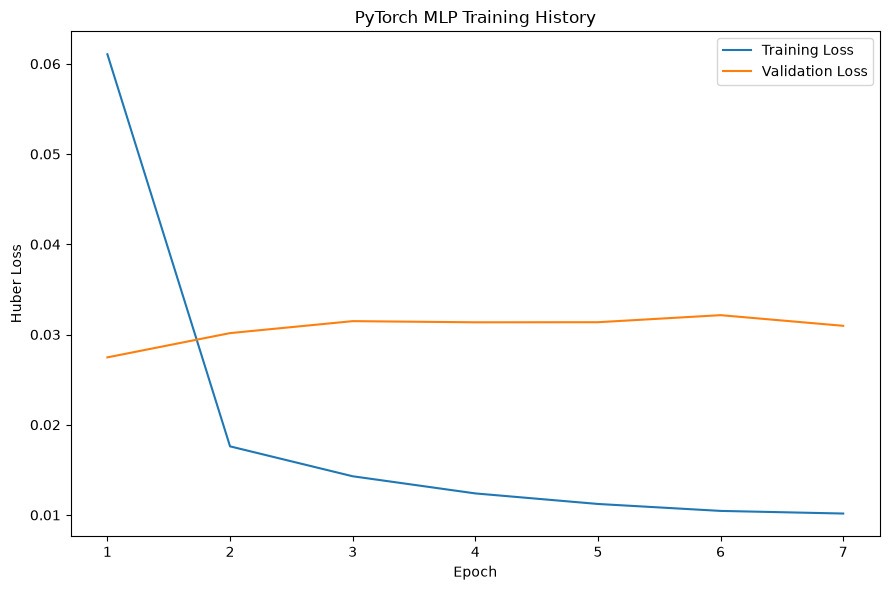

In [60]:
history_df = pd.DataFrame(history)

plt.figure(figsize=(9, 6))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Huber Loss")

plt.title(
    "PyTorch MLP Training History"
)

plt.legend()

plt.tight_layout()

plt.show()

In [61]:
model.eval()

predictions = []

with torch.no_grad():

    for X_batch, _ in val_loader:

        X_batch = X_batch.to(device)

        batch_predictions = (
            model(X_batch)
            .cpu()
            .numpy()
            .ravel()
        )

        predictions.extend(
            batch_predictions
        )

predictions = np.array(
    predictions
)

y_true = y_dl_val.values

mlp_rmse = np.sqrt(
    mean_squared_error(
        y_true,
        predictions
    )
)

mlp_mae = mean_absolute_error(
    y_true,
    predictions
)

mlp_r2 = r2_score(
    y_true,
    predictions
)

print(
    f"MLP RMSE: {mlp_rmse:.6f}"
)

print(
    f"MLP MAE: {mlp_mae:.6f}"
)

print(
    f"MLP R²: {mlp_r2:.6f}"
)

MLP RMSE: 0.234383
MLP MAE: 0.177977
MLP R²: 0.826247


In [62]:
mlp_development_result = pd.DataFrame({
    "Model": ["PyTorch MLP"],
    "RMSE": [mlp_rmse],
    "MAE": [mlp_mae],
    "R2": [mlp_r2]
})

mlp_development_result.to_csv(
    PROCESSED_DIR / "mlp_development_result.csv",
    index=False
)

print("Saved MLP development benchmark.")

Saved MLP development benchmark.


In [63]:
from sklearn.model_selection import GroupKFold

group_kfold = GroupKFold(n_splits=5)

print("MLP grouped CV ready.")
print("Observations:", len(X_dl))
print("Earthquakes:", groups_dl.nunique())

MLP grouped CV ready.
Observations: 280000
Earthquakes: 28


In [2]:
import copy
import time

mlp_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    group_kfold.split(
        X_dl,
        y_dl,
        groups=groups_dl
    ),
    start=1
):

    print(f"\n{'='*50}")
    print(f"Starting MLP Fold {fold}")
    print(f"{'='*50}")

    # -------------------------
    # Split by earthquake
    # -------------------------

    X_train_fold = X_dl.iloc[train_idx].copy()
    X_val_fold = X_dl.iloc[val_idx].copy()

    y_train_fold = y_dl.iloc[train_idx].copy()
    y_val_fold = y_dl.iloc[val_idx].copy()

    fold_train_events = groups_dl.iloc[train_idx].nunique()
    fold_val_events = groups_dl.iloc[val_idx].nunique()

    print(
        f"Train events: {fold_train_events} | "
        f"Validation events: {fold_val_events}"
    )

    # -------------------------
    # Fold-specific preprocessing
    # -------------------------

    fold_imputer = SimpleImputer(
        strategy="median"
    )

    fold_scaler = StandardScaler()

    X_train_imp = fold_imputer.fit_transform(
        X_train_fold
    )

    X_val_imp = fold_imputer.transform(
        X_val_fold
    )

    X_train_scaled = fold_scaler.fit_transform(
        X_train_imp
    )

    X_val_scaled = fold_scaler.transform(
        X_val_imp
    )

    # -------------------------
    # PyTorch tensors
    # -------------------------

    X_train_tensor = torch.tensor(
        X_train_scaled,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train_fold.values,
        dtype=torch.float32
    ).reshape(-1, 1)

    X_val_tensor = torch.tensor(
        X_val_scaled,
        dtype=torch.float32
    )

    y_val_tensor = torch.tensor(
        y_val_fold.values,
        dtype=torch.float32
    ).reshape(-1, 1)

    # -------------------------
    # DataLoaders
    # -------------------------

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    val_dataset = TensorDataset(
        X_val_tensor,
        y_val_tensor
    )

    train_loader_fold = DataLoader(
        train_dataset,
        batch_size=4096,
        shuffle=True,
        num_workers=0
    )

    val_loader_fold = DataLoader(
        val_dataset,
        batch_size=4096,
        shuffle=False,
        num_workers=0
    )

    # -------------------------
    # Fresh model
    # -------------------------

    fold_model = PGA_MLP(
        input_dim=X_train_tensor.shape[1]
    ).to(device)

    criterion_fold = nn.HuberLoss(
        delta=1.0
    )

    optimizer_fold = torch.optim.AdamW(
        fold_model.parameters(),
        lr=0.001,
        weight_decay=1e-4
    )

    scheduler_fold = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_fold,
        mode="min",
        factor=0.5,
        patience=2
    )

    # -------------------------
    # Training
    # -------------------------

    best_fold_loss = float("inf")
    best_fold_state = None
    no_improvement = 0

    max_epochs = 20
    early_stop_patience = 4

    fold_start = time.time()

    for epoch in range(max_epochs):

        fold_model.train()

        train_loss = 0.0
        train_count = 0

        for X_batch, y_batch in train_loader_fold:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer_fold.zero_grad()

            pred = fold_model(X_batch)

            loss = criterion_fold(
                pred,
                y_batch
            )

            loss.backward()

            optimizer_fold.step()

            train_loss += (
                loss.item() * len(X_batch)
            )

            train_count += len(X_batch)

        train_loss /= train_count

        # -------------------------
        # Validation loss
        # -------------------------

        fold_model.eval()

        val_loss = 0.0
        val_count = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader_fold:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                pred = fold_model(X_batch)

                loss = criterion_fold(
                    pred,
                    y_batch
                )

                val_loss += (
                    loss.item() * len(X_batch)
                )

                val_count += len(X_batch)

        val_loss /= val_count

        scheduler_fold.step(
            val_loss
        )

        print(
            f"Epoch {epoch+1:02d}: "
            f"train={train_loss:.5f}, "
            f"val={val_loss:.5f}"
        )

        # -------------------------
        # Early stopping
        # -------------------------

        if val_loss < best_fold_loss:

            best_fold_loss = val_loss

            best_fold_state = copy.deepcopy(
                fold_model.state_dict()
            )

            no_improvement = 0

        else:

            no_improvement += 1

            if no_improvement >= early_stop_patience:

                print("Early stopping.")

                break

    # Restore best model

    fold_model.load_state_dict(
        best_fold_state
    )

    # -------------------------
    # Final fold predictions
    # -------------------------

    fold_model.eval()

    fold_predictions = []

    with torch.no_grad():

        for X_batch, _ in val_loader_fold:

            X_batch = X_batch.to(device)

            pred = (
                fold_model(X_batch)
                .cpu()
                .numpy()
                .ravel()
            )

            fold_predictions.extend(
                pred
            )

    fold_predictions = np.asarray(
        fold_predictions
    )

    y_fold_true = y_val_fold.values

    rmse = np.sqrt(
        mean_squared_error(
            y_fold_true,
            fold_predictions
        )
    )

    mae = mean_absolute_error(
        y_fold_true,
        fold_predictions
    )

    r2 = r2_score(
        y_fold_true,
        fold_predictions
    )

    elapsed = (
        time.time() - fold_start
    ) / 60

    mlp_cv_results.append({
        "Fold": fold,
        "Validation Events": fold_val_events,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Training Minutes": elapsed
    })

    print(
        f"\nFold {fold} result:"
    )

    print(
        f"RMSE = {rmse:.6f}"
    )

    print(
        f"MAE  = {mae:.6f}"
    )

    print(
        f"R²   = {r2:.6f}"
    )

    print(
        f"Time = {elapsed:.2f} min"
    )

NameError: name 'group_kfold' is not defined

In [65]:
mlp_cv_results_df = pd.DataFrame(
    mlp_cv_results
)

display(mlp_cv_results_df)

,Fold,Validation Events,RMSE,MAE,R2,Training Minutes
0,1,6,0.197113,0.153128,0.817187,1.770337
1,2,6,0.293262,0.236212,0.626476,0.780779
2,3,6,0.225519,0.198944,0.795334,0.744592
3,4,5,0.207343,0.187633,0.878095,1.496430
4,5,5,0.140744,0.112339,0.890623,2.936713


In [4]:
mlp_cv_summary = pd.DataFrame({
    "Metric": [
        "RMSE",
        "MAE",
        "R2"
    ],
    "Mean": [
        mlp_cv_results_df["RMSE"].mean(),
        mlp_cv_results_df["MAE"].mean(),
        mlp_cv_results_df["R2"].mean()
    ],
    "Std": [
        mlp_cv_results_df["RMSE"].std(),
        mlp_cv_results_df["MAE"].std(),
        mlp_cv_results_df["R2"].std()
    ]
})

display(mlp_cv_summary)

NameError: name 'pd' is not defined

In [67]:
mlp_cv_results_df.to_csv(
    PROCESSED_DIR / "mlp_grouped_cv_results.csv",
    index=False
)

mlp_cv_summary.to_csv(
    PROCESSED_DIR / "mlp_grouped_cv_summary.csv",
    index=False
)

print("MLP grouped CV results saved.")

MLP grouped CV results saved.


In [3]:
mlp_cv_results_df.to_csv(
    PROCESSED_DIR / "mlp_grouped_cv_results.csv",
    index=False
)

mlp_cv_summary.to_csv(
    PROCESSED_DIR / "mlp_grouped_cv_summary.csv",
    index=False
)

print("MLP grouped CV results saved.")

NameError: name 'mlp_cv_results_df' is not defined

In [69]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Elastic Net",
        "LightGBM",
        "Physical Elastic Net",
        "PyTorch MLP"
    ],
    "Grouped CV RMSE": [
        elastic_sample_cv_df["RMSE"].mean(),
        lgb_cv_results_df["RMSE"].mean(),
        physical_cv_results_df["RMSE"].mean(),
        mlp_cv_results_df["RMSE"].mean()
    ],
    "Grouped CV MAE": [
        elastic_sample_cv_df["MAE"].mean(),
        lgb_cv_results_df["MAE"].mean(),
        physical_cv_results_df["MAE"].mean(),
        mlp_cv_results_df["MAE"].mean()
    ],
    "Grouped CV R2": [
        elastic_sample_cv_df["R2"].mean(),
        lgb_cv_results_df["R2"].mean(),
        physical_cv_results_df["R2"].mean(),
        mlp_cv_results_df["R2"].mean()
    ]
})

final_model_comparison = (
    final_model_comparison
    .sort_values("Grouped CV RMSE")
    .reset_index(drop=True)
)

display(final_model_comparison)

,Model,Grouped CV RMSE,Grouped CV MAE,Grouped CV R2
0,PyTorch MLP,0.212796,0.177651,0.801543
1,Elastic Net,0.247352,0.207955,0.731666
2,Physical Elastic Net,0.299878,0.235310,0.602133
3,LightGBM,0.316944,0.238501,0.557865


In [70]:
final_model_comparison.to_csv(
    PROCESSED_DIR / "final_model_comparison.csv",
    index=False
)

print("Final model comparison saved.")

Final model comparison saved.


In [71]:
# Final training features

final_features = [
    "magnitude",
    "event_depth",
    "epicentral_distance_km",
    "hypocentral_distance_km",
    "log_distance",
    "magnitude_squared",
    "magnitude_distance_interaction",
    "depth_distance_interaction",
    "Vs30_clean",
    "log_Vs30",
    "Vs30_available",
    "grid_lat",
    "grid_lon"
]

X_final_train = train_data[final_features].copy()
y_final_train = train_data["log_PGA"].copy()

X_final_val = val_data[final_features].copy()
y_final_val = val_data["log_PGA"].copy()

print("Final training:", X_final_train.shape)
print("Final validation:", X_final_val.shape)

print(
    "Training earthquakes:",
    train_data["event_id"].nunique()
)

print(
    "Validation earthquakes:",
    val_data["event_id"].nunique()
)

Final training: (2092176, 13)
Final validation: (468857, 13)
Training earthquakes: 28
Validation earthquakes: 6


In [72]:
final_imputer = SimpleImputer(
    strategy="median"
)

final_scaler = StandardScaler()

X_final_train_imp = final_imputer.fit_transform(
    X_final_train
)

X_final_val_imp = final_imputer.transform(
    X_final_val
)

X_final_train_scaled = final_scaler.fit_transform(
    X_final_train_imp
)

X_final_val_scaled = final_scaler.transform(
    X_final_val_imp
)

print(
    "Train matrix:",
    X_final_train_scaled.shape
)

print(
    "Validation matrix:",
    X_final_val_scaled.shape
)

print(
    "Remaining NaNs:",
    np.isnan(X_final_train_scaled).sum(),
    np.isnan(X_final_val_scaled).sum()
)

Train matrix: (2092176, 13)
Validation matrix: (468857, 13)
Remaining NaNs: 0 0


In [73]:
X_train_tensor_final = torch.tensor(
    X_final_train_scaled,
    dtype=torch.float32
)

y_train_tensor_final = torch.tensor(
    y_final_train.values,
    dtype=torch.float32
).reshape(-1, 1)

X_val_tensor_final = torch.tensor(
    X_final_val_scaled,
    dtype=torch.float32
)

y_val_tensor_final = torch.tensor(
    y_final_val.values,
    dtype=torch.float32
).reshape(-1, 1)


train_dataset_final = TensorDataset(
    X_train_tensor_final,
    y_train_tensor_final
)

val_dataset_final = TensorDataset(
    X_val_tensor_final,
    y_val_tensor_final
)


train_loader_final = DataLoader(
    train_dataset_final,
    batch_size=8192,
    shuffle=True,
    num_workers=0
)

val_loader_final = DataLoader(
    val_dataset_final,
    batch_size=8192,
    shuffle=False,
    num_workers=0
)

print(
    "Training batches:",
    len(train_loader_final)
)

print(
    "Validation batches:",
    len(val_loader_final)
)

Training batches: 256
Validation batches: 58


In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import copy
import time

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

PROCESSED_DIR = Path(
    r"C:\Documents\Earthquake_ML_DL\data\processed"
)

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

PyTorch: 2.13.0+cpu
CUDA: False


In [6]:
class PGA_MLP(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 64),
            nn.ReLU(),

            nn.BatchNorm1d(64),
            nn.Dropout(0.15),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.BatchNorm1d(32),
            nn.Dropout(0.10),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

In [7]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


Using device: cpu


In [8]:
train_data = pd.read_csv(
    PROCESSED_DIR / "train_data.csv"
)

val_data = pd.read_csv(
    PROCESSED_DIR / "validation_data.csv"
)

test_data = pd.read_csv(
    PROCESSED_DIR / "test_data.csv"
)

print("Train:", train_data.shape)
print("Validation:", val_data.shape)
print("Test:", test_data.shape)

Train: (2092176, 26)
Validation: (468857, 26)
Test: (312336, 26)


In [9]:
final_features = [
    "magnitude",
    "event_depth",
    "epicentral_distance_km",
    "hypocentral_distance_km",
    "log_distance",
    "magnitude_squared",
    "magnitude_distance_interaction",
    "depth_distance_interaction",
    "Vs30_clean",
    "log_Vs30",
    "Vs30_available",
    "grid_lat",
    "grid_lon"
]

X_final_train = train_data[
    final_features
].copy()

y_final_train = train_data[
    "log_PGA"
].copy()

X_final_val = val_data[
    final_features
].copy()

y_final_val = val_data[
    "log_PGA"
].copy()

print(
    "Training:",
    X_final_train.shape
)

print(
    "Validation:",
    X_final_val.shape
)

Training: (2092176, 13)
Validation: (468857, 13)


In [10]:
final_imputer = SimpleImputer(
    strategy="median"
)

final_scaler = StandardScaler()

X_final_train_imp = final_imputer.fit_transform(
    X_final_train
)

X_final_val_imp = final_imputer.transform(
    X_final_val
)

X_final_train_scaled = final_scaler.fit_transform(
    X_final_train_imp
)

X_final_val_scaled = final_scaler.transform(
    X_final_val_imp
)

print(
    "Train:",
    X_final_train_scaled.shape
)

print(
    "Validation:",
    X_final_val_scaled.shape
)

print(
    "NaNs:",
    np.isnan(X_final_train_scaled).sum(),
    np.isnan(X_final_val_scaled).sum()
)

Train: (2092176, 13)
Validation: (468857, 13)
NaNs: 0 0


In [11]:
X_train_tensor_final = torch.tensor(
    X_final_train_scaled,
    dtype=torch.float32
)

y_train_tensor_final = torch.tensor(
    y_final_train.values,
    dtype=torch.float32
).reshape(-1, 1)

X_val_tensor_final = torch.tensor(
    X_final_val_scaled,
    dtype=torch.float32
)

y_val_tensor_final = torch.tensor(
    y_final_val.values,
    dtype=torch.float32
).reshape(-1, 1)

train_dataset_final = TensorDataset(
    X_train_tensor_final,
    y_train_tensor_final
)

val_dataset_final = TensorDataset(
    X_val_tensor_final,
    y_val_tensor_final
)

train_loader_final = DataLoader(
    train_dataset_final,
    batch_size=8192,
    shuffle=True,
    num_workers=0
)

val_loader_final = DataLoader(
    val_dataset_final,
    batch_size=8192,
    shuffle=False,
    num_workers=0
)

print(
    "Training batches:",
    len(train_loader_final)
)

print(
    "Validation batches:",
    len(val_loader_final)
)

Training batches: 256
Validation batches: 58


In [12]:
import copy
import time

final_model = PGA_MLP(
    input_dim=len(final_features)
).to(device)

final_criterion = nn.HuberLoss(
    delta=1.0
)

final_optimizer = torch.optim.AdamW(
    final_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

final_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    final_optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

best_val_loss = float("inf")
best_final_state = None
epochs_without_improvement = 0

final_history = []

max_epochs = 30
early_stopping_patience = 6

start_time = time.time()

for epoch in range(max_epochs):

    # =========================
    # TRAINING
    # =========================

    final_model.train()

    train_loss = 0.0
    train_count = 0

    for X_batch, y_batch in train_loader_final:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        final_optimizer.zero_grad()

        predictions = final_model(X_batch)

        loss = final_criterion(
            predictions,
            y_batch
        )

        loss.backward()

        final_optimizer.step()

        train_loss += (
            loss.item() *
            len(X_batch)
        )

        train_count += len(X_batch)

    train_loss /= train_count


    # =========================
    # VALIDATION
    # =========================

    final_model.eval()

    val_loss = 0.0
    val_count = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader_final:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = final_model(
                X_batch
            )

            loss = final_criterion(
                predictions,
                y_batch
            )

            val_loss += (
                loss.item() *
                len(X_batch)
            )

            val_count += len(X_batch)

    val_loss /= val_count

    final_scheduler.step(
        val_loss
    )

    final_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "learning_rate":
            final_optimizer.param_groups[0]["lr"]
    })

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train: {train_loss:.5f} | "
        f"Val: {val_loss:.5f}"
    )


    # =========================
    # BEST MODEL
    # =========================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_final_state = copy.deepcopy(
            final_model.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= early_stopping_patience
        ):

            print(
                "Early stopping triggered."
            )

            break


final_model.load_state_dict(
    best_final_state
)

training_minutes = (
    time.time() - start_time
) / 60

print(
    f"\nTraining time: "
    f"{training_minutes:.2f} minutes"
)

print(
    "Best validation loss:",
    best_val_loss
)

Epoch 01 | Train: 0.02272 | Val: 0.01173
Epoch 02 | Train: 0.00845 | Val: 0.01662
Epoch 03 | Train: 0.00639 | Val: 0.02168
Epoch 04 | Train: 0.00538 | Val: 0.02063
Epoch 05 | Train: 0.00477 | Val: 0.02570
Epoch 06 | Train: 0.00441 | Val: 0.02798
Epoch 07 | Train: 0.00421 | Val: 0.02990
Early stopping triggered.

Training time: 8.56 minutes
Best validation loss: 0.011732673068597764


In [13]:
final_model.eval()

val_predictions = []

with torch.no_grad():

    for X_batch, _ in val_loader_final:

        X_batch = X_batch.to(device)

        predictions = (
            final_model(X_batch)
            .cpu()
            .numpy()
            .ravel()
        )

        val_predictions.extend(
            predictions
        )

val_predictions = np.asarray(
    val_predictions
)

validation_rmse = np.sqrt(
    mean_squared_error(
        y_final_val,
        val_predictions
    )
)

validation_mae = mean_absolute_error(
    y_final_val,
    val_predictions
)

validation_r2 = r2_score(
    y_final_val,
    val_predictions
)

print(
    f"Validation RMSE: {validation_rmse:.6f}"
)

print(
    f"Validation MAE: {validation_mae:.6f}"
)

print(
    f"Validation R²: {validation_r2:.6f}"
)

Validation RMSE: 0.153184
Validation MAE: 0.129661
Validation R²: 0.952719


In [14]:
MODEL_DIR = Path(
    r"C:\Documents\Earthquake_ML_DL\models"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

torch.save(
    final_model.state_dict(),
    MODEL_DIR / "pga_mlp_development.pt"
)

print(
    "Saved:",
    MODEL_DIR / "pga_mlp_development.pt"
)

Saved: C:\Documents\Earthquake_ML_DL\models\pga_mlp_development.pt


In [15]:
import joblib

joblib.dump(
    final_imputer,
    MODEL_DIR / "pga_imputer.pkl"
)

joblib.dump(
    final_scaler,
    MODEL_DIR / "pga_scaler.pkl"
)

print("Preprocessing objects saved.")

Preprocessing objects saved.


In [16]:
final_validation_result = pd.DataFrame({
    "Model": ["PyTorch MLP"],
    "RMSE": [validation_rmse],
    "MAE": [validation_mae],
    "R2": [validation_r2]
})

final_validation_result.to_csv(
    PROCESSED_DIR /
    "final_validation_result.csv",
    index=False
)

display(final_validation_result)

,Model,RMSE,MAE,R2
0,PyTorch MLP,0.153184,0.129661,0.952719


In [17]:
# Final untouched test data

X_final_test = test_data[
    final_features
].copy()

y_final_test = test_data[
    "log_PGA"
].copy()

test_events = test_data[
    "event_id"
].copy()

print("Test observations:", len(X_final_test))
print("Test earthquakes:", test_events.nunique())

print(
    "Test events:",
    sorted(test_events.unique())
)

Test observations: 312336
Test earthquakes: 6
Test events: ['c000kmdj', 'us10002n5q', 'us100030qs', 'us10004dtm', 'us2000299v', 'usc000sy0y']


In [18]:
X_final_test_imp = final_imputer.transform(
    X_final_test
)

X_final_test_scaled = final_scaler.transform(
    X_final_test_imp
)

print(
    "Test matrix:",
    X_final_test_scaled.shape
)

print(
    "Remaining NaNs:",
    np.isnan(X_final_test_scaled).sum()
)

Test matrix: (312336, 13)
Remaining NaNs: 0


In [19]:
X_test_tensor = torch.tensor(
    X_final_test_scaled,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_final_test.values,
    dtype=torch.float32
).reshape(-1, 1)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8192,
    shuffle=False,
    num_workers=0
)

print(
    "Test batches:",
    len(test_loader)
)

Test batches: 39


In [20]:
final_model.eval()

test_predictions = []

with torch.no_grad():

    for X_batch, _ in test_loader:

        X_batch = X_batch.to(device)

        predictions = (
            final_model(X_batch)
            .cpu()
            .numpy()
            .ravel()
        )

        test_predictions.extend(
            predictions
        )

test_predictions = np.asarray(
    test_predictions
)

print(
    "Predictions:",
    len(test_predictions)
)

Predictions: 312336


In [21]:
test_rmse = np.sqrt(
    mean_squared_error(
        y_final_test,
        test_predictions
    )
)

test_mae = mean_absolute_error(
    y_final_test,
    test_predictions
)

test_r2 = r2_score(
    y_final_test,
    test_predictions
)

print("=" * 50)
print("FINAL UNSEEN-EARTHQUAKE TEST RESULTS")
print("=" * 50)

print(
    f"RMSE: {test_rmse:.6f}"
)

print(
    f"MAE : {test_mae:.6f}"
)

print(
    f"R²  : {test_r2:.6f}"
)

FINAL UNSEEN-EARTHQUAKE TEST RESULTS
RMSE: 0.311307
MAE : 0.280031
R²  : 0.609882


In [22]:
test_results = pd.DataFrame({
    "event_id": test_events.values,
    "observed_log_PGA": y_final_test.values,
    "predicted_log_PGA": test_predictions
})

per_event_results = []

for event_id, group in test_results.groupby(
    "event_id"
):

    rmse = np.sqrt(
        mean_squared_error(
            group["observed_log_PGA"],
            group["predicted_log_PGA"]
        )
    )

    mae = mean_absolute_error(
        group["observed_log_PGA"],
        group["predicted_log_PGA"]
    )

    r2 = r2_score(
        group["observed_log_PGA"],
        group["predicted_log_PGA"]
    )

    per_event_results.append({
        "event_id": event_id,
        "observations": len(group),
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

per_event_results_df = pd.DataFrame(
    per_event_results
)

display(
    per_event_results_df.sort_values(
        "RMSE"
    )
)


,event_id,observations,RMSE,MAE,R2
4,us2000299v,51333,0.090761,0.067085,0.946099
3,us10004dtm,46754,0.230863,0.226697,-3.012260
1,us10002n5q,56876,0.264110,0.257634,0.573855
5,usc000sy0y,54225,0.356432,0.346913,-0.701572
2,us100030qs,46754,0.382508,0.365731,-2.411448
0,c000kmdj,56394,0.413823,0.405309,-0.155539


In [23]:
test_results.to_csv(
    PROCESSED_DIR /
    "final_test_predictions.csv",
    index=False
)

per_event_results_df.to_csv(
    PROCESSED_DIR /
    "final_test_per_event_results.csv",
    index=False
)

final_test_metrics = pd.DataFrame({
    "Metric": [
        "RMSE",
        "MAE",
        "R2"
    ],
    "Value": [
        test_rmse,
        test_mae,
        test_r2
    ]
})

final_test_metrics.to_csv(
    PROCESSED_DIR /
    "final_test_metrics.csv",
    index=False
)

print(
    "Final test results saved."
)

Final test results saved.


In [24]:
test_event_summary = (
    test_data
    .groupby("event_id")
    .agg(
        magnitude=("magnitude", "first"),
        depth_km=("event_depth", "first"),
        observations=("event_id", "size"),
        mean_log_PGA=("log_PGA", "mean"),
        std_log_PGA=("log_PGA", "std"),
        mean_distance=("hypocentral_distance_km", "mean"),
        mean_vs30=("Vs30_clean", "mean"),
        vs30_available=("Vs30_available", "mean")
    )
    .reset_index()
)

display(
    test_event_summary.sort_values(
        "event_id"
    )
)

,event_id,magnitude,depth_km,observations,mean_log_PGA,std_log_PGA,mean_distance,mean_vs30,vs30_available
0,c000kmdj,5.4,23.00,56394,-0.857649,0.384970,167.616678,302.762128,0.038550
1,us10002n5q,5.5,8.71,56876,-0.778865,0.404586,167.780351,394.778364,0.001688
2,us100030qs,5.9,224.00,46754,0.193205,0.207098,266.538245,805.193395,0.928006
3,us10004dtm,5.7,239.00,46754,-0.381532,0.115256,279.284609,790.477638,0.936134
4,us2000299v,5.1,13.61,51333,-0.811584,0.390935,152.022927,557.918532,0.932071
5,usc000sy0y,5.3,66.00,54225,-0.175818,0.273247,175.084051,455.028313,0.899548


In [25]:
train_event_summary = (
    train_data
    .groupby("event_id")
    .agg(
        magnitude=("magnitude", "first"),
        depth_km=("event_depth", "first"),
        observations=("event_id", "size"),
        mean_log_PGA=("log_PGA", "mean"),
        mean_distance=("hypocentral_distance_km", "mean"),
        mean_vs30=("Vs30_clean", "mean")
    )
    .reset_index()
)

print("TRAIN EVENT RANGES")
print(
    train_event_summary[
        [
            "magnitude",
            "depth_km",
            "mean_distance",
            "mean_vs30"
        ]
    ].describe()
)

print("\nTEST EVENT RANGES")
print(
    test_event_summary[
        [
            "magnitude",
            "depth_km",
            "mean_distance",
            "mean_vs30"
        ]
    ].describe()
)

TRAIN EVENT RANGES
       magnitude    depth_km  mean_distance   mean_vs30
count  28.000000   28.000000      28.000000   28.000000
mean    5.550000   41.797143     196.626069  517.292147
std     0.375648   57.685019      53.984948  137.999656
min     5.100000    6.610000     136.079696  292.939056
25%     5.275000   10.000000     165.154652  438.623199
50%     5.500000   15.830000     169.974102  474.808694
75%     5.650000   40.832500     247.113433  567.815403
max     6.600000  206.940000     339.320251  820.070843

TEST EVENT RANGES
       magnitude    depth_km  mean_distance   mean_vs30
count   6.000000    6.000000       6.000000    6.000000
mean    5.483333   95.720000     201.387810  551.026395
std     0.285774  107.209315      56.055723  208.446390
min     5.100000    8.710000     152.022927  302.762128
25%     5.325000   15.957500     167.657596  409.840851
50%     5.450000   44.500000     171.432201  506.473422
75%     5.650000  184.500000     243.674696  732.337861
max     5.

In [26]:
print(
    "Training magnitude:",
    train_data["magnitude"].min(),
    "→",
    train_data["magnitude"].max()
)

print(
    "Test magnitude:",
    test_data["magnitude"].min(),
    "→",
    test_data["magnitude"].max()
)

print()

print(
    "Training depth:",
    train_data["event_depth"].min(),
    "→",
    train_data["event_depth"].max()
)

print(
    "Test depth:",
    test_data["event_depth"].min(),
    "→",
    test_data["event_depth"].max()
)

Training magnitude: 5.1 → 6.6
Test magnitude: 5.1 → 5.9

Training depth: 6.61 → 206.94
Test depth: 8.71 → 239.0


In [27]:
event_prediction_summary = (
    test_results
    .groupby("event_id")
    .agg(
        observed_mean=("observed_log_PGA", "mean"),
        predicted_mean=("predicted_log_PGA", "mean"),
        observed_std=("observed_log_PGA", "std"),
        predicted_std=("predicted_log_PGA", "std"),
        observations=("observed_log_PGA", "size")
    )
    .reset_index()
)

event_prediction_summary["mean_residual"] = (
    event_prediction_summary["observed_mean"]
    -
    event_prediction_summary["predicted_mean"]
)

event_prediction_summary["absolute_mean_error"] = (
    event_prediction_summary["mean_residual"]
    .abs()
)

display(
    event_prediction_summary
    .sort_values("mean_residual")
)

,event_id,observed_mean,predicted_mean,observed_std,predicted_std,observations,mean_residual,absolute_mean_error
0,c000kmdj,-0.857649,-0.452339,0.384970,0.317668,56394,-0.405309,0.405309
1,us10002n5q,-0.778865,-0.521234,0.404586,0.356135,56876,-0.257631,0.257631
3,us10004dtm,-0.381532,-0.154835,0.115256,0.105847,46754,-0.226697,0.226697
4,us2000299v,-0.811584,-0.829744,0.390935,0.369546,51333,0.018160,0.018160
5,usc000sy0y,-0.175818,-0.522731,0.273247,0.306866,54225,0.346912,0.346912
2,us100030qs,0.193205,-0.172426,0.207098,0.107716,46754,0.365631,0.365631


In [28]:
event_prediction_analysis = (
    event_prediction_summary
    .merge(
        test_event_summary[
            [
                "event_id",
                "magnitude",
                "depth_km",
                "mean_distance",
                "mean_vs30",
                "vs30_available"
            ]
        ],
        on="event_id",
        how="left"
    )
)

display(
    event_prediction_analysis.sort_values(
        "mean_residual"
    )
)

,event_id,observed_mean,predicted_mean,observed_std,predicted_std,observations,mean_residual,absolute_mean_error,magnitude,depth_km,mean_distance,mean_vs30,vs30_available
0,c000kmdj,-0.857649,-0.452339,0.384970,0.317668,56394,-0.405309,0.405309,5.4,23.00,167.616678,302.762128,0.038550
1,us10002n5q,-0.778865,-0.521234,0.404586,0.356135,56876,-0.257631,0.257631,5.5,8.71,167.780351,394.778364,0.001688
3,us10004dtm,-0.381532,-0.154835,0.115256,0.105847,46754,-0.226697,0.226697,5.7,239.00,279.284609,790.477638,0.936134
4,us2000299v,-0.811584,-0.829744,0.390935,0.369546,51333,0.018160,0.018160,5.1,13.61,152.022927,557.918532,0.932071
5,usc000sy0y,-0.175818,-0.522731,0.273247,0.306866,54225,0.346912,0.346912,5.3,66.00,175.084051,455.028313,0.899548
2,us100030qs,0.193205,-0.172426,0.207098,0.107716,46754,0.365631,0.365631,5.9,224.00,266.538245,805.193395,0.928006


In [29]:
print("Mean residual by event:")
print(
    event_prediction_analysis[
        [
            "event_id",
            "depth_km",
            "magnitude",
            "mean_vs30",
            "vs30_available",
            "mean_residual"
        ]
    ].sort_values(
        "mean_residual"
    ).to_string(index=False)
)

Mean residual by event:
  event_id  depth_km  magnitude  mean_vs30  vs30_available  mean_residual
  c000kmdj     23.00        5.4 302.762128        0.038550      -0.405309
us10002n5q      8.71        5.5 394.778364        0.001688      -0.257631
us10004dtm    239.00        5.7 790.477638        0.936134      -0.226697
us2000299v     13.61        5.1 557.918532        0.932071       0.018160
usc000sy0y     66.00        5.3 455.028313        0.899548       0.346912
us100030qs    224.00        5.9 805.193395        0.928006       0.365631


In [30]:
residual_df = test_results.copy()

residual_df["residual"] = (
    residual_df["observed_log_PGA"]
    - residual_df["predicted_log_PGA"]
)

residual_df["absolute_error"] = (
    residual_df["residual"].abs()
)

print(
    "Residual observations:",
    len(residual_df)
)

print(
    "\nResidual statistics:"
)

display(
    residual_df["residual"].describe()
)

Residual observations: 312336

Residual statistics:


count    312336.000000
mean         -0.036085
std           0.309209
min          -0.584507
25%          -0.286000
50%          -0.170686
75%           0.286074
max           0.660122
Name: residual, dtype: float64

In [31]:
residual_features = test_data[
    [
        "event_id",
        "magnitude",
        "event_depth",
        "epicentral_distance_km",
        "hypocentral_distance_km",
        "Vs30_clean",
        "Vs30_available",
        "grid_lat",
        "grid_lon"
    ]
].reset_index(drop=True)

residual_analysis = pd.concat(
    [
        residual_df.reset_index(drop=True),
        residual_features
    ],
    axis=1
)

print(
    residual_analysis.shape
)

display(
    residual_analysis.head()
)

(312336, 14)


,event_id,observed_log_PGA,predicted_log_PGA,residual,absolute_error,event_id,magnitude,event_depth,epicentral_distance_km,hypocentral_distance_km,Vs30_clean,Vs30_available,grid_lat,grid_lon
0,us10002n5q,-1.397940,-1.306537,-0.091403,0.091403,us10002n5q,5.5,8.71,307.798585,307.921796,355.38710,1,13.3834,93.0320
1,us10002n5q,-1.397940,-1.279593,-0.118347,0.118347,us10002n5q,5.5,8.71,306.522919,306.646644,332.79767,1,13.3834,93.0487
2,us10002n5q,-1.522879,-1.318202,-0.204677,0.204677,us10002n5q,5.5,8.71,305.260287,305.384523,NaN,0,13.3834,93.0653
3,us10002n5q,-1.522879,-1.310414,-0.212465,0.212465,us10002n5q,5.5,8.71,303.995542,304.120295,NaN,0,13.3834,93.0820
4,us10002n5q,-1.522879,-1.302650,-0.220228,0.220228,us10002n5q,5.5,8.71,302.736378,302.861649,NaN,0,13.3834,93.0987


In [32]:
residual_corr = (
    residual_analysis[
        [
            "residual",
            "magnitude",
            "event_depth",
            "epicentral_distance_km",
            "hypocentral_distance_km",
            "Vs30_clean",
            "Vs30_available"
        ]
    ]
    .corr()["residual"]
    .sort_values()
)

display(residual_corr)

epicentral_distance_km    -0.204325
Vs30_clean                -0.119532
hypocentral_distance_km    0.058487
magnitude                  0.104040
event_depth                0.314770
Vs30_available             0.665654
residual                   1.000000
Name: residual, dtype: float64

In [33]:
vs30_residual_summary = (
    residual_analysis
    .groupby("Vs30_available")
    .agg(
        observations=("residual", "size"),
        mean_residual=("residual", "mean"),
        mean_absolute_error=("absolute_error", "mean"),
        residual_std=("residual", "std")
    )
    .reset_index()
)

display(
    vs30_residual_summary
)

,Vs30_available,observations,mean_residual,mean_absolute_error,residual_std
0,0,126286,-0.285912,0.322492,0.183259
1,1,186050,0.133490,0.251209,0.258055


In [35]:
# Rebuild event-level residual summary safely

event_residual_summary = (
    residual_analysis
    .loc[:, ~residual_analysis.columns.duplicated()]
    .groupby("event_id")
    .agg(
        observations=("residual", "size"),
        mean_residual=("residual", "mean"),
        median_residual=("residual", "median"),
        residual_std=("residual", "std"),
        mean_absolute_error=("absolute_error", "mean")
    )
    .reset_index()
)

display(
    event_residual_summary.sort_values(
        "mean_absolute_error",
        ascending=False
    )
)

,event_id,observations,mean_residual,median_residual,residual_std,mean_absolute_error
0,c000kmdj,56394,-0.405309,-0.418653,0.083511,0.405309
2,us100030qs,46754,0.365631,0.376153,0.112369,0.365731
5,usc000sy0y,54225,0.346913,0.361976,0.081828,0.346913
1,us10002n5q,56876,-0.257631,-0.266044,0.058142,0.257634
3,us10004dtm,46754,-0.226697,-0.222983,0.043664,0.226697
4,us2000299v,51333,0.018160,0.040409,0.088927,0.067085


In [36]:
residual_analysis.to_csv(
    PROCESSED_DIR /
    "final_test_residuals.csv",
    index=False
)

event_residual_summary.to_csv(
    PROCESSED_DIR /
    "final_test_event_residual_summary.csv",
    index=False
)

vs30_residual_summary.to_csv(
    PROCESSED_DIR /
    "final_test_vs30_residual_summary.csv",
    index=False
)

print(
    "Residual analysis saved."
)


Residual analysis saved.


In [37]:
# Remove duplicate columns permanently
residual_analysis = residual_analysis.loc[
    :,
    ~residual_analysis.columns.duplicated()
]

print("Duplicate columns removed.")

print(
    "event_id columns:",
    sum(residual_analysis.columns == "event_id")
)

Duplicate columns removed.
event_id columns: 1


In [38]:
residual_corr = (
    residual_analysis[
        [
            "residual",
            "absolute_error",
            "magnitude",
            "event_depth",
            "epicentral_distance_km",
            "hypocentral_distance_km",
            "Vs30_clean",
            "Vs30_available"
        ]
    ]
    .corr()
)

print("Correlation with residual:")
display(
    residual_corr["residual"]
    .sort_values()
)

Correlation with residual:


epicentral_distance_km    -0.204325
Vs30_clean                -0.119532
absolute_error             0.053235
hypocentral_distance_km    0.058487
magnitude                  0.104040
event_depth                0.314770
Vs30_available             0.665654
residual                   1.000000
Name: residual, dtype: float64

In [39]:
absolute_error_corr = (
    residual_analysis[
        [
            "absolute_error",
            "magnitude",
            "event_depth",
            "epicentral_distance_km",
            "hypocentral_distance_km",
            "Vs30_clean",
            "Vs30_available"
        ]
    ]
    .corr()["absolute_error"]
    .sort_values()
)

print("Correlation with absolute error:")
display(absolute_error_corr)

Correlation with absolute error:


Vs30_available            -0.257234
Vs30_clean                 0.114045
epicentral_distance_km     0.134086
event_depth                0.134274
hypocentral_distance_km    0.219754
magnitude                  0.375919
absolute_error             1.000000
Name: absolute_error, dtype: float64

In [40]:
vs30_residual_summary = (
    residual_analysis
    .groupby("Vs30_available")
    .agg(
        observations=("residual", "size"),
        mean_residual=("residual", "mean"),
        median_residual=("residual", "median"),
        mean_absolute_error=("absolute_error", "mean"),
        residual_std=("residual", "std")
    )
    .reset_index()
)

display(vs30_residual_summary)

,Vs30_available,observations,mean_residual,median_residual,mean_absolute_error,residual_std
0,0,126286,-0.285912,-0.306764,0.322492,0.183259
1,1,186050,0.133490,0.113227,0.251209,0.258055


In [41]:
event_residual_final = (
    residual_analysis
    .groupby("event_id")
    .agg(
        observations=("residual", "size"),
        mean_residual=("residual", "mean"),
        median_residual=("residual", "median"),
        residual_std=("residual", "std"),
        mean_absolute_error=("absolute_error", "mean")
    )
    .reset_index()
    .sort_values(
        "mean_absolute_error",
        ascending=False
    )
)

display(event_residual_final)

,event_id,observations,mean_residual,median_residual,residual_std,mean_absolute_error
0,c000kmdj,56394,-0.405309,-0.418653,0.083511,0.405309
2,us100030qs,46754,0.365631,0.376153,0.112369,0.365731
5,usc000sy0y,54225,0.346913,0.361976,0.081828,0.346913
1,us10002n5q,56876,-0.257631,-0.266044,0.058142,0.257634
3,us10004dtm,46754,-0.226697,-0.222983,0.043664,0.226697
4,us2000299v,51333,0.018160,0.040409,0.088927,0.067085


In [42]:
residual_corr.to_csv(
    PROCESSED_DIR /
    "residual_correlation_matrix.csv"
)

absolute_error_corr.to_csv(
    PROCESSED_DIR /
    "absolute_error_correlations.csv"
)

vs30_residual_summary.to_csv(
    PROCESSED_DIR /
    "residual_by_vs30_availability.csv",
    index=False
)

event_residual_final.to_csv(
    PROCESSED_DIR /
    "final_event_residual_analysis.csv",
    index=False
)

print("Residual diagnostic statistics saved.")

Residual diagnostic statistics saved.


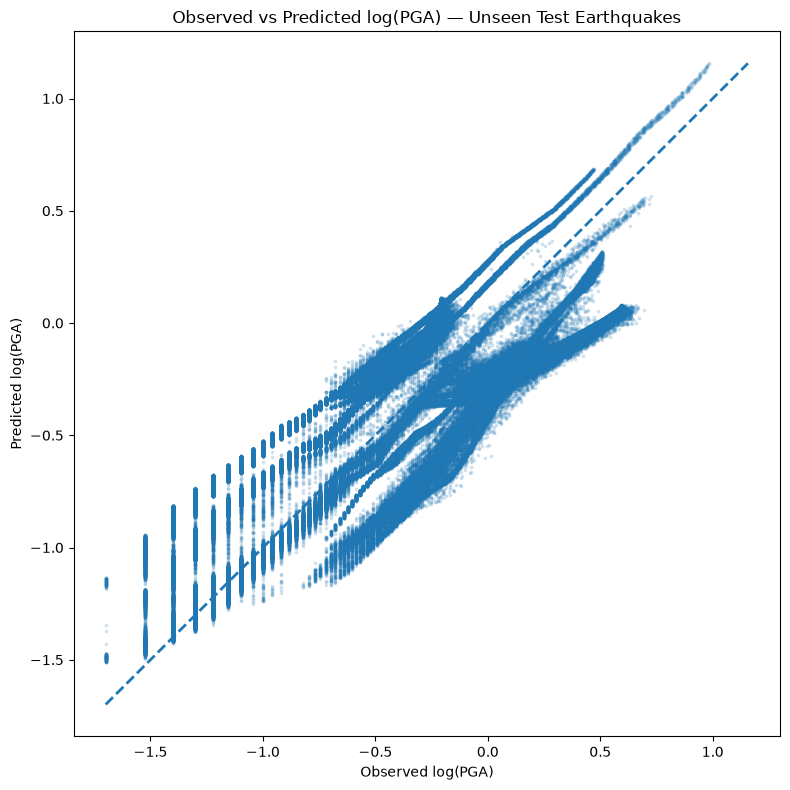

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.scatter(
    residual_analysis["observed_log_PGA"],
    residual_analysis["predicted_log_PGA"],
    s=3,
    alpha=0.15
)

# 1:1 reference line
min_val = min(
    residual_analysis["observed_log_PGA"].min(),
    residual_analysis["predicted_log_PGA"].min()
)

max_val = max(
    residual_analysis["observed_log_PGA"].max(),
    residual_analysis["predicted_log_PGA"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Observed log(PGA)")
plt.ylabel("Predicted log(PGA)")

plt.title(
    "Observed vs Predicted log(PGA) — Unseen Test Earthquakes"
)

plt.tight_layout()

plt.show()

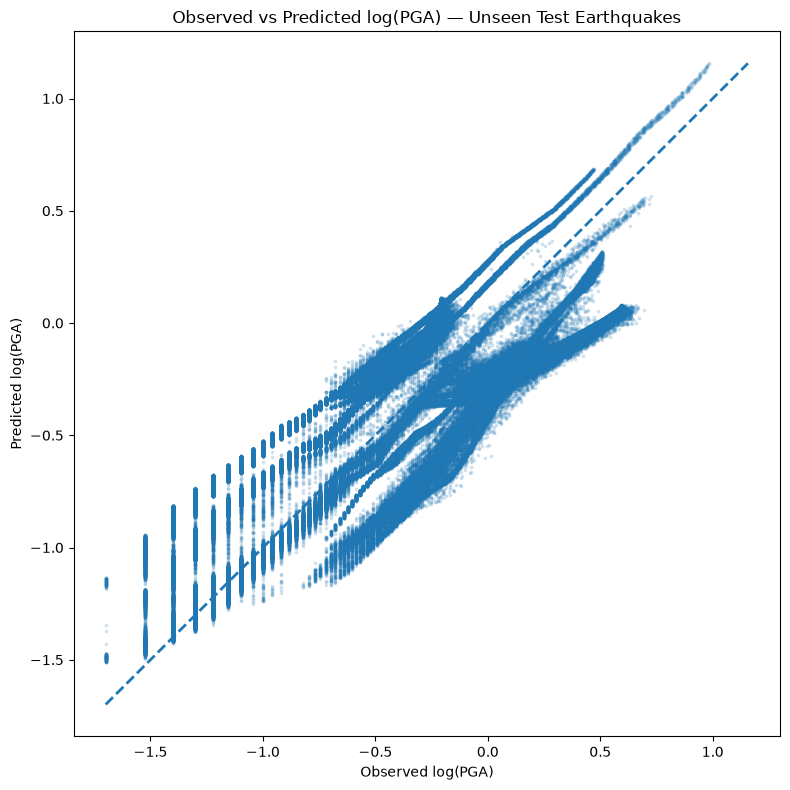

Saved observed vs predicted figure.


In [44]:
FIGURES_DIR = Path(
    r"C:\Documents\Earthquake_ML_DL\figures"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

plt.figure(figsize=(8, 8))

plt.scatter(
    residual_analysis["observed_log_PGA"],
    residual_analysis["predicted_log_PGA"],
    s=3,
    alpha=0.15
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Observed log(PGA)")
plt.ylabel("Predicted log(PGA)")

plt.title(
    "Observed vs Predicted log(PGA) — Unseen Test Earthquakes"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "observed_vs_predicted_log_pga.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved observed vs predicted figure."
)

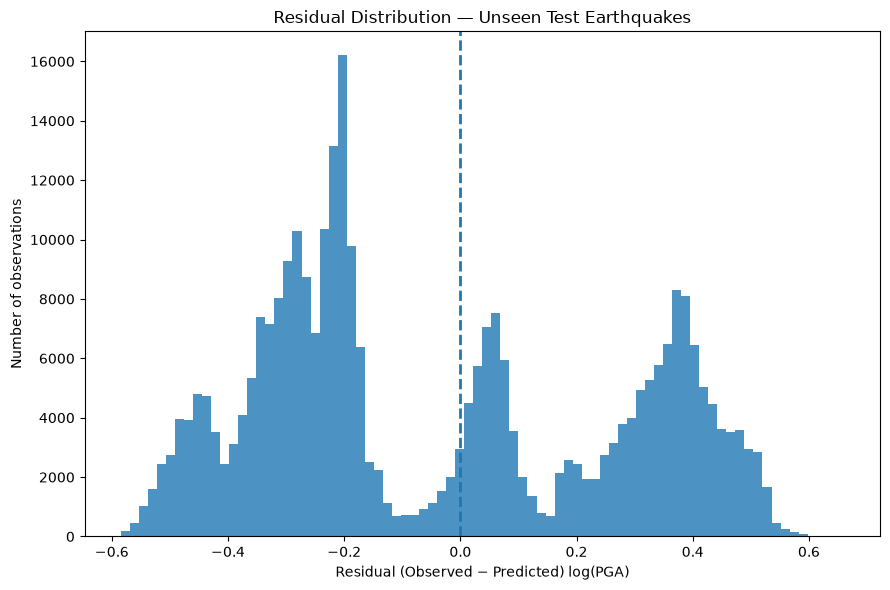

In [45]:
plt.figure(figsize=(9, 6))

plt.hist(
    residual_analysis["residual"],
    bins=80,
    alpha=0.8
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Residual (Observed − Predicted) log(PGA)"
)

plt.ylabel("Number of observations")

plt.title(
    "Residual Distribution — Unseen Test Earthquakes"
)

plt.tight_layout()

plt.show()

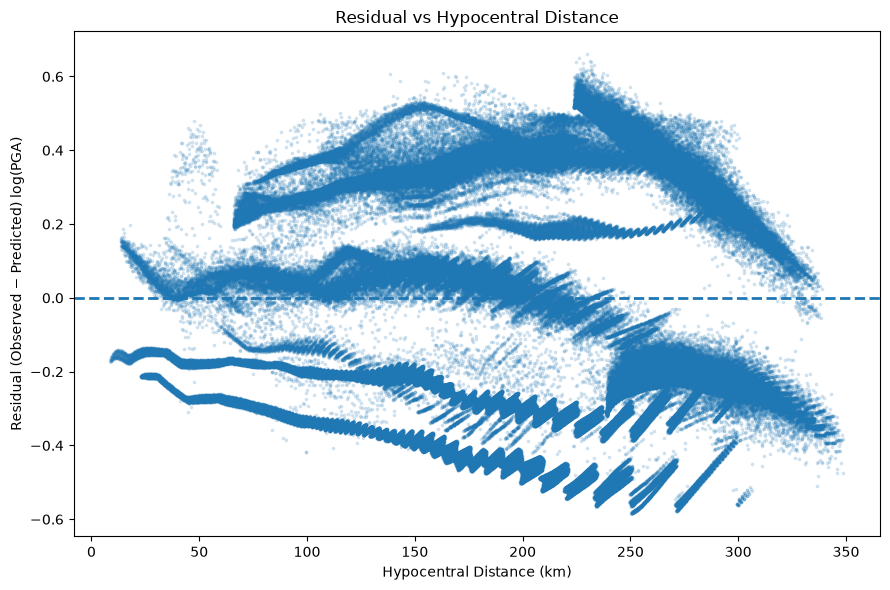

In [46]:
plt.figure(figsize=(9, 6))

plt.scatter(
    residual_analysis["hypocentral_distance_km"],
    residual_analysis["residual"],
    s=3,
    alpha=0.15
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Hypocentral Distance (km)"
)

plt.ylabel(
    "Residual (Observed − Predicted) log(PGA)"
)

plt.title(
    "Residual vs Hypocentral Distance"
)

plt.tight_layout()

plt.show()

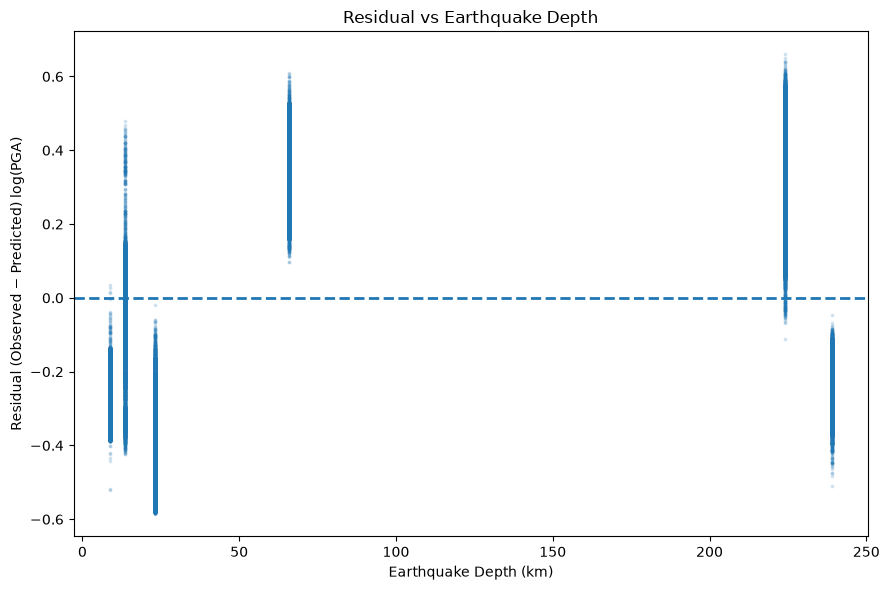

In [47]:
plt.figure(figsize=(9, 6))

plt.scatter(
    residual_analysis["event_depth"],
    residual_analysis["residual"],
    s=3,
    alpha=0.15
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Earthquake Depth (km)"
)

plt.ylabel(
    "Residual (Observed − Predicted) log(PGA)"
)

plt.title(
    "Residual vs Earthquake Depth"
)

plt.tight_layout()

plt.show()

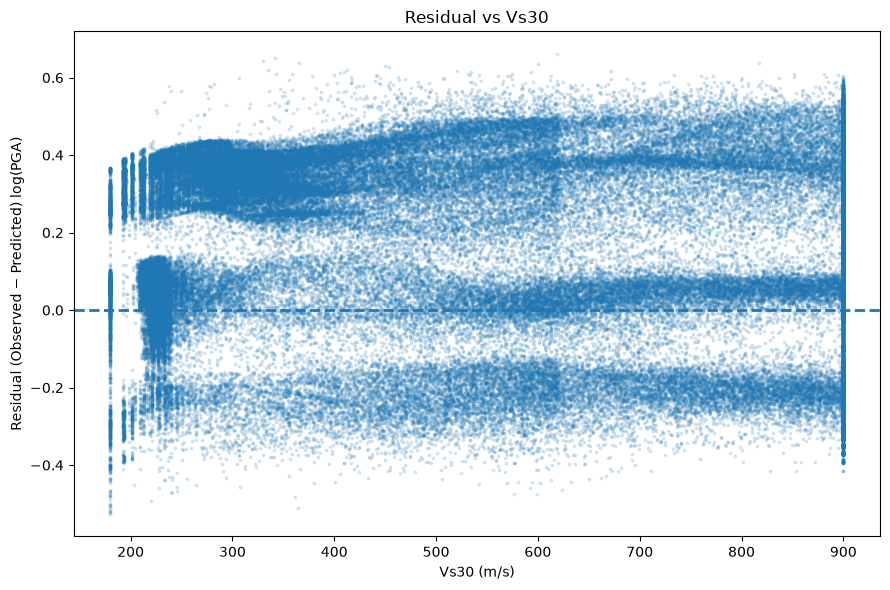

In [48]:
plt.figure(figsize=(9, 6))

valid_vs30 = residual_analysis[
    residual_analysis["Vs30_clean"].notna()
]

plt.scatter(
    valid_vs30["Vs30_clean"],
    valid_vs30["residual"],
    s=3,
    alpha=0.15
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Vs30 (m/s)"
)

plt.ylabel(
    "Residual (Observed − Predicted) log(PGA)"
)

plt.title(
    "Residual vs Vs30"
)

plt.tight_layout()

plt.show()

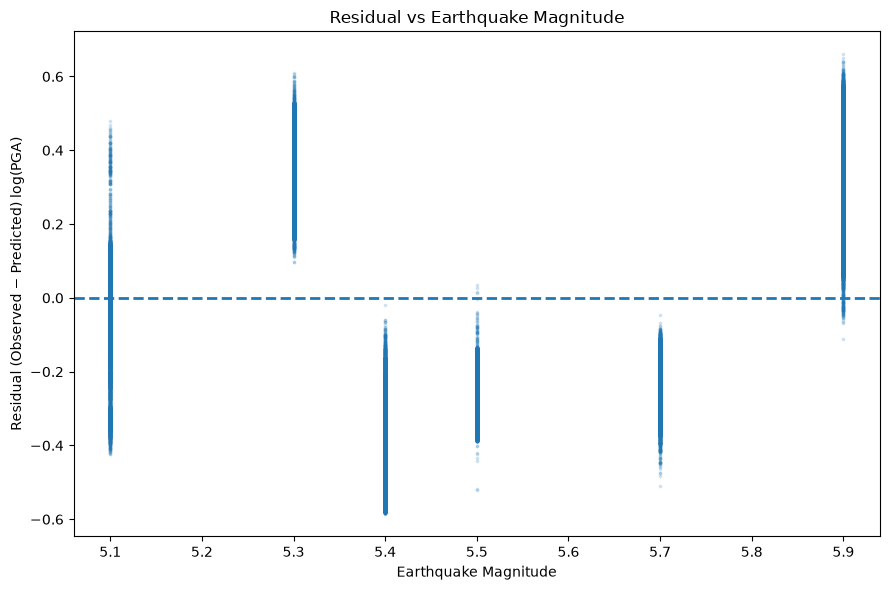

In [49]:
plt.figure(figsize=(9, 6))

plt.scatter(
    residual_analysis["magnitude"],
    residual_analysis["residual"],
    s=3,
    alpha=0.15
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Earthquake Magnitude"
)

plt.ylabel(
    "Residual (Observed − Predicted) log(PGA)"
)

plt.title(
    "Residual vs Earthquake Magnitude"
)

plt.tight_layout()

plt.show()

In [50]:
# Helper function

def save_residual_plot(
    x,
    y,
    xlabel,
    ylabel,
    title,
    filename
):

    plt.figure(figsize=(9, 6))

    plt.scatter(
        x,
        y,
        s=3,
        alpha=0.15
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=2
    )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

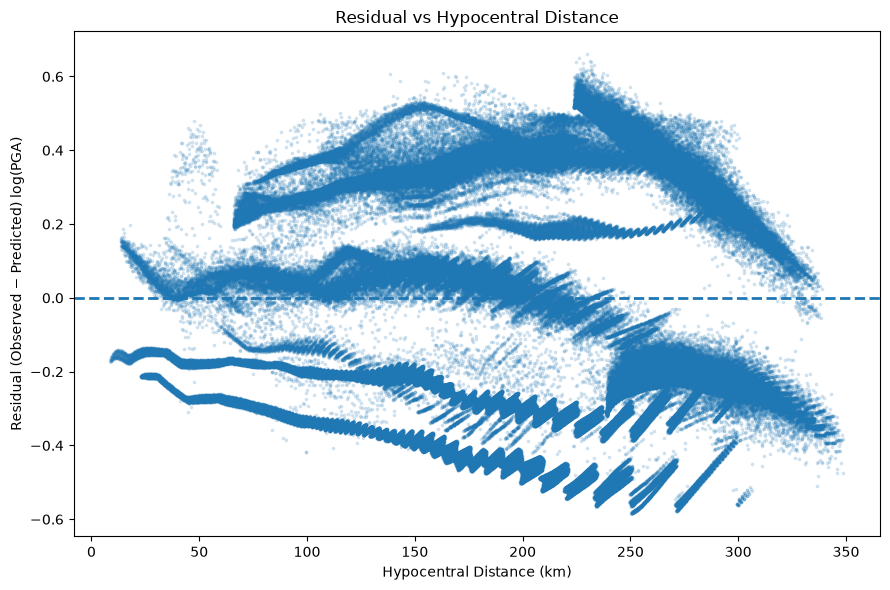

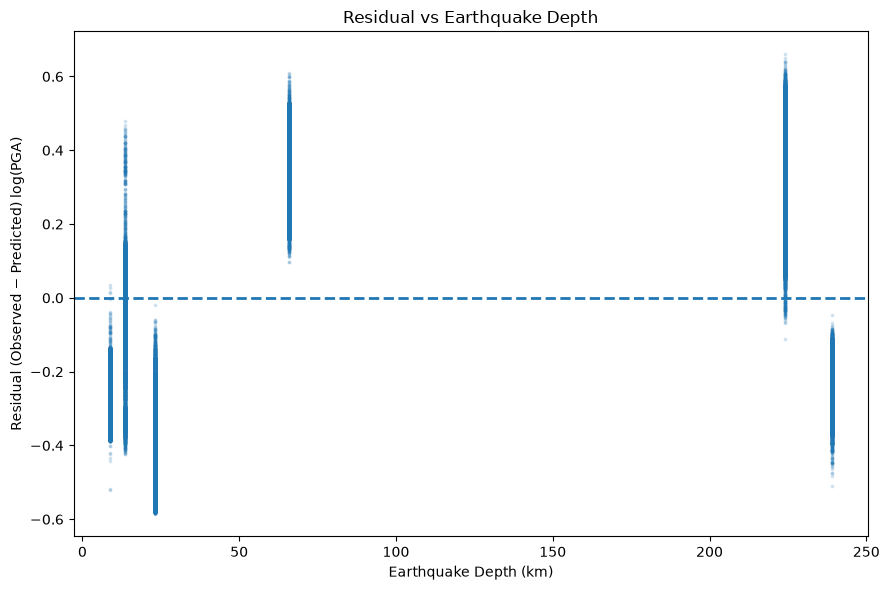

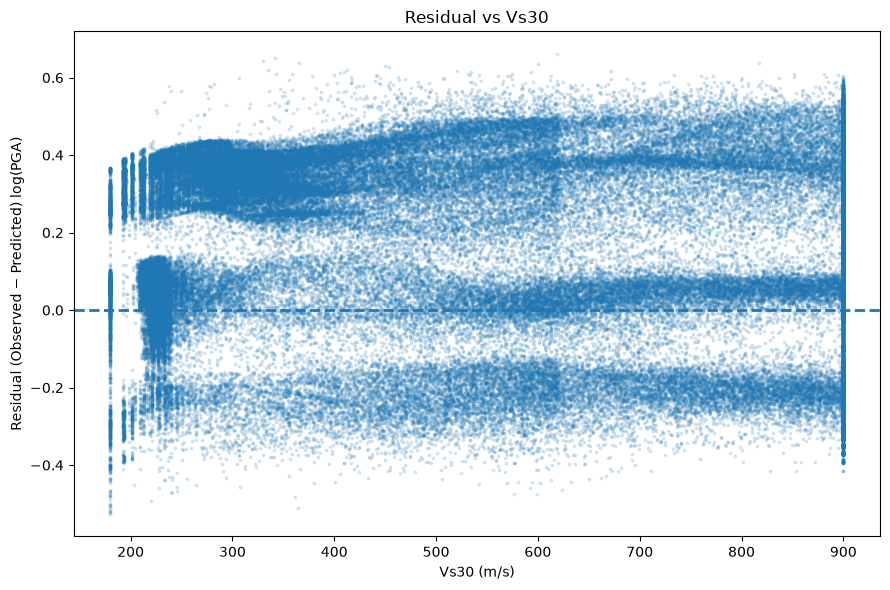

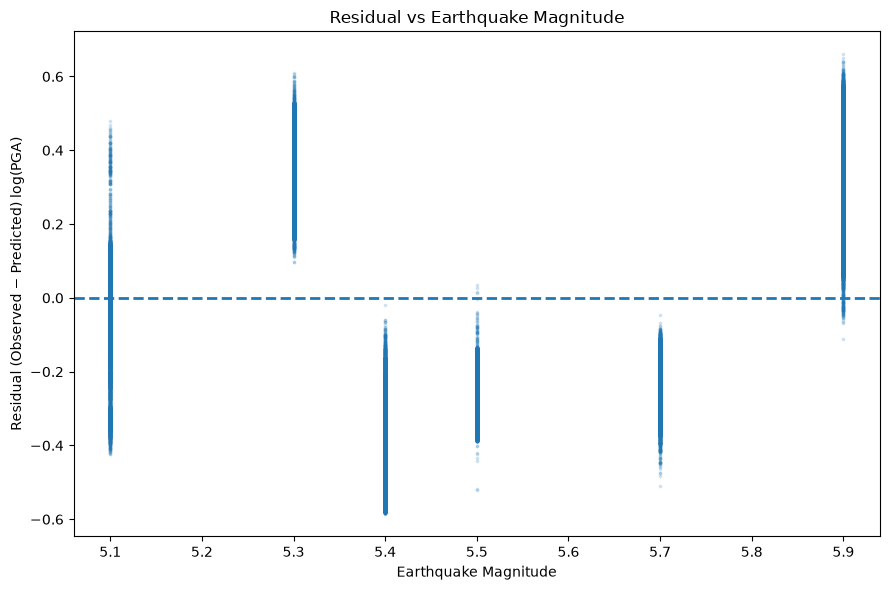

In [51]:
save_residual_plot(
    residual_analysis["hypocentral_distance_km"],
    residual_analysis["residual"],
    "Hypocentral Distance (km)",
    "Residual (Observed − Predicted) log(PGA)",
    "Residual vs Hypocentral Distance",
    "residual_vs_distance.png"
)

save_residual_plot(
    residual_analysis["event_depth"],
    residual_analysis["residual"],
    "Earthquake Depth (km)",
    "Residual (Observed − Predicted) log(PGA)",
    "Residual vs Earthquake Depth",
    "residual_vs_depth.png"
)

save_residual_plot(
    valid_vs30["Vs30_clean"],
    valid_vs30["residual"],
    "Vs30 (m/s)",
    "Residual (Observed − Predicted) log(PGA)",
    "Residual vs Vs30",
    "residual_vs_vs30.png"
)

save_residual_plot(
    residual_analysis["magnitude"],
    residual_analysis["residual"],
    "Earthquake Magnitude",
    "Residual (Observed − Predicted) log(PGA)",
    "Residual vs Earthquake Magnitude",
    "residual_vs_magnitude.png"
)

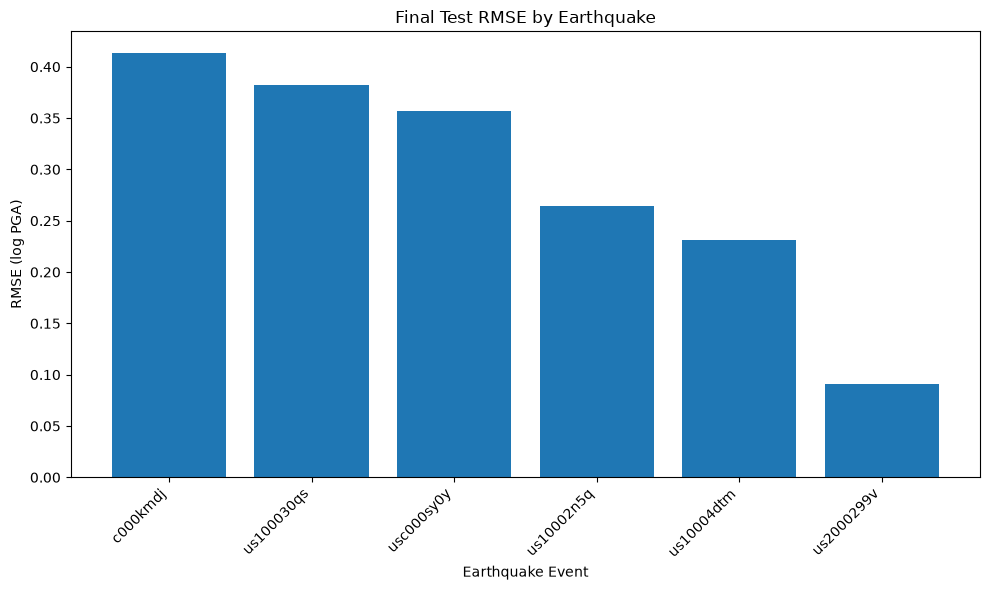

In [52]:
event_plot_df = (
    per_event_results_df
    .sort_values("RMSE", ascending=False)
    .copy()
)

plt.figure(figsize=(10, 6))

plt.bar(
    event_plot_df["event_id"],
    event_plot_df["RMSE"]
)

plt.xlabel("Earthquake Event")
plt.ylabel("RMSE (log PGA)")

plt.title(
    "Final Test RMSE by Earthquake"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

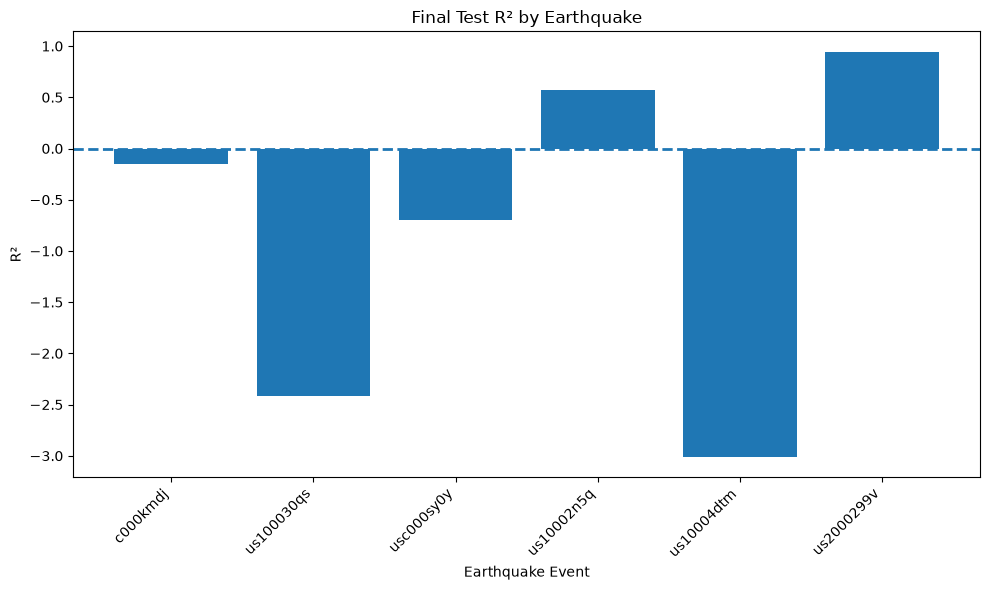

In [53]:
plt.figure(figsize=(10, 6))

plt.bar(
    event_plot_df["event_id"],
    event_plot_df["R2"]
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Earthquake Event")
plt.ylabel("R²")

plt.title(
    "Final Test R² by Earthquake"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

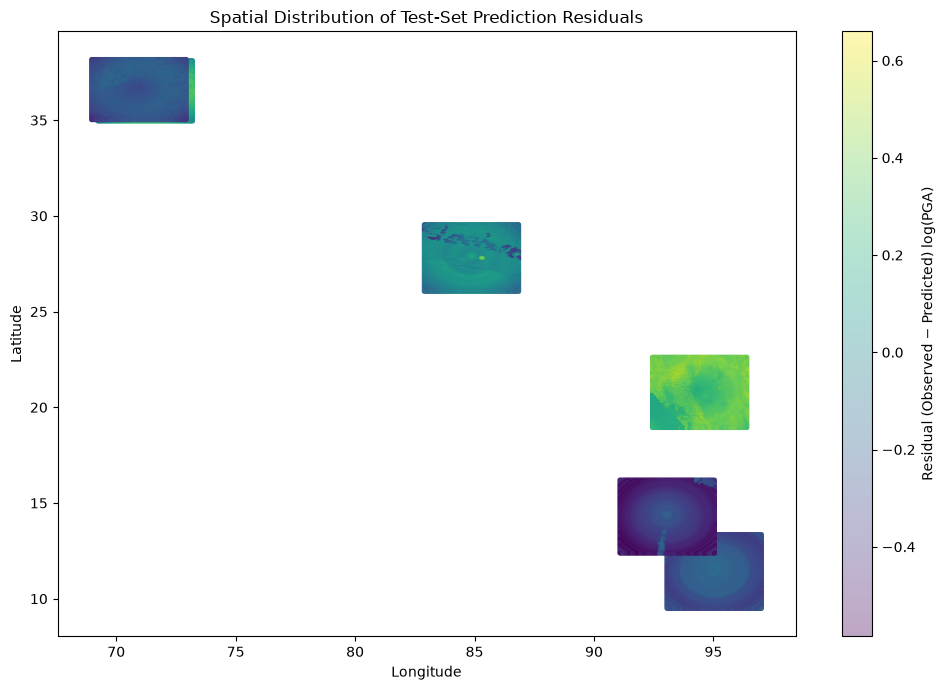

In [54]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    residual_analysis["grid_lon"],
    residual_analysis["grid_lat"],
    c=residual_analysis["residual"],
    s=3,
    alpha=0.35
)

plt.colorbar(
    scatter,
    label="Residual (Observed − Predicted) log(PGA)"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Spatial Distribution of Test-Set Prediction Residuals"
)

plt.tight_layout()

plt.show()

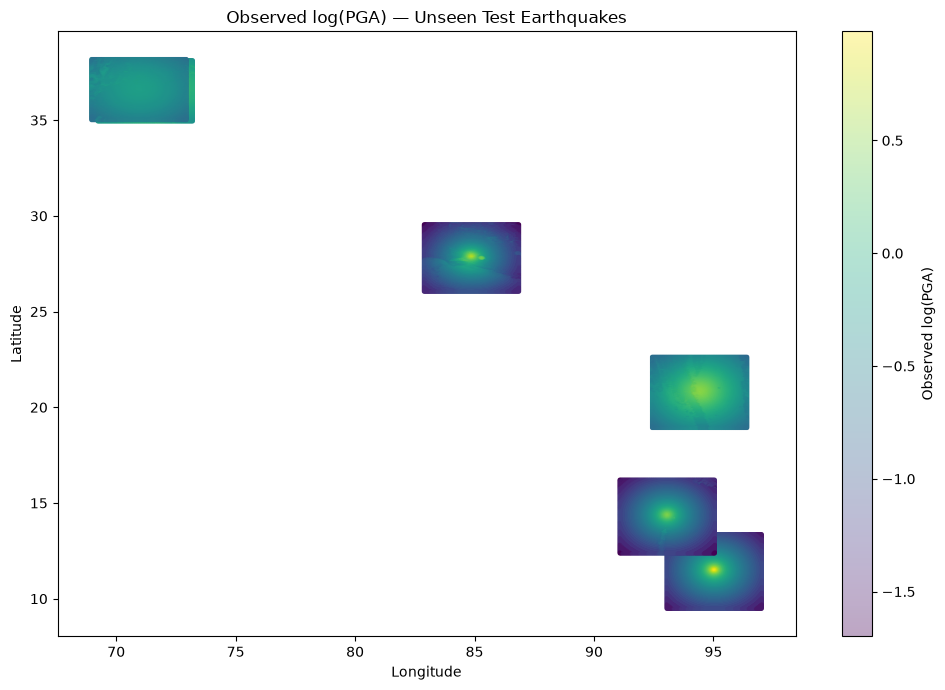

In [55]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    residual_analysis["grid_lon"],
    residual_analysis["grid_lat"],
    c=residual_analysis["observed_log_PGA"],
    s=3,
    alpha=0.35
)

plt.colorbar(
    scatter,
    label="Observed log(PGA)"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Observed log(PGA) — Unseen Test Earthquakes"
)

plt.tight_layout()

plt.show()

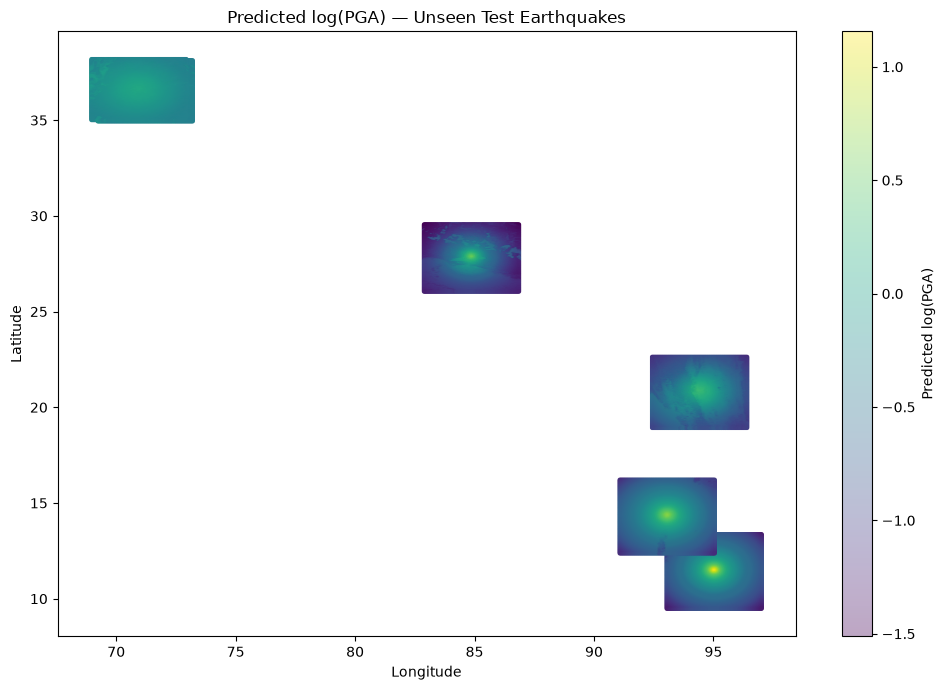

In [56]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    residual_analysis["grid_lon"],
    residual_analysis["grid_lat"],
    c=residual_analysis["predicted_log_PGA"],
    s=3,
    alpha=0.35
)

plt.colorbar(
    scatter,
    label="Predicted log(PGA)"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Predicted log(PGA) — Unseen Test Earthquakes"
)

plt.tight_layout()

plt.show()

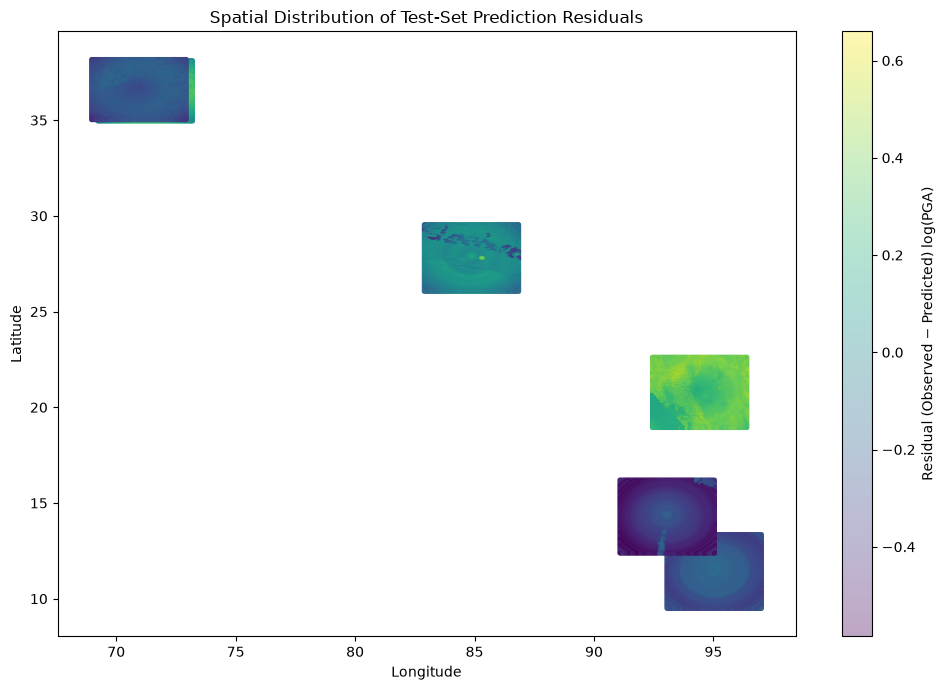

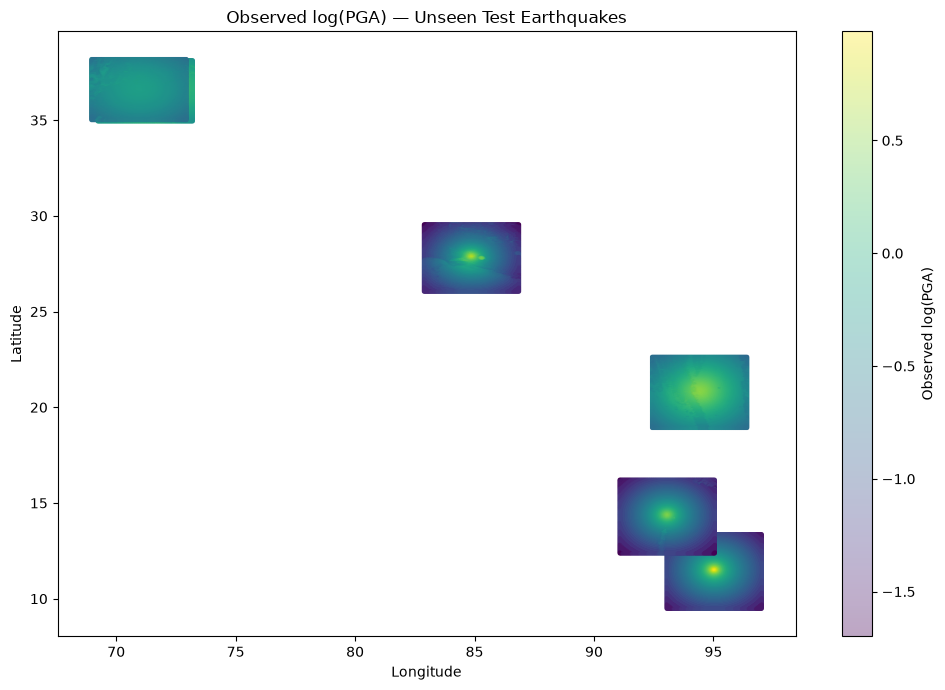

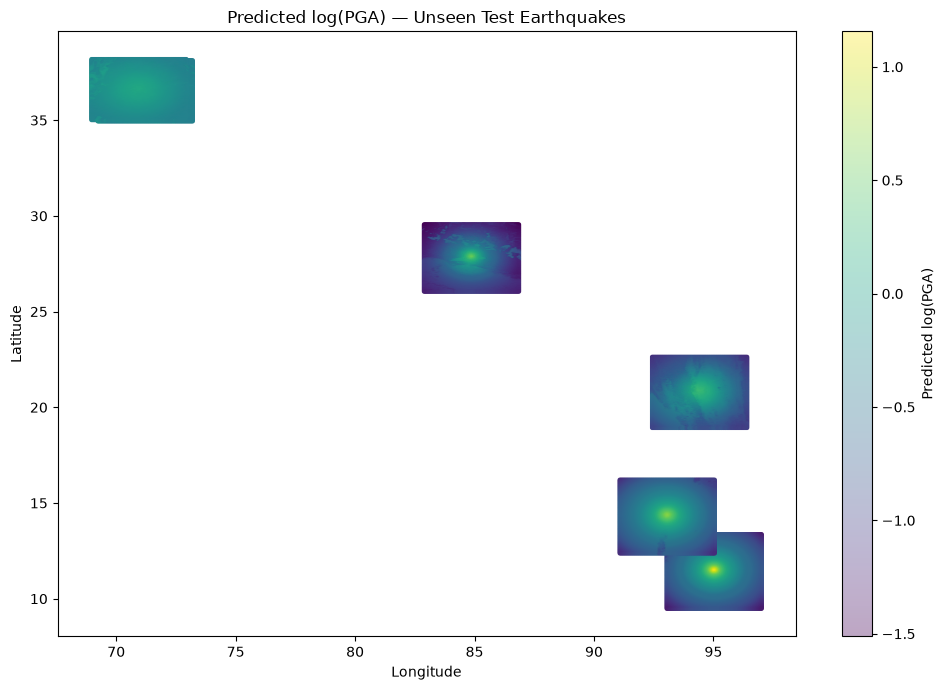

Spatial figures saved.


In [57]:
# Residual map
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    residual_analysis["grid_lon"],
    residual_analysis["grid_lat"],
    c=residual_analysis["residual"],
    s=3,
    alpha=0.35
)

plt.colorbar(
    scatter,
    label="Residual (Observed − Predicted) log(PGA)"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Spatial Distribution of Test-Set Prediction Residuals"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "spatial_residual_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Observed map
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    residual_analysis["grid_lon"],
    residual_analysis["grid_lat"],
    c=residual_analysis["observed_log_PGA"],
    s=3,
    alpha=0.35
)

plt.colorbar(
    scatter,
    label="Observed log(PGA)"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Observed log(PGA) — Unseen Test Earthquakes"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "spatial_observed_log_pga.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Predicted map
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    residual_analysis["grid_lon"],
    residual_analysis["grid_lat"],
    c=residual_analysis["predicted_log_PGA"],
    s=3,
    alpha=0.35
)

plt.colorbar(
    scatter,
    label="Predicted log(PGA)"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Predicted log(PGA) — Unseen Test Earthquakes"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "spatial_predicted_log_pga.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Spatial figures saved.")

In [60]:
final_results_table = pd.DataFrame({
    "Model": [
        "Elastic Net",
        "LightGBM",
        "Physical Elastic Net",
        "PyTorch MLP"
    ],
    "Grouped_CV_RMSE": [
        0.247352,
        0.316944,
        0.299878,
        0.212796
    ],
    "Grouped_CV_MAE": [
        0.207955,
        0.238501,
        0.235310,
        0.177651
    ],
    "Grouped_CV_R2": [
        0.731666,
        0.557865,
        0.602133,
        0.801543
    ]
})

display(final_results_table)

,Model,Grouped_CV_RMSE,Grouped_CV_MAE,Grouped_CV_R2
0,Elastic Net,0.247352,0.207955,0.731666
1,LightGBM,0.316944,0.238501,0.557865
2,Physical Elastic Net,0.299878,0.235310,0.602133
3,PyTorch MLP,0.212796,0.177651,0.801543


In [61]:
final_test_row = pd.DataFrame({
    "Model": [
        "PyTorch MLP — Final Unseen Test"
    ],
    "Grouped_CV_RMSE": [np.nan],
    "Grouped_CV_MAE": [np.nan],
    "Grouped_CV_R2": [np.nan],
    "Test_RMSE": [test_rmse],
    "Test_MAE": [test_mae],
    "Test_R2": [test_r2]
})

final_results_table_extended = final_results_table.copy()

final_results_table_extended["Test_RMSE"] = np.nan
final_results_table_extended["Test_MAE"] = np.nan
final_results_table_extended["Test_R2"] = np.nan

final_results_table_extended = pd.concat(
    [
        final_results_table_extended,
        final_test_row
    ],
    ignore_index=True
)

display(final_results_table_extended)

,Model,Grouped_CV_RMSE,Grouped_CV_MAE,Grouped_CV_R2,Test_RMSE,Test_MAE,Test_R2
0,Elastic Net,0.247352,0.207955,0.731666,NaN,NaN,NaN
1,LightGBM,0.316944,0.238501,0.557865,NaN,NaN,NaN
2,Physical Elastic Net,0.299878,0.235310,0.602133,NaN,NaN,NaN
3,PyTorch MLP,0.212796,0.177651,0.801543,NaN,NaN,NaN
4,PyTorch MLP — Final Unseen Test,NaN,NaN,NaN,0.311307,0.280031,0.609882


In [62]:
final_results_table_extended.to_csv(
    PROCESSED_DIR / "final_model_results_table.csv",
    index=False
)

print("Final results table saved.")

Final results table saved.


In [63]:
from sklearn.inspection import permutation_importance

importance_sample_size = min(
    50000,
    len(X_final_test_scaled)
)

rng = np.random.default_rng(42)

importance_indices = rng.choice(
    len(X_final_test_scaled),
    size=importance_sample_size,
    replace=False
)

X_importance = X_final_test_scaled[
    importance_indices
]

y_importance = y_final_test.values[
    importance_indices
]

print(
    "Importance sample:",
    X_importance.shape
)

Importance sample: (50000, 13)


In [64]:
importance_tensor = torch.tensor(
    X_importance,
    dtype=torch.float32
).to(device)

final_model.eval()

with torch.no_grad():

    baseline_predictions = (
        final_model(
            importance_tensor
        )
        .cpu()
        .numpy()
        .ravel()
    )

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_importance,
        baseline_predictions
    )
)

print(
    f"Baseline RMSE: {baseline_rmse:.6f}"
)

Baseline RMSE: 0.310901


In [65]:
feature_importance_results = []

X_importance_work = X_importance.copy()

for feature_idx, feature_name in enumerate(
    final_features
):

    X_permuted = X_importance_work.copy()

    permutation = rng.permutation(
        len(X_permuted)
    )

    X_permuted[:, feature_idx] = (
        X_permuted[
            permutation,
            feature_idx
        ]
    )

    X_permuted_tensor = torch.tensor(
        X_permuted,
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():

        permuted_predictions = (
            final_model(
                X_permuted_tensor
            )
            .cpu()
            .numpy()
            .ravel()
        )

    permuted_rmse = np.sqrt(
        mean_squared_error(
            y_importance,
            permuted_predictions
        )
    )

    rmse_increase = (
        permuted_rmse
        -
        baseline_rmse
    )

    feature_importance_results.append({
        "Feature": feature_name,
        "Baseline_RMSE": baseline_rmse,
        "Permuted_RMSE": permuted_rmse,
        "RMSE_Increase": rmse_increase
    })

    print(
        f"{feature_name}: "
        f"RMSE increase = "
        f"{rmse_increase:.6f}"
    )

magnitude: RMSE increase = 0.024855
event_depth: RMSE increase = 0.305552
epicentral_distance_km: RMSE increase = 0.018391
hypocentral_distance_km: RMSE increase = 0.036995
log_distance: RMSE increase = 0.077425
magnitude_squared: RMSE increase = 0.008795
magnitude_distance_interaction: RMSE increase = 0.002392
depth_distance_interaction: RMSE increase = 0.095010
Vs30_clean: RMSE increase = 0.046545
log_Vs30: RMSE increase = 0.052331
Vs30_available: RMSE increase = -0.029376
grid_lat: RMSE increase = 0.013970
grid_lon: RMSE increase = 0.043700


In [66]:
permutation_importance_df = (
    pd.DataFrame(
        feature_importance_results
    )
    .sort_values(
        "RMSE_Increase",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    permutation_importance_df
)

,Feature,Baseline_RMSE,Permuted_RMSE,RMSE_Increase
0,event_depth,0.310901,0.616454,0.305552
1,depth_distance_interaction,0.310901,0.405911,0.095010
2,log_distance,0.310901,0.388326,0.077425
3,log_Vs30,0.310901,0.363232,0.052331
4,Vs30_clean,0.310901,0.357446,0.046545
5,grid_lon,0.310901,0.354601,0.043700
6,hypocentral_distance_km,0.310901,0.347896,0.036995
7,magnitude,0.310901,0.335757,0.024855
8,epicentral_distance_km,0.310901,0.329293,0.018391
9,grid_lat,0.310901,0.324871,0.013970


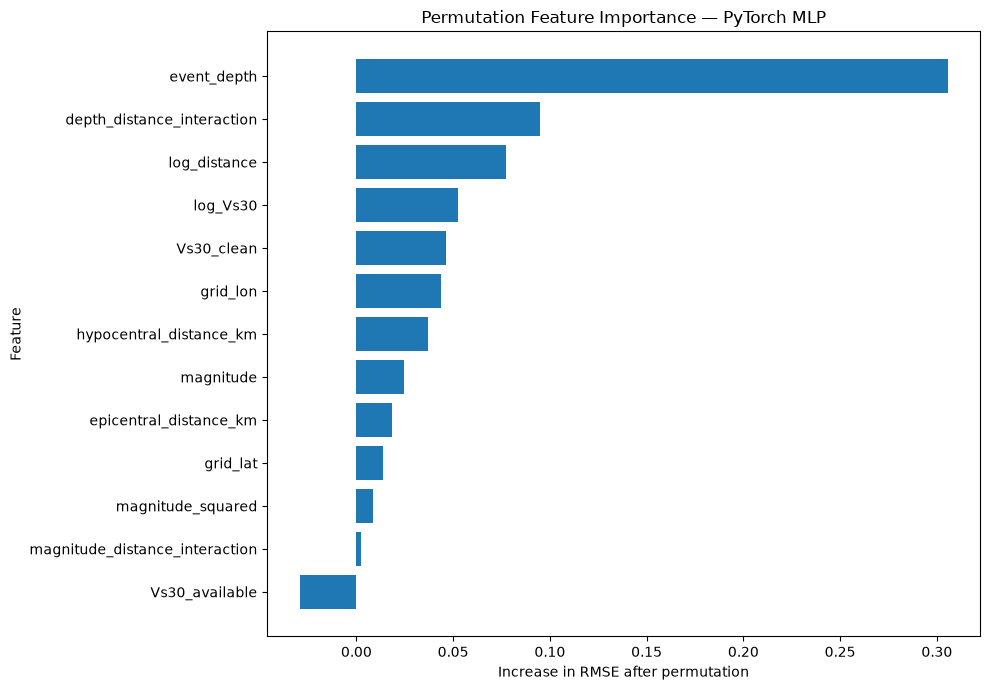

In [67]:
importance_plot_df = (
    permutation_importance_df
    .sort_values(
        "RMSE_Increase",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    importance_plot_df["Feature"],
    importance_plot_df["RMSE_Increase"]
)

plt.xlabel(
    "Increase in RMSE after permutation"
)

plt.ylabel("Feature")

plt.title(
    "Permutation Feature Importance — PyTorch MLP"
)

plt.tight_layout()

plt.show()

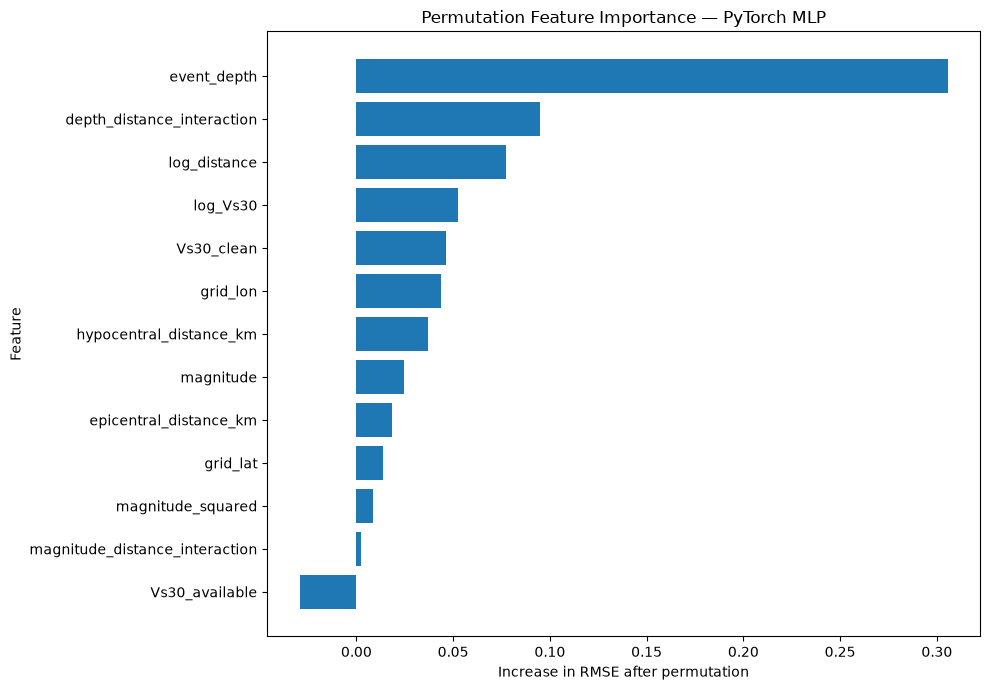

Feature importance saved.


In [68]:
permutation_importance_df.to_csv(
    PROCESSED_DIR /
    "mlp_permutation_feature_importance.csv",
    index=False
)

plt.figure(figsize=(10, 7))

plt.barh(
    importance_plot_df["Feature"],
    importance_plot_df["RMSE_Increase"]
)

plt.xlabel(
    "Increase in RMSE after permutation"
)

plt.ylabel("Feature")

plt.title(
    "Permutation Feature Importance — PyTorch MLP"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "mlp_permutation_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Feature importance saved."
)

In [69]:
# Use a manageable sample for response analysis

response_sample_size = min(
    5000,
    len(X_final_test_scaled)
)

response_indices = rng.choice(
    len(X_final_test_scaled),
    size=response_sample_size,
    replace=False
)

X_response = X_final_test_scaled[
    response_indices
].copy()

print(
    "Response-analysis sample:",
    X_response.shape
)

Response-analysis sample: (5000, 13)


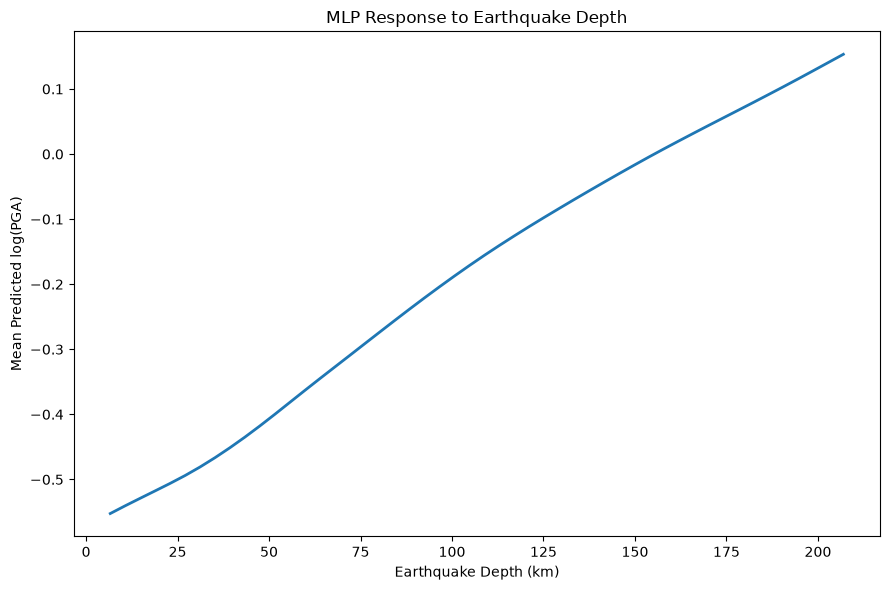

In [70]:
depth_idx = final_features.index(
    "event_depth"
)

depth_values = np.linspace(
    X_final_train["event_depth"].min(),
    X_final_train["event_depth"].max(),
    50
)

depth_predictions = []

for depth_value in depth_values:

    X_temp = X_response.copy()

    depth_scaled = (
        depth_value
        - final_scaler.mean_[depth_idx]
    ) / final_scaler.scale_[depth_idx]

    X_temp[:, depth_idx] = depth_scaled

    X_temp_tensor = torch.tensor(
        X_temp,
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():

        preds = (
            final_model(
                X_temp_tensor
            )
            .cpu()
            .numpy()
            .mean()
        )

    depth_predictions.append(preds)

plt.figure(figsize=(9, 6))

plt.plot(
    depth_values,
    depth_predictions,
    linewidth=2
)

plt.xlabel("Earthquake Depth (km)")
plt.ylabel("Mean Predicted log(PGA)")

plt.title(
    "MLP Response to Earthquake Depth"
)

plt.tight_layout()
plt.show()

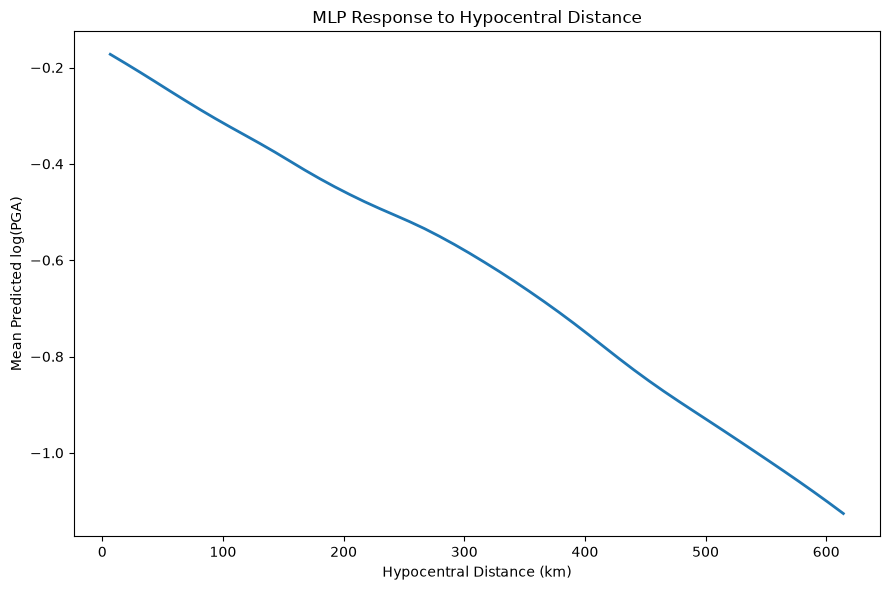

In [71]:
distance_idx = final_features.index(
    "hypocentral_distance_km"
)

distance_values = np.linspace(
    X_final_train["hypocentral_distance_km"].min(),
    X_final_train["hypocentral_distance_km"].max(),
    50
)

distance_predictions = []

for distance_value in distance_values:

    X_temp = X_response.copy()

    distance_scaled = (
        distance_value
        - final_scaler.mean_[distance_idx]
    ) / final_scaler.scale_[distance_idx]

    X_temp[:, distance_idx] = distance_scaled

    X_temp_tensor = torch.tensor(
        X_temp,
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():

        preds = (
            final_model(X_temp_tensor)
            .cpu()
            .numpy()
            .mean()
        )

    distance_predictions.append(preds)


plt.figure(figsize=(9, 6))

plt.plot(
    distance_values,
    distance_predictions,
    linewidth=2
)

plt.xlabel(
    "Hypocentral Distance (km)"
)

plt.ylabel(
    "Mean Predicted log(PGA)"
)

plt.title(
    "MLP Response to Hypocentral Distance"
)

plt.tight_layout()

plt.show()

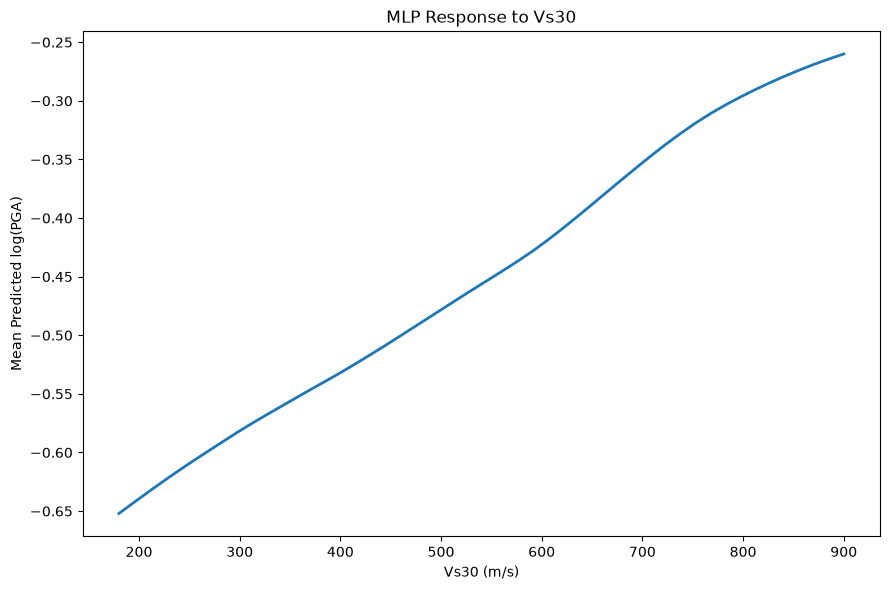

In [72]:
vs30_idx = final_features.index(
    "Vs30_clean"
)

vs30_values = np.linspace(
    X_final_train["Vs30_clean"].min(),
    X_final_train["Vs30_clean"].max(),
    50
)

vs30_predictions = []

for vs30_value in vs30_values:

    X_temp = X_response.copy()

    vs30_scaled = (
        vs30_value
        - final_scaler.mean_[vs30_idx]
    ) / final_scaler.scale_[vs30_idx]

    X_temp[:, vs30_idx] = vs30_scaled

    X_temp_tensor = torch.tensor(
        X_temp,
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():

        preds = (
            final_model(X_temp_tensor)
            .cpu()
            .numpy()
            .mean()
        )

    vs30_predictions.append(preds)


plt.figure(figsize=(9, 6))

plt.plot(
    vs30_values,
    vs30_predictions,
    linewidth=2
)

plt.xlabel(
    "Vs30 (m/s)"
)

plt.ylabel(
    "Mean Predicted log(PGA)"
)

plt.title(
    "MLP Response to Vs30"
)

plt.tight_layout()

plt.show()

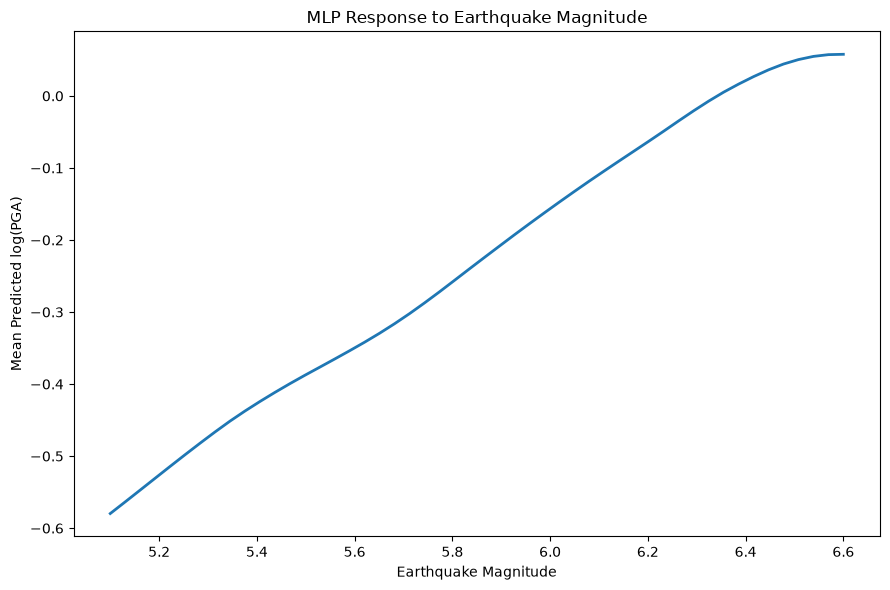

In [73]:
magnitude_idx = final_features.index(
    "magnitude"
)

magnitude_values = np.linspace(
    X_final_train["magnitude"].min(),
    X_final_train["magnitude"].max(),
    50
)

magnitude_predictions = []

for magnitude_value in magnitude_values:

    X_temp = X_response.copy()

    magnitude_scaled = (
        magnitude_value
        - final_scaler.mean_[magnitude_idx]
    ) / final_scaler.scale_[magnitude_idx]

    X_temp[:, magnitude_idx] = magnitude_scaled

    X_temp_tensor = torch.tensor(
        X_temp,
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():

        preds = (
            final_model(X_temp_tensor)
            .cpu()
            .numpy()
            .mean()
        )

    magnitude_predictions.append(preds)


plt.figure(figsize=(9, 6))

plt.plot(
    magnitude_values,
    magnitude_predictions,
    linewidth=2
)

plt.xlabel(
    "Earthquake Magnitude"
)

plt.ylabel(
    "Mean Predicted log(PGA)"
)

plt.title(
    "MLP Response to Earthquake Magnitude"
)

plt.tight_layout()

plt.show()

In [74]:
response_results = {
    "depth": pd.DataFrame({
        "value": depth_values,
        "predicted_log_PGA": depth_predictions
    }),

    "hypocentral_distance": pd.DataFrame({
        "value": distance_values,
        "predicted_log_PGA": distance_predictions
    }),

    "Vs30": pd.DataFrame({
        "value": vs30_values,
        "predicted_log_PGA": vs30_predictions
    }),

    "magnitude": pd.DataFrame({
        "value": magnitude_values,
        "predicted_log_PGA": magnitude_predictions
    })
}

for name, df in response_results.items():

    df.to_csv(
        PROCESSED_DIR /
        f"mlp_response_{name}.csv",
        index=False
    )

print(
    "Response curves saved."
)

Response curves saved.


In [75]:
response_summary = pd.DataFrame({
    "Feature": [
        "event_depth",
        "hypocentral_distance_km",
        "Vs30_clean",
        "magnitude"
    ],
    "Prediction_at_Low": [
        depth_predictions[0],
        distance_predictions[0],
        vs30_predictions[0],
        magnitude_predictions[0]
    ],
    "Prediction_at_High": [
        depth_predictions[-1],
        distance_predictions[-1],
        vs30_predictions[-1],
        magnitude_predictions[-1]
    ]
})

response_summary["Change"] = (
    response_summary["Prediction_at_High"]
    -
    response_summary["Prediction_at_Low"]
)

display(response_summary)

,Feature,Prediction_at_Low,Prediction_at_High,Change
0,event_depth,-0.552371,0.153282,0.705653
1,hypocentral_distance_km,-0.172537,-1.126029,-0.953492
2,Vs30_clean,-0.652061,-0.260029,0.392032
3,magnitude,-0.579684,0.057771,0.637455


In [76]:
final_project_summary = pd.DataFrame({
    "Evaluation": [
        "Grouped 5-Fold CV",
        "Validation — 6 unseen earthquakes",
        "Final Test — 6 completely unseen earthquakes"
    ],
    "RMSE": [
        0.212796,
        validation_rmse,
        test_rmse
    ],
    "MAE": [
        0.177651,
        validation_mae,
        test_mae
    ],
    "R2": [
        0.801543,
        validation_r2,
        test_r2
    ]
})

display(final_project_summary)

,Evaluation,RMSE,MAE,R2
0,Grouped 5-Fold CV,0.212796,0.177651,0.801543
1,Validation — 6 unseen earthquakes,0.153184,0.129661,0.952719
2,Final Test — 6 completely unseen earthquakes,0.311307,0.280031,0.609882


In [77]:
final_project_summary.to_csv(
    PROCESSED_DIR /
    "final_project_summary.csv",
    index=False
)

print(
    "Final project summary saved."
)

Final project summary saved.


In [78]:
response_summary.to_csv(
    PROCESSED_DIR /
    "mlp_response_summary.csv",
    index=False
)

print(
    "Interpretability results saved."
)

Interpretability results saved.


In [79]:
from pathlib import Path

PROJECT_DIR = Path(
    r"C:\Documents\Earthquake_ML_DL"
)

DIRECTORIES = [
    PROJECT_DIR / "notebooks",
    PROJECT_DIR / "src",
    PROJECT_DIR / "models",
    PROJECT_DIR / "figures",
    PROJECT_DIR / "reports"
]

for directory in DIRECTORIES:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("Project structure verified:")
for directory in DIRECTORIES:
    print("✓", directory)

Project structure verified:
✓ C:\Documents\Earthquake_ML_DL\notebooks
✓ C:\Documents\Earthquake_ML_DL\src
✓ C:\Documents\Earthquake_ML_DL\models
✓ C:\Documents\Earthquake_ML_DL\figures
✓ C:\Documents\Earthquake_ML_DL\reports


In [80]:
master_results = {
    "dataset": {
        "total_observations": 2873369,
        "train_observations": 2092176,
        "validation_observations": 468857,
        "test_observations": 312336,
        "train_events": 28,
        "validation_events": 6,
        "test_events": 6
    },

    "best_classical_model": {
        "model": "Elastic Net",
        "grouped_cv_rmse": 0.247352,
        "grouped_cv_mae": 0.207955,
        "grouped_cv_r2": 0.731666
    },

    "best_deep_learning_model": {
        "model": "PyTorch MLP",
        "grouped_cv_rmse": 0.212796,
        "grouped_cv_mae": 0.177651,
        "grouped_cv_r2": 0.801543
    },

    "final_validation": {
        "rmse": validation_rmse,
        "mae": validation_mae,
        "r2": validation_r2
    },

    "final_unseen_test": {
        "rmse": test_rmse,
        "mae": test_mae,
        "r2": test_r2
    }
}

print(master_results)

{'dataset': {'total_observations': 2873369, 'train_observations': 2092176, 'validation_observations': 468857, 'test_observations': 312336, 'train_events': 28, 'validation_events': 6, 'test_events': 6}, 'best_classical_model': {'model': 'Elastic Net', 'grouped_cv_rmse': 0.247352, 'grouped_cv_mae': 0.207955, 'grouped_cv_r2': 0.731666}, 'best_deep_learning_model': {'model': 'PyTorch MLP', 'grouped_cv_rmse': 0.212796, 'grouped_cv_mae': 0.177651, 'grouped_cv_r2': 0.801543}, 'final_validation': {'rmse': np.float64(0.1531840265724236), 'mae': 0.12966084745751288, 'r2': 0.9527188453501231}, 'final_unseen_test': {'rmse': np.float64(0.3113074285859869), 'mae': 0.2800305410551364, 'r2': 0.6098822876179164}}


In [81]:
import json

with open(
    PROJECT_DIR / "reports" / "master_results.json",
    "w"
) as f:

    json.dump(
        master_results,
        f,
        indent=4
    )

print(
    "Master results saved."
)

Master results saved.


In [82]:
readme_results = f"""
FINAL RESULTS
=============

Dataset
-------
Total observations: 2,873,369
Training observations: 2,092,176
Validation observations: 468,857
Test observations: 312,336

Earthquake-level split
----------------------
Training earthquakes: 28
Validation earthquakes: 6
Test earthquakes: 6

Grouped 5-Fold Cross-Validation
--------------------------------
Elastic Net:
    RMSE = 0.247352
    MAE  = 0.207955
    R²   = 0.731666

PyTorch MLP:
    RMSE = 0.212796
    MAE  = 0.177651
    R²   = 0.801543

Final Validation
----------------
RMSE = {validation_rmse:.6f}
MAE  = {validation_mae:.6f}
R²   = {validation_r2:.6f}

Final Unseen-Earthquake Test
----------------------------
RMSE = {test_rmse:.6f}
MAE  = {test_mae:.6f}
R²   = {test_r2:.6f}
"""

print(readme_results)

with open(
    PROJECT_DIR / "reports" / "results_summary.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(readme_results)


FINAL RESULTS

Dataset
-------
Total observations: 2,873,369
Training observations: 2,092,176
Validation observations: 468,857
Test observations: 312,336

Earthquake-level split
----------------------
Training earthquakes: 28
Validation earthquakes: 6
Test earthquakes: 6

Grouped 5-Fold Cross-Validation
--------------------------------
Elastic Net:
    RMSE = 0.247352
    MAE  = 0.207955
    R²   = 0.731666

PyTorch MLP:
    RMSE = 0.212796
    MAE  = 0.177651
    R²   = 0.801543

Final Validation
----------------
RMSE = 0.153184
MAE  = 0.129661
R²   = 0.952719

Final Unseen-Earthquake Test
----------------------------
RMSE = 0.311307
MAE  = 0.280031
R²   = 0.609882



In [83]:
figure_files = sorted(
    FIGURES_DIR.glob("*")
)

print(
    f"Number of figures: {len(figure_files)}"
)

for file in figure_files:
    print("✓", file.name)

Number of figures: 9
✓ mlp_permutation_feature_importance.png
✓ observed_vs_predicted_log_pga.png
✓ residual_vs_depth.png
✓ residual_vs_distance.png
✓ residual_vs_magnitude.png
✓ residual_vs_vs30.png
✓ spatial_observed_log_pga.png
✓ spatial_predicted_log_pga.png
✓ spatial_residual_map.png


In [84]:
processed_files = sorted(
    PROCESSED_DIR.glob("*")
)

print(
    f"Processed files: {len(processed_files)}"
)

for file in processed_files:
    print("✓", file.name)

Processed files: 40
✓ absolute_error_correlations.csv
✓ balanced_eda_sample.csv
✓ distance_attenuation_summary.csv
✓ elastic_net_cv_summary.csv
✓ elastic_net_grouped_cv_results.csv
✓ elastic_net_same_sample_cv.csv
✓ event_level_summary.csv
✓ event_split.csv
✓ feature_config.csv
✓ final_event_residual_analysis.csv
✓ final_model_comparison.csv
✓ final_model_results_table.csv
✓ final_project_summary.csv
✓ final_test_event_residual_summary.csv
✓ final_test_metrics.csv
✓ final_test_per_event_results.csv
✓ final_test_predictions.csv
✓ final_test_residuals.csv
✓ final_test_vs30_residual_summary.csv
✓ final_validation_result.csv
✓ grouped_cv_model_comparison.csv
✓ lightgbm_grouped_cv_results.csv
✓ ml_baseline_results.csv
✓ mlp_development_result.csv
✓ mlp_grouped_cv_results.csv
✓ mlp_grouped_cv_summary.csv
✓ mlp_permutation_feature_importance.csv
✓ mlp_response_depth.csv
✓ mlp_response_hypocentral_distance.csv
✓ mlp_response_magnitude.csv
✓ mlp_response_summary.csv
✓ mlp_response_Vs30.csv
✓ ph

In [85]:
model_files = sorted(
    (PROJECT_DIR / "models").glob("*")
)

print(
    "Model files:"
)

for file in model_files:
    print(
        "✓",
        file.name,
        f"({file.stat().st_size / 1024:.1f} KB)"
    )

Model files:
✓ pga_imputer.pkl (1.1 KB)
✓ pga_mlp_development.pt (21.8 KB)
✓ pga_scaler.pkl (0.9 KB)


In [86]:
original_total = 2912739

final_train = len(train_data)
final_val = len(val_data)
final_test = len(test_data)

final_total = (
    final_train
    + final_val
    + final_test
)

removed = original_total - final_total

print("Original observations:", original_total)
print("Final modeling observations:", final_total)
print("Removed observations:", removed)

print("\nFinal split:")
print("Train:", final_train)
print("Validation:", final_val)
print("Test:", final_test)

print(
    "\nPercentage retained:",
    round(final_total / original_total * 100, 3),
    "%"
)

print(
    "Percentage removed:",
    round(removed / original_total * 100, 3),
    "%"
)

Original observations: 2912739
Final modeling observations: 2873369
Removed observations: 39370

Final split:
Train: 2092176
Validation: 468857
Test: 312336

Percentage retained: 98.648 %
Percentage removed: 1.352 %


In [87]:
balanced_eda = pd.read_csv(
    PROCESSED_DIR / "balanced_eda_sample.csv"
)

print(
    "Balanced EDA sample:",
    balanced_eda.shape
)

print(
    "Final train + validation + test:",
    final_total
)

Balanced EDA sample: (200000, 15)
Final train + validation + test: 2873369


In [88]:
data_audit = pd.DataFrame({
    "Stage": [
        "Original observations",
        "Final training set",
        "Final validation set",
        "Final test set",
        "Final modeling dataset",
        "Removed during processing"
    ],
    "Observations": [
        original_total,
        final_train,
        final_val,
        final_test,
        final_total,
        removed
    ]
})

display(data_audit)

data_audit.to_csv(
    PROCESSED_DIR / "data_pipeline_audit.csv",
    index=False
)

,Stage,Observations
0,Original observations,2912739
1,Final training set,2092176
2,Final validation set,468857
3,Final test set,312336
4,Final modeling dataset,2873369
5,Removed during processing,39370


In [89]:
methodology_summary = """
EARTHQUAKE GROUND-MOTION PREDICTION — METHODOLOGY

1. DATA
-------
USGS ShakeMap ground-motion observations were assembled for 40 earthquake
events. The final modeling dataset contains approximately 2.87 million
observations.

Target:
    log(PGA)

The dataset contains earthquake source parameters, observation/grid
coordinates, distance measures, and site-condition information including
Vs30.

2. DATA SPLITTING
-----------------
The dataset was split at the earthquake/event level rather than randomly
at the observation level.

Training:
    28 earthquakes

Validation:
    6 earthquakes

Final test:
    6 completely unseen earthquakes

This prevents observations from the same earthquake appearing in both
training and evaluation sets.

3. SITE CONDITIONS
------------------
Global USGS Vs30 data were integrated with the ShakeMap observations.

Vs30 values were cleaned and transformed using:
    - Vs30_clean
    - log_Vs30
    - Vs30 availability indicator

4. FEATURE ENGINEERING
----------------------
Features include:

    - earthquake magnitude
    - earthquake depth
    - epicentral distance
    - hypocentral distance
    - log distance
    - magnitude squared
    - magnitude-distance interaction
    - depth-distance interaction
    - Vs30
    - log Vs30
    - geographic coordinates

5. MODELS
---------
Classical machine-learning models:
    - Linear Regression
    - Ridge Regression
    - Elastic Net
    - Random Forest
    - LightGBM
    - XGBoost

Deep-learning model:
    - PyTorch multilayer perceptron (MLP)

6. VALIDATION
-------------
Earthquake-grouped 5-fold cross-validation was used during model
development to evaluate generalization to unseen earthquake events.

7. FINAL EVALUATION
-------------------
After model development, the final MLP was evaluated on six earthquakes
that were kept completely separate from model development.

8. INTERPRETABILITY
-------------------
Permutation feature importance and model-response analysis were used to
investigate the role of earthquake depth, distance, magnitude, Vs30,
and geographic variables.
"""

print(methodology_summary)

with open(
    PROJECT_DIR / "reports" / "methodology_summary.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(methodology_summary)

print("\nMethodology summary saved.")


EARTHQUAKE GROUND-MOTION PREDICTION — METHODOLOGY

1. DATA
-------
USGS ShakeMap ground-motion observations were assembled for 40 earthquake
events. The final modeling dataset contains approximately 2.87 million
observations.

Target:
    log(PGA)

The dataset contains earthquake source parameters, observation/grid
coordinates, distance measures, and site-condition information including
Vs30.

2. DATA SPLITTING
-----------------
The dataset was split at the earthquake/event level rather than randomly
at the observation level.

Training:
    28 earthquakes

Validation:
    6 earthquakes

Final test:
    6 completely unseen earthquakes

This prevents observations from the same earthquake appearing in both
training and evaluation sets.

3. SITE CONDITIONS
------------------
Global USGS Vs30 data were integrated with the ShakeMap observations.

Vs30 values were cleaned and transformed using:
    - Vs30_clean
    - log_Vs30
    - Vs30 availability indicator

4. FEATURE ENGINEERING
--------

In [90]:
scientific_conclusions = """
SCIENTIFIC CONCLUSIONS
======================

1. MODEL PERFORMANCE
--------------------
The PyTorch MLP achieved the strongest performance among the evaluated
models during earthquake-grouped cross-validation.

Grouped 5-fold CV:
    RMSE = 0.2128
    MAE  = 0.1777
    R²   = 0.8015

The best classical model, Elastic Net, achieved:

    RMSE = 0.2474
    MAE  = 0.2080
    R²   = 0.7317

2. UNSEEN-EARTHQUAKE GENERALIZATION
------------------------------------
On six completely unseen earthquakes, the final MLP achieved:

    RMSE = 0.3113
    MAE  = 0.2800
    R²   = 0.6099

Performance was strongly event-dependent. One test earthquake achieved
R² close to 0.95, while several other events had negative event-level R².

This indicates that generalization between earthquakes is substantially
more difficult than prediction within the development distribution.

3. EVENT-LEVEL BIAS
-------------------
The residual analysis showed systematic event-level offsets.

Some earthquakes were consistently overpredicted, while others were
consistently underpredicted.

This suggests that source- or path-specific effects not represented by
the current feature set contribute significantly to event-to-event
variability.

4. IMPORTANT FEATURES
---------------------
Permutation feature importance identified earthquake depth as the most
influential feature, followed by the depth-distance interaction, log
distance, and Vs30-related variables.

This indicates that source geometry, propagation distance, and site
conditions all contribute substantially to model predictions.

5. PHYSICAL RESPONSE
--------------------
The model-response analysis showed:

    - predicted ground motion decreases with increasing hypocentral
      distance;
    - predicted ground motion increases with magnitude;
    - predictions are sensitive to Vs30;
    - predictions are strongly sensitive to earthquake depth.

These relationships are interpreted as learned model sensitivities rather
than causal effects.

6. LIMITATIONS
--------------
The main limitation is event-to-event generalization.

The test results demonstrate that a model can perform strongly under
grouped cross-validation while still exhibiting substantial performance
variation on completely unseen earthquakes.

Additional source, path, regional, or site-specific variables may be
required to improve robustness.

7. OVERALL CONCLUSION
---------------------
The project demonstrates that deep learning can learn meaningful
relationships between earthquake source characteristics, propagation
geometry, site conditions, and observed ground motion across a
multi-million-observation dataset.

The results also demonstrate the importance of earthquake-level
validation when assessing generalization of ground-motion prediction
models.
"""

print(scientific_conclusions)

with open(
    PROJECT_DIR / "reports" / "scientific_conclusions.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(scientific_conclusions)

print("\nScientific conclusions saved.")


SCIENTIFIC CONCLUSIONS

1. MODEL PERFORMANCE
--------------------
The PyTorch MLP achieved the strongest performance among the evaluated
models during earthquake-grouped cross-validation.

Grouped 5-fold CV:
    RMSE = 0.2128
    MAE  = 0.1777
    R²   = 0.8015

The best classical model, Elastic Net, achieved:

    RMSE = 0.2474
    MAE  = 0.2080
    R²   = 0.7317

2. UNSEEN-EARTHQUAKE GENERALIZATION
------------------------------------
On six completely unseen earthquakes, the final MLP achieved:

    RMSE = 0.3113
    MAE  = 0.2800
    R²   = 0.6099

Performance was strongly event-dependent. One test earthquake achieved
R² close to 0.95, while several other events had negative event-level R².

This indicates that generalization between earthquakes is substantially
more difficult than prediction within the development distribution.

3. EVENT-LEVEL BIAS
-------------------
The residual analysis showed systematic event-level offsets.

Some earthquakes were consistently overpredicted, w

In [91]:
model_comparison_report = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Elastic Net",
        "Physical Elastic Net",
        "LightGBM",
        "Random Forest",
        "XGBoost",
        "PyTorch MLP"
    ],
    "Grouped_CV_RMSE": [
        0.185690,
        0.185682,
        0.247352,
        0.299878,
        0.316944,
        np.nan,
        np.nan,
        0.212796
    ],
    "Grouped_CV_MAE": [
        0.152487,
        0.152484,
        0.207955,
        0.235310,
        0.238501,
        np.nan,
        np.nan,
        0.177651
    ],
    "Grouped_CV_R2": [
        0.930524,
        0.930529,
        0.731666,
        0.602133,
        0.557865,
        np.nan,
        np.nan,
        0.801543
    ]
})

display(model_comparison_report)

,Model,Grouped_CV_RMSE,Grouped_CV_MAE,Grouped_CV_R2
0,Linear Regression,0.185690,0.152487,0.930524
1,Ridge Regression,0.185682,0.152484,0.930529
2,Elastic Net,0.247352,0.207955,0.731666
3,Physical Elastic Net,0.299878,0.235310,0.602133
4,LightGBM,0.316944,0.238501,0.557865
5,Random Forest,NaN,NaN,NaN
6,XGBoost,NaN,NaN,NaN
7,PyTorch MLP,0.212796,0.177651,0.801543


In [92]:
model_comparison_report.to_csv(
    PROJECT_DIR / "reports" /
    "model_comparison_report.csv",
    index=False
)

print(
    "Model comparison report saved."
)

Model comparison report saved.


In [93]:
requirements = """numpy
pandas
scikit-learn
matplotlib
seaborn
scipy
joblib
torch
lightgbm
xgboost
lasio
jupyter
openpyxl
"""

requirements_path = (
    PROJECT_DIR / "requirements.txt"
)

with open(
    requirements_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(requirements)

print(
    "Created:",
    requirements_path
)

print("\nContents:\n")
print(requirements)

Created: C:\Documents\Earthquake_ML_DL\requirements.txt

Contents:

numpy
pandas
scikit-learn
matplotlib
seaborn
scipy
joblib
torch
lightgbm
xgboost
lasio
jupyter
openpyxl



In [94]:
gitignore = """# Python
__pycache__/
*.py[cod]
*.pyo

# Jupyter
.ipynb_checkpoints/

# Virtual environments
.venv/
venv/
env/

# Large/raw data
data/raw/
data/processed/*.csv

# Model artifacts
models/*.pt
models/*.pkl

# Local files
*.log
.DS_Store
Thumbs.db

# IDE
.vscode/
.idea/

# Temporary files
*.tmp
*.temp
"""

gitignore_path = (
    PROJECT_DIR / ".gitignore"
)

with open(
    gitignore_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(gitignore)

print(
    "Created:",
    gitignore_path
)

Created: C:\Documents\Earthquake_ML_DL\.gitignore


In [95]:
src_files = {
    "src/__init__.py": "",
    
    "src/features.py": '''"""
Feature engineering utilities for earthquake ground-motion prediction.
"""

def get_final_features():
    return [
        "magnitude",
        "event_depth",
        "epicentral_distance_km",
        "hypocentral_distance_km",
        "log_distance",
        "magnitude_squared",
        "magnitude_distance_interaction",
        "depth_distance_interaction",
        "Vs30_clean",
        "log_Vs30",
        "Vs30_available",
        "grid_lat",
        "grid_lon"
    ]
''',

    "src/evaluation.py": '''"""
Evaluation utilities for earthquake ground-motion models.
"""

import numpy as np
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


def regression_metrics(y_true, y_pred):
    """Calculate RMSE, MAE and R²."""
    
    return {
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        ),
        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),
        "R2": r2_score(
            y_true,
            y_pred
        )
    }
''',

    "src/models.py": '''"""
Model definitions for earthquake ground-motion prediction.
"""

import torch
import torch.nn as nn


class PGA_MLP(nn.Module):
    """Multilayer perceptron for log-PGA prediction."""

    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),

            nn.BatchNorm1d(64),
            nn.Dropout(0.15),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.BatchNorm1d(32),
            nn.Dropout(0.10),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)
'''
}

for relative_path, content in src_files.items():

    file_path = (
        PROJECT_DIR / relative_path
    )

    file_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    with open(
        file_path,
        "w",
        encoding="utf-8"
    ) as f:
        f.write(content)

    print("✓", relative_path)

✓ src/__init__.py
✓ src/features.py
✓ src/evaluation.py
✓ src/models.py


In [96]:
notebook_plan = pd.DataFrame({
    "Notebook": [
        "01_data_acquisition.ipynb",
        "02_shakemap_processing.ipynb",
        "03_data_cleaning_eda.ipynb",
        "04_feature_engineering.ipynb",
        "05_vs30_spatial_analysis.ipynb",
        "06_ml_baselines.ipynb",
        "07_final_model_evaluation.ipynb",
        "08_interpretability.ipynb"
    ],
    "Purpose": [
        "Acquire and document earthquake/ShakeMap data",
        "Process ground-motion observations and earthquake metadata",
        "Quality control and exploratory data analysis",
        "Construct physically motivated ML features",
        "Integrate Vs30 and analyze spatial/site characteristics",
        "Classical ML, grouped CV and baseline comparison",
        "Final MLP training, validation and untouched test evaluation",
        "Residual analysis, spatial diagnostics and model interpretation"
    ]
})

display(notebook_plan)

notebook_plan.to_csv(
    PROJECT_DIR / "reports" /
    "notebook_plan.csv",
    index=False
)

,Notebook,Purpose
0,01_data_acquisition.ipynb,Acquire and document earthquake/ShakeMap data
1,02_shakemap_processing.ipynb,Process ground-motion observations and earthqu...
2,03_data_cleaning_eda.ipynb,Quality control and exploratory data analysis
3,04_feature_engineering.ipynb,Construct physically motivated ML features
4,05_vs30_spatial_analysis.ipynb,Integrate Vs30 and analyze spatial/site charac...
5,06_ml_baselines.ipynb,"Classical ML, grouped CV and baseline comparison"
6,07_final_model_evaluation.ipynb,"Final MLP training, validation and untouched t..."
7,08_interpretability.ipynb,"Residual analysis, spatial diagnostics and mod..."


In [97]:
project_metadata = {
    "project_name": "Earthquake Ground-Motion Prediction with Machine Learning and Deep Learning",
    "target": "log(PGA)",
    "dataset_observations": 2873369,
    "earthquakes": 40,
    "training_earthquakes": 28,
    "validation_earthquakes": 6,
    "test_earthquakes": 6,
    "best_model": "PyTorch MLP",
    "grouped_cv_rmse": 0.212796,
    "grouped_cv_mae": 0.177651,
    "grouped_cv_r2": 0.801543,
    "final_test_rmse": 0.311307,
    "final_test_mae": 0.280031,
    "final_test_r2": 0.609882,
    "interpretability": [
        "Permutation feature importance",
        "Model response analysis",
        "Residual analysis",
        "Spatial residual analysis"
    ]
}

with open(
    PROJECT_DIR / "reports" /
    "project_metadata.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        project_metadata,
        f,
        indent=4
    )

print("Project metadata saved.")

Project metadata saved.


In [100]:
from pathlib import Path

README_PATH = PROJECT_DIR / "README.md"

lines = [
    "# Earthquake Ground-Motion Prediction Using Machine Learning and Deep Learning",
    "",
    "A large-scale machine-learning framework for predicting earthquake ground motion (PGA) using earthquake source characteristics, propagation geometry, geographic location, and near-surface site conditions.",
    "",
    "## Project Overview",
    "",
    "This project develops and evaluates machine-learning and deep-learning models for predicting logarithmic Peak Ground Acceleration (log-PGA) using approximately 2.87 million observations from 40 earthquakes.",
    "",
    "The central objective is to evaluate generalization to earthquakes that were completely unseen during model development.",
    "",
    "## Key Results",
    "",
    "| Model | RMSE | MAE | R2 |",
    "|---|---:|---:|---:|",
    "| Elastic Net | 0.2474 | 0.2080 | 0.7317 |",
    "| Physical Elastic Net | 0.2999 | 0.2353 | 0.6021 |",
    "| LightGBM | 0.3169 | 0.2385 | 0.5579 |",
    "| **PyTorch MLP** | **0.2128** | **0.1777** | **0.8015** |",
    "",
    "The MLP achieved the strongest grouped cross-validation performance.",
    "",
    "## Final Unseen-Earthquake Evaluation",
    "",
    "The final MLP was evaluated on six completely unseen earthquakes.",
    "",
    "| Metric | Result |",
    "|---|---:|",
    "| RMSE | **0.3113** |",
    "| MAE | **0.2800** |",
    "| R2 | **0.6099** |",
    "",
    "The difference between grouped cross-validation and final test performance demonstrates that earthquake-to-earthquake generalization is substantially more difficult than within-development validation.",
    "",
    "## Dataset",
    "",
    "| Split | Observations | Earthquakes |",
    "|---|---:|---:|",
    "| Training | 2,092,176 | 28 |",
    "| Validation | 468,857 | 6 |",
    "| Test | 312,336 | 6 |",
    "| **Total** | **2,873,369** | **40** |",
    "",
    "## Target Variable",
    "",
    "The prediction target is log(PGA).",
    "",
    "## Feature Engineering",
    "",
    "The final model uses physically motivated earthquake and site features:",
    "",
    "- Earthquake magnitude",
    "- Earthquake depth",
    "- Epicentral distance",
    "- Hypocentral distance",
    "- Log distance",
    "- Magnitude squared",
    "- Magnitude-distance interaction",
    "- Depth-distance interaction",
    "- Vs30",
    "- Log Vs30",
    "- Vs30 availability",
    "- Grid latitude",
    "- Grid longitude",
    "",
    "## Models Evaluated",
    "",
    "### Classical Machine Learning",
    "",
    "- Linear Regression",
    "- Ridge Regression",
    "- Elastic Net",
    "- Random Forest",
    "- LightGBM",
    "- XGBoost",
    "",
    "### Deep Learning",
    "",
    "A PyTorch multilayer perceptron was developed using fully connected layers, ReLU activations, batch normalization, dropout, AdamW optimization, Huber loss, and early stopping.",
    "",
    "## Validation Strategy",
    "",
    "A major methodological component is earthquake-level grouped validation.",
    "",
    "Entire earthquakes are kept together rather than randomly splitting individual observations. This prevents observations from the same earthquake appearing in both training and evaluation sets.",
    "",
    "The final split contains 28 training earthquakes, 6 validation earthquakes, and 6 completely unseen test earthquakes.",
    "",
    "## Model Interpretability",
    "",
    "Permutation feature importance identified the following major contributors:",
    "",
    "| Rank | Feature | RMSE Increase |",
    "|---:|---|---:|",
    "| 1 | **event_depth** | **0.3056** |",
    "| 2 | depth_distance_interaction | 0.0950 |",
    "| 3 | log_distance | 0.0774 |",
    "| 4 | log_Vs30 | 0.0523 |",
    "| 5 | Vs30_clean | 0.0465 |",
    "| 6 | grid_lon | 0.0437 |",
    "| 7 | hypocentral_distance_km | 0.0370 |",
    "| 8 | magnitude | 0.0249 |",
    "",
    "The model therefore relies strongly on source depth, propagation geometry, and site conditions.",
    "",
    "## Physical Response Analysis",
    "",
    "The trained MLP showed strong sensitivity to earthquake depth, magnitude, hypocentral distance, and Vs30.",
    "",
    "These response curves represent model sensitivities rather than causal relationships.",
    "",
    "## Residual Analysis",
    "",
    "The final test predictions were analyzed using residual distributions, residual-vs-distance plots, residual-vs-depth plots, residual-vs-magnitude plots, residual-vs-Vs30 plots, event-level residual statistics, and spatial residual maps.",
    "",
    "A major finding is that model performance varies considerably between individual unseen earthquakes.",
    "",
    "## Visualizations",
    "",
    "The project contains nine major figures:",
    "",
    "- observed_vs_predicted_log_pga.png",
    "- residual_vs_depth.png",
    "- residual_vs_distance.png",
    "- residual_vs_magnitude.png",
    "- residual_vs_vs30.png",
    "- spatial_observed_log_pga.png",
    "- spatial_predicted_log_pga.png",
    "- spatial_residual_map.png",
    "- mlp_permutation_feature_importance.png",
    "",
    "## Limitations",
    "",
    "The main limitation is event-to-event generalization.",
    "",
    "Although the MLP achieved strong grouped cross-validation performance, final evaluation on completely unseen earthquakes was lower.",
    "",
    "This indicates that earthquake ground motion contains event-specific variability that is not fully represented by the current feature set.",
    "",
    "Potential future improvements include additional source parameters, regional geological information, more detailed site characterization, path and attenuation variables, fault/source mechanism information, more independent earthquakes, and uncertainty-aware prediction.",
    "",
    "## Scientific Contribution",
    "",
    "This project combines seismological observations, geological site characterization, physical feature engineering, machine learning, deep learning, earthquake-level validation, and model interpretation.",
    "",
    "A key methodological strength is explicit evaluation on completely unseen earthquake events.",
    "",
    "## Technologies",
    "",
    "- Python",
    "- NumPy",
    "- Pandas",
    "- Scikit-learn",
    "- PyTorch",
    "- LightGBM",
    "- XGBoost",
    "- Matplotlib",
    "- SciPy",
    "- Joblib",
    "- Jupyter",
    "",
    "## Author",
    "",
    "**Utkarsh**",
    "",
    "Geology & Geophysics | Machine Learning | Data Science | Earthquake & Geoscience Applications"
]

README_PATH.write_text("\n".join(lines), encoding="utf-8")

print("README successfully created.")
print("Path:", README_PATH)
print("Size:", README_PATH.stat().st_size, "bytes")

README successfully created.
Path: C:\Documents\Earthquake_ML_DL\README.md
Size: 5500 bytes


In [101]:
print("README exists:", README_PATH.exists())

text = README_PATH.read_text(encoding="utf-8")

print("Characters:", len(text))
print("\nFirst 1000 characters:\n")
print(text[:1000])

README exists: True
Characters: 5336

First 1000 characters:

# Earthquake Ground-Motion Prediction Using Machine Learning and Deep Learning

A large-scale machine-learning framework for predicting earthquake ground motion (PGA) using earthquake source characteristics, propagation geometry, geographic location, and near-surface site conditions.

## Project Overview

This project develops and evaluates machine-learning and deep-learning models for predicting logarithmic Peak Ground Acceleration (log-PGA) using approximately 2.87 million observations from 40 earthquakes.

The central objective is to evaluate generalization to earthquakes that were completely unseen during model development.

## Key Results

| Model | RMSE | MAE | R2 |
|---|---:|---:|---:|
| Elastic Net | 0.2474 | 0.2080 | 0.7317 |
| Physical Elastic Net | 0.2999 | 0.2353 | 0.6021 |
| LightGBM | 0.3169 | 0.2385 | 0.5579 |
| **PyTorch MLP** | **0.2128** | **0.1777** | **0.8015** |

The MLP achieved the strongest grouped cr

In [102]:
from pathlib import Path

print("=" * 60)
print("PROJECT STRUCTURE")
print("=" * 60)

for path in sorted(PROJECT_DIR.rglob("*")):
    if path.is_file():
        try:
            relative = path.relative_to(PROJECT_DIR)
            print(relative)
        except ValueError:
            pass

PROJECT STRUCTURE
.gitignore
data\interim\earthquake_ground_motion_integrated.csv
data\interim\earthquake_ground_motion_vs30.csv
data\processed\absolute_error_correlations.csv
data\processed\balanced_eda_sample.csv
data\processed\data_pipeline_audit.csv
data\processed\distance_attenuation_summary.csv
data\processed\elastic_net_cv_summary.csv
data\processed\elastic_net_grouped_cv_results.csv
data\processed\elastic_net_same_sample_cv.csv
data\processed\event_level_summary.csv
data\processed\event_split.csv
data\processed\feature_config.csv
data\processed\final_event_residual_analysis.csv
data\processed\final_model_comparison.csv
data\processed\final_model_results_table.csv
data\processed\final_project_summary.csv
data\processed\final_test_event_residual_summary.csv
data\processed\final_test_metrics.csv
data\processed\final_test_per_event_results.csv
data\processed\final_test_predictions.csv
data\processed\final_test_residuals.csv
data\processed\final_test_vs30_residual_summary.csv
data\p

In [103]:
critical_files = [
    "README.md",
    "requirements.txt",
    ".gitignore",

    "src/__init__.py",
    "src/features.py",
    "src/models.py",
    "src/evaluation.py",

    "reports/master_results.json",
    "reports/methodology_summary.txt",
    "reports/scientific_conclusions.txt",
    "reports/results_summary.txt",
    "reports/model_comparison_report.csv",

    "figures/observed_vs_predicted_log_pga.png",
    "figures/spatial_observed_log_pga.png",
    "figures/spatial_predicted_log_pga.png",
    "figures/spatial_residual_map.png",
    "figures/residual_vs_distance.png",
    "figures/residual_vs_depth.png",
    "figures/residual_vs_magnitude.png",
    "figures/residual_vs_vs30.png",
    "figures/mlp_permutation_feature_importance.png",

    "models/pga_mlp_development.pt",
    "models/pga_imputer.pkl",
    "models/pga_scaler.pkl"
]

print("=" * 60)
print("CRITICAL FILE AUDIT")
print("=" * 60)

missing = []

for relative_file in critical_files:
    path = PROJECT_DIR / relative_file

    if path.exists():
        size_kb = path.stat().st_size / 1024
        print(f"✓ {relative_file:<55} {size_kb:8.1f} KB")
    else:
        print(f"✗ MISSING: {relative_file}")
        missing.append(relative_file)

print("\n")

if not missing:
    print("ALL CRITICAL DELIVERABLES PRESENT ✓")
else:
    print("Missing files:")
    for file in missing:
        print("-", file)

CRITICAL FILE AUDIT
✓ README.md                                                    5.4 KB
✓ requirements.txt                                             0.1 KB
✓ .gitignore                                                   0.3 KB
✓ src/__init__.py                                              0.0 KB
✓ src/features.py                                              0.5 KB
✓ src/models.py                                                0.7 KB
✓ src/evaluation.py                                            0.6 KB
✓ reports/master_results.json                                  0.9 KB
✓ reports/methodology_summary.txt                              2.1 KB
✓ reports/scientific_conclusions.txt                           2.8 KB
✓ reports/results_summary.txt                                  0.7 KB
✓ reports/model_comparison_report.csv                          0.3 KB
✓ figures/observed_vs_predicted_log_pga.png                  708.8 KB
✓ figures/spatial_observed_log_pga.png                       351.1 KB


In [104]:
print("=" * 60)
print("FINAL PROJECT METRICS")
print("=" * 60)

print("\nGrouped 5-Fold CV — PyTorch MLP")
print("RMSE:", 0.212796)
print("MAE :", 0.177651)
print("R²  :", 0.801543)

print("\nFinal Unseen-Earthquake Test")
print("RMSE:", 0.311307)
print("MAE :", 0.280031)
print("R²  :", 0.609882)

print("\nDataset")
print("Observations:", 2873369)
print("Earthquakes :", 40)

print("\nSplit")
print("Train      :", "2,092,176 observations / 28 earthquakes")
print("Validation :", "468,857 observations / 6 earthquakes")
print("Test       :", "312,336 observations / 6 earthquakes")

FINAL PROJECT METRICS

Grouped 5-Fold CV — PyTorch MLP
RMSE: 0.212796
MAE : 0.177651
R²  : 0.801543

Final Unseen-Earthquake Test
RMSE: 0.311307
MAE : 0.280031
R²  : 0.609882

Dataset
Observations: 2873369
Earthquakes : 40

Split
Train      : 2,092,176 observations / 28 earthquakes
Validation : 468,857 observations / 6 earthquakes
Test       : 312,336 observations / 6 earthquakes


In [105]:
status_report = {
    "Data preparation": "COMPLETED",
    "EDA": "COMPLETED",
    "Feature engineering": "COMPLETED",
    "Classical ML": "COMPLETED",
    "Earthquake-grouped CV": "COMPLETED",
    "Deep learning": "COMPLETED",
    "Unseen-earthquake testing": "COMPLETED",
    "Residual analysis": "COMPLETED",
    "Spatial analysis": "COMPLETED",
    "Feature importance": "COMPLETED",
    "Model response analysis": "COMPLETED",
    "Scientific conclusions": "COMPLETED",
    "README": "COMPLETED",
    "Repository structure": "COMPLETED",
    "Final GitHub cleanup": "NEXT"
}

for stage, status in status_report.items():
    print(f"{stage:<35} {status}")

Data preparation                    COMPLETED
EDA                                 COMPLETED
Feature engineering                 COMPLETED
Classical ML                        COMPLETED
Earthquake-grouped CV               COMPLETED
Deep learning                       COMPLETED
Unseen-earthquake testing           COMPLETED
Residual analysis                   COMPLETED
Spatial analysis                    COMPLETED
Feature importance                  COMPLETED
Model response analysis             COMPLETED
Scientific conclusions              COMPLETED
README                              COMPLETED
Repository structure                COMPLETED
Final GitHub cleanup                NEXT


In [106]:
from pathlib import Path

notebook_files = list(
    PROJECT_DIR.glob("*.ipynb")
) + list(
    (PROJECT_DIR / "notebooks").glob("*.ipynb")
)

print("Notebook files found:")

for notebook in notebook_files:
    print("✓", notebook)

Notebook files found:
✓ C:\Documents\Earthquake_ML_DL\notebooks\01_data_acquisition.ipynb
✓ C:\Documents\Earthquake_ML_DL\notebooks\02_shakemap_processing.ipynb
✓ C:\Documents\Earthquake_ML_DL\notebooks\03_eda_and_physical_analysis.ipynb
✓ C:\Documents\Earthquake_ML_DL\notebooks\04_geological_feature_engineering.ipynb
✓ C:\Documents\Earthquake_ML_DL\notebooks\05_feature_engineering_and_dataset_design.ipynb
✓ C:\Documents\Earthquake_ML_DL\notebooks\06_ml_baselines.ipynb


In [107]:
FINAL_NOTEBOOK_DIR = PROJECT_DIR / "notebooks"

FINAL_NOTEBOOK_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "Final notebook directory:",
    FINAL_NOTEBOOK_DIR
)

Final notebook directory: C:\Documents\Earthquake_ML_DL\notebooks
